# Dokumentasi Eksperimen Unimodal

**Notebook ini di-generate dari `scripts/build_unimodal_notebook.py`** sebagai dokumentasi visual untuk semua eksperimen unimodal — yaitu **CNN/CNN_TL pada citra wajah** dan **FCNN/CNN1D pada facial landmark** (raw 2D coordinates, FACS distance, MediaPipe blendshape, dan FACS+Blendshape concatenation).

## Scope notebook
1. Setup & protokol eksperimen (B1 / B2 / B3, hyperparameters, dataset)
2. Loading semua hasil `results.json` ke struktur tabular
3. Master table (16 baris × 6 kolom)
4. Visualisasi:
   - Heatmap master table per scheme
   - Top-10 leaderboard
   - B1 / B2 / B3 scenario comparison
   - Landmark source comparison (face-api.js vs MediaPipe)
   - Feature comparison (raw / FACS / Blendshape / FACS+Blendshape)
   - Architecture comparison (FCNN vs CNN1D)
   - Confusion matrix top model per kategori
   - Per-class F1
   - Training curves
   - Resource usage (waktu train, params, peak VRAM)
   - Class distribution
   - Cross-dataset (Primer vs KDEF)

> Eksperimen utama dijalankan via Python scripts di `scripts/`. Notebook ini bersifat dokumentasi & visualisasi — semua angka diambil dari `results.json` hasil eksperimen.

---


## 1. Setup & Protokol Eksperimen

### Skenario imbalance B1 / B2 / B3

| Scenario | Sampler | Augmentation per batch |
|---|---|---|
| **B1** | shuffle uniform | none |
| **B2** | `WeightedRandomSampler` (prob ∝ 1/class_count) | none |
| **B3** | `WeightedRandomSampler` | per-`__getitem__` on-the-fly aug |

**Augmentation per modalitas (B3):**
- **Landmark**: hflip dengan proper 68-pt left/right swap (p=0.5) → rotate ±10° → scale 0.95-1.05 → translate ±2% → per-coord Gaussian noise σ=0.005
- **Image**: hflip (p=0.5) → rotate ±10° reflect-pad → brightness ±10% → contrast ×0.9-1.1

### Hyperparameters

```
Adam, lr=1e-3 (lr=1e-4 untuk CNN_TL ResNet-18 finetune)
batch=32, epochs_max=50, patience=15, seed=42
loss=CrossEntropyLoss (no class weight — sampler yang handle)
```

### Dimensi eksperimen

| Dimensi | Nilai |
|---|---|
| Skema kelas | 3c (positive / neutral / negative), 7c (neutral / happy / sad / angry / fearful / disgusted / surprised) |
| Sumber landmark | MediaPipe FaceLandmarker v2 (478→68 dlib-mapping), face-api.js (native 68 dlib via TinyFace+Landmark68) |
| Sumber citra | Face crop 224×224×3 dari MediaPipe bbox (OBS recording) |
| Arsitektur citra | CNN scratch (4 conv blocks, 27M params), CNN_TL (ResNet-18 ImageNet, 11M params) |
| Arsitektur landmark | FCNN (5-dense), CNN1D (Conv1d on (2, 68) sequence) |
| Representasi landmark | Raw 2D coords (136), FACS Euclidean distance (28), ARKit Blendshape (52, MP only), FACS+Blendshape concat (80) |

### Dataset utama (Primer)

`data/dataset_frontonly_conf60/` — confidence ≥ 0.6, per-user split (no leakage).

- train 5287 / 29 users
- val 579 / 5 users
- test 929 / 3 users
- total 6795 dari 37 users


In [1]:
# Imports
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT = Path('..').resolve()
PRIMER = PROJECT / 'models' / 'frontonly_conf60'
KDEF = PROJECT / 'models' / 'benchmark' / 'kdef_7class'
FIG_ROOT = PROJECT / 'docs' / 'figures' / 'unimodal'

UNIMODAL_DIRS = {'raw_136','facs_28','blendshape_52','facs_plus_bs_80',
                 'cnn_scratch','cnn_tl'}
print('PROJECT:', PROJECT)
print('Figure dir:', FIG_ROOT)

PROJECT: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn
Figure dir: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn/docs/figures/unimodal


## 2. Loading Semua Hasil Unimodal

Setiap `results.json` punya struktur:

```
{
  "config": {...},
  "runs": {
    "<run_key>": {
      "test": {"macro_f1", "weighted_f1", "accuracy", "confusion_matrix", "classification_report", ...},
      "training": {"history": [...per-epoch...], "best_epoch", "elapsed_sec", "peak_vram_mb", ...},
      "hyperparams": {...},
      "model": {"n_params", ...},
      ...
    }
  }
}
```


In [2]:
def load_results_dir(scheme_dir):
    out = []
    if not scheme_dir.exists(): return out
    for results_file in scheme_dir.glob('*/results.json'):
        method = results_file.parent.name
        if method not in UNIMODAL_DIRS:
            continue
        d = json.load(open(results_file))
        for run_key, run in d.get('runs', {}).items():
            run['_method_dir'] = method
            run['_run_key'] = run_key
            out.append(run)
    return out

primer = {}
for scheme, sk in [('3class','3c'), ('7class','7c')]:
    primer[sk] = load_results_dir(PRIMER / scheme / 'Unified')
    print(f'Primer {sk}: {len(primer[sk])} runs')

kdef = {}
for scheme, sk in [('3class','3c'), ('7class','7c')]:
    p = KDEF / scheme / 'Unified'
    kdef[sk] = load_results_dir(p) if p.exists() else []
    print(f'KDEF {sk}: {len(kdef[sk])} runs')

Primer 3c: 48 runs
Primer 7c: 48 runs
KDEF 3c: 30 runs


KDEF 7c: 30 runs


## 3. Master Table

14 baris landmark + 2 baris image × 6 kolom (3c × {B1, B2, B3} + 7c × {B1, B2, B3}).


In [3]:
def parse_landmark_key(rk):
    parts = rk.split('_')
    if parts[0] not in ('mediapipe', 'faceapi'):
        return None
    return {
        'source': 'MP' if parts[0]=='mediapipe' else 'FA',
        'feature': '_'.join(parts[1:-3]),
        'arch': parts[-3],
        'scenario': parts[-2].upper(),
        'scheme': parts[-1],
    }

def build_master_table():
    rows = {}
    for scheme in ('3c','7c'):
        for r in primer[scheme]:
            mf1 = r.get('test',{}).get('macro_f1')
            if mf1 is None: continue
            md_ = r['_method_dir']
            rk = r['_run_key']
            info = parse_landmark_key(rk)
            if info:
                key = (info['feature'], info['source'], info['arch'].upper())
                col = f"{info['scheme']}-{info['scenario']}"
                rows.setdefault(key, {})[col] = mf1
            elif md_ in ('cnn_scratch','cnn_tl'):
                parts = rk.split('_')
                key = ('image', '—', md_.upper())
                col = f"{parts[-1]}-{parts[-2].upper()}"
                rows.setdefault(key, {})[col] = mf1
    df = pd.DataFrame.from_dict(rows, orient='index')
    df.index.names = ['feature','source','arch']
    df = df.reindex(columns=['3c-B1','3c-B2','3c-B3','7c-B1','7c-B2','7c-B3'])
    return df.sort_index()

master = build_master_table()
master.style.format('{:.4f}', na_rep='-').background_gradient(cmap='RdYlGn', axis=None)

### Highlight cell terbaik per scheme

Best per kolom — angka dengan latar hijau gelap di tabel di atas.


In [4]:
best_per_col = master.idxmax()
print('Best per kolom:')
for col, idx in best_per_col.items():
    if pd.notna(master.loc[idx, col]):
        print(f'  {col}: {idx}  →  {master.loc[idx, col]:.4f}')

Best per kolom:
  3c-B1: ('facs_28', 'FA', 'FCNN')  →  0.7585
  3c-B2: ('facs_28', 'FA', 'FCNN')  →  0.7489
  3c-B3: ('facs_28', 'FA', 'FCNN')  →  0.7372
  7c-B1: ('raw_136', 'FA', 'CNN1D')  →  0.3256
  7c-B2: ('facs_28', 'FA', 'CNN1D')  →  0.3211
  7c-B3: ('facs_28', 'FA', 'CNN1D')  →  0.3117


## 4. Visualisasi

Semua figure dihasilkan oleh `scripts/build_unimodal_figures.py`. Untuk regenerate setelah eksperimen baru selesai, jalankan ulang script tersebut — cell di bawah ini sekadar menampilkan PNG yang sudah ada.

### 4.0 Pembahasan Research Questions

**Mapping section figure ke RQ tesis:**

| Research Question | Figure utama untuk pembahasan |
|---|---|
| **RQ1** — kinerja CNN-image vs FCNN-landmark, modalitas mana lebih informatif | §4.0.1 (RQ1 modality contribution) + §4.10 (resource trade-off) + §4.7 (confusion) |
| **RQ2** — pengaruh dekomposisi FACS / Blendshape vs raw landmark | §4.0.2 (RQ2 Δ vs raw_136) + §4.5 (feature comparison) + §4.6 (arch FCNN/CNN1D) |
| **RQ3** — 3 strategi fusion + 2 mode Early Fusion (concat/gated) | dibahas di notebook multimodal (`88_multimodal_documentation.ipynb`) |

#### 4.0.1 RQ1 — Unimodal raw feature: CNN vs FCNN/CNN1D landmark

Scope RQ1 (sesuai tesis): unimodal dengan **raw feature** — yaitu citra wajah (CNN_SCRATCH / CNN_TL) dan facial landmark **raw 2D coordinates 136-dim** dari 2 source (MP & FA) dengan 2 arch (FCNN & CNN1D). Total 6 kategori per scenario. Dekomposisi feature (FACS/Blendshape) **tidak masuk** di sini — itu wilayah RQ2.


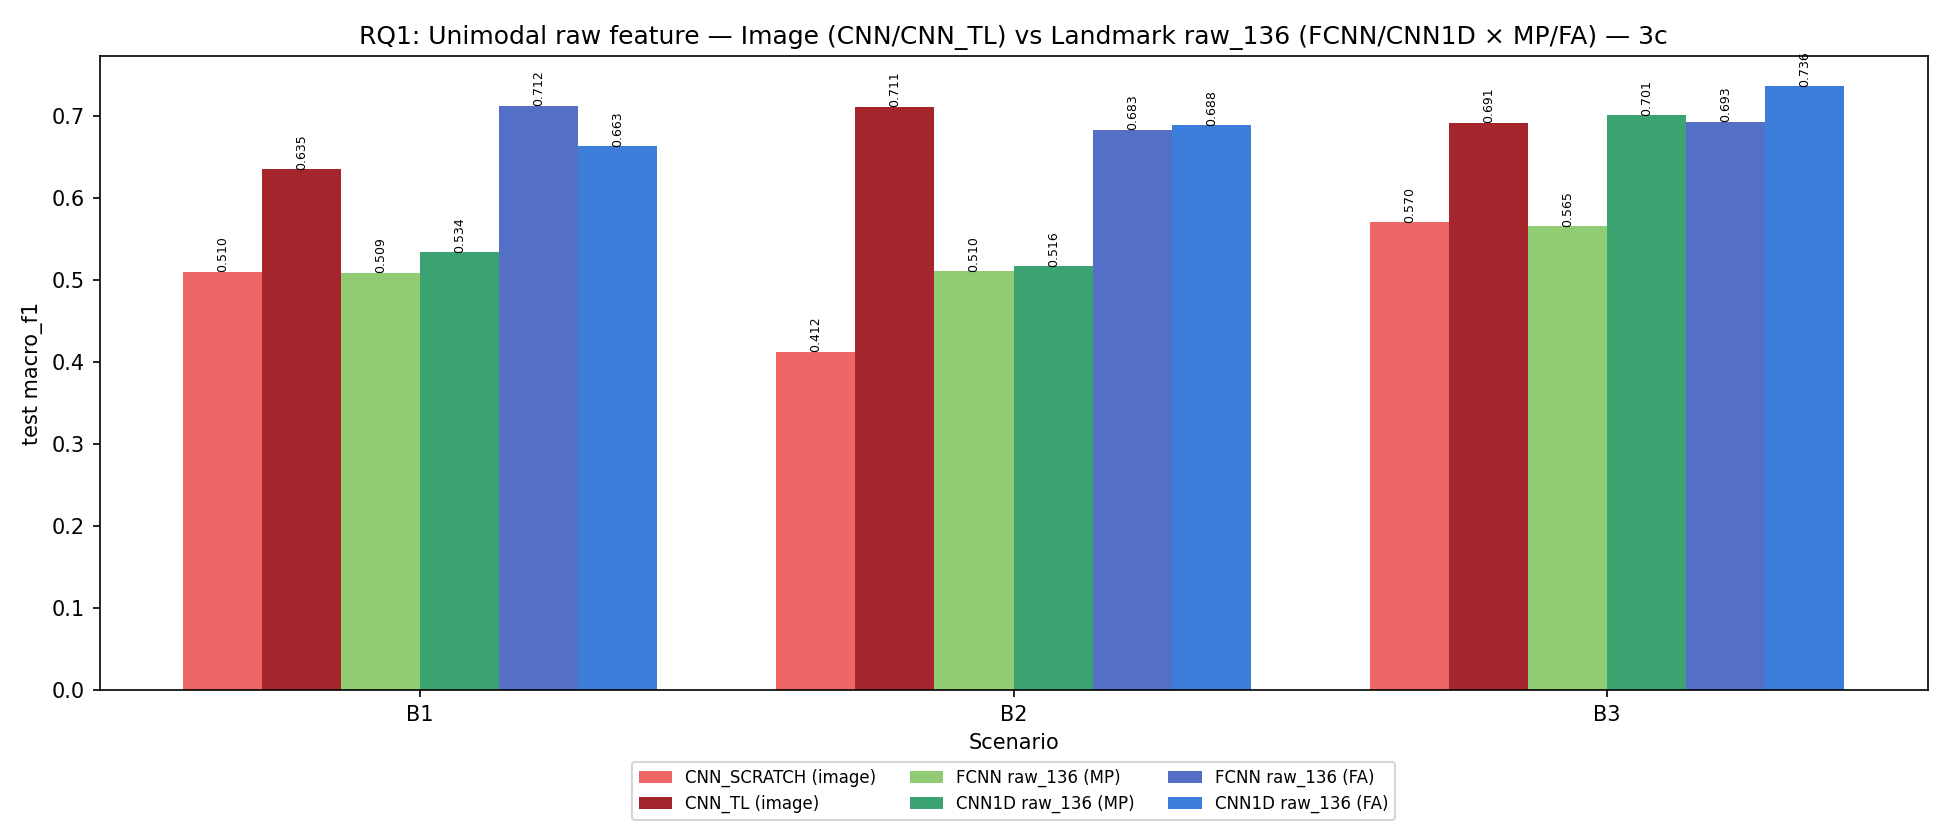

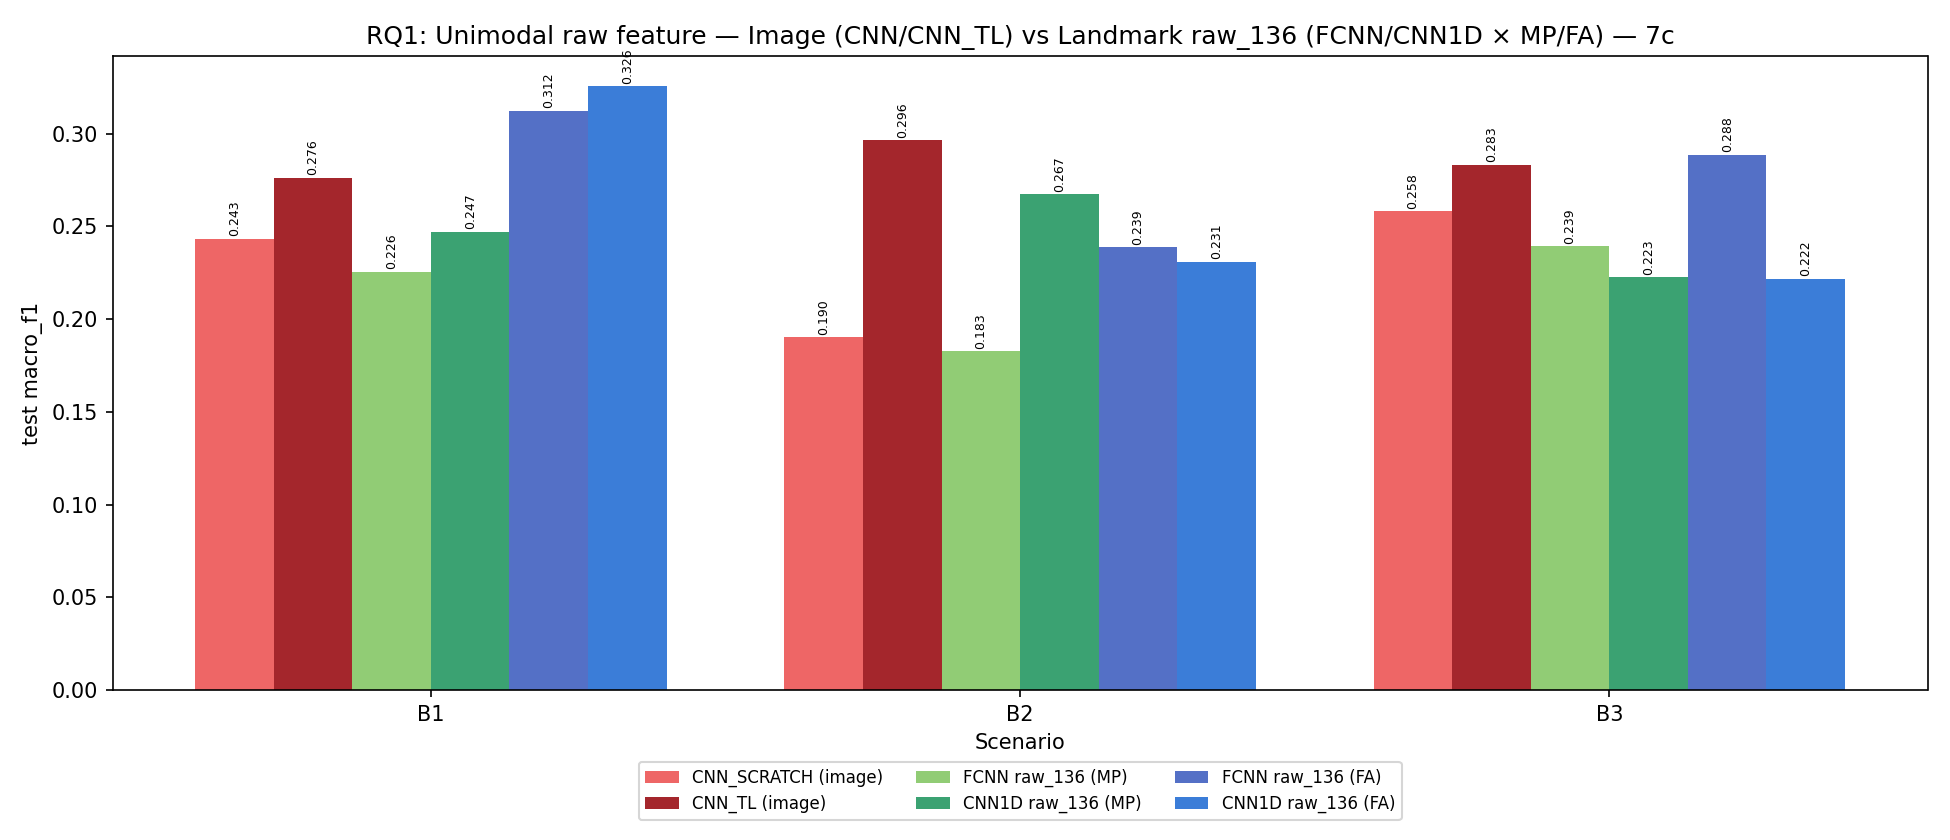

In [5]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'rq1_modality_contribution_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'rq1_modality_contribution_7c.png')))

**Tabel ringkas RQ1** — mean + max mf1 per modality (Primer, raw feature, semua arch × source × scenario):


In [6]:
# RQ1 summary — Image (all arch) vs Landmark raw_136 (all arch × source)
rows = []
for scheme in ('3c','7c'):
    # Landmark raw_136 — FCNN + CNN1D × MP + FA
    lm = []
    for r in primer[scheme]:
        rk = r['_run_key']; parts = rk.split('_')
        if parts[0] not in ('mediapipe','faceapi'): continue
        feat = '_'.join(parts[1:-3]); arch = parts[-3]; r_scheme = parts[-1]
        mf1 = r.get('test',{}).get('macro_f1')
        if feat=='raw_136' and arch in ('fcnn','cnn1d') and r_scheme==scheme and mf1 is not None:
            lm.append(mf1)
    # Image — CNN_SCRATCH + CNN_TL
    img = [r['test']['macro_f1'] for r in primer[scheme]
           if r.get('_method_dir') in ('cnn_scratch','cnn_tl')
           and r.get('_run_key','').endswith(scheme)
           and r.get('test',{}).get('macro_f1') is not None]
    if lm:
        rows.append({'scheme':scheme,'modality':'Landmark raw_136 (FCNN+CNN1D × MP+FA)',
                     'mean_mf1':float(np.mean(lm)),'max_mf1':float(max(lm)),'n':len(lm)})
    if img:
        rows.append({'scheme':scheme,'modality':'Image (CNN_SCRATCH+CNN_TL)',
                     'mean_mf1':float(np.mean(img)),'max_mf1':float(max(img)),'n':len(img)})
rq1_df = pd.DataFrame(rows)
rq1_df.style.format({'mean_mf1':'{:.4f}','max_mf1':'{:.4f}'})

,scheme,modality,mean_mf1,max_mf1,n
0,3c,Landmark raw_136 (FCNN+CNN1D × MP+FA),0.6258,0.7358,12
1,3c,Image (CNN_SCRATCH+CNN_TL),0.5881,0.7107,6
2,7c,Landmark raw_136 (FCNN+CNN1D × MP+FA),0.2502,0.3256,12
3,7c,Image (CNN_SCRATCH+CNN_TL),0.2580,0.2964,6


#### 4.0.2 RQ2 — Pengaruh dekomposisi feature landmark: Δ vs raw_136 baseline

Scope RQ2: **unimodal landmark** dengan multiple feature representation:
- `raw_136` — koordinat 2D 68 titik (baseline)
- `facs_28` — Euclidean distance antar landmark berbasis FACS-AU
- `blendshape_52` — koefisien ARKit Blendshape (MP only)
- `facs_plus_bs_80` — concat (FACS_28 + Blendshape_52)

Mean macro_f1 (atas **arch (FCNN+CNN1D) × scenario**) untuk tiap feature dibandingkan baseline raw_136, dipisah per source. Positive Δ = dekomposisi memberi improvement.


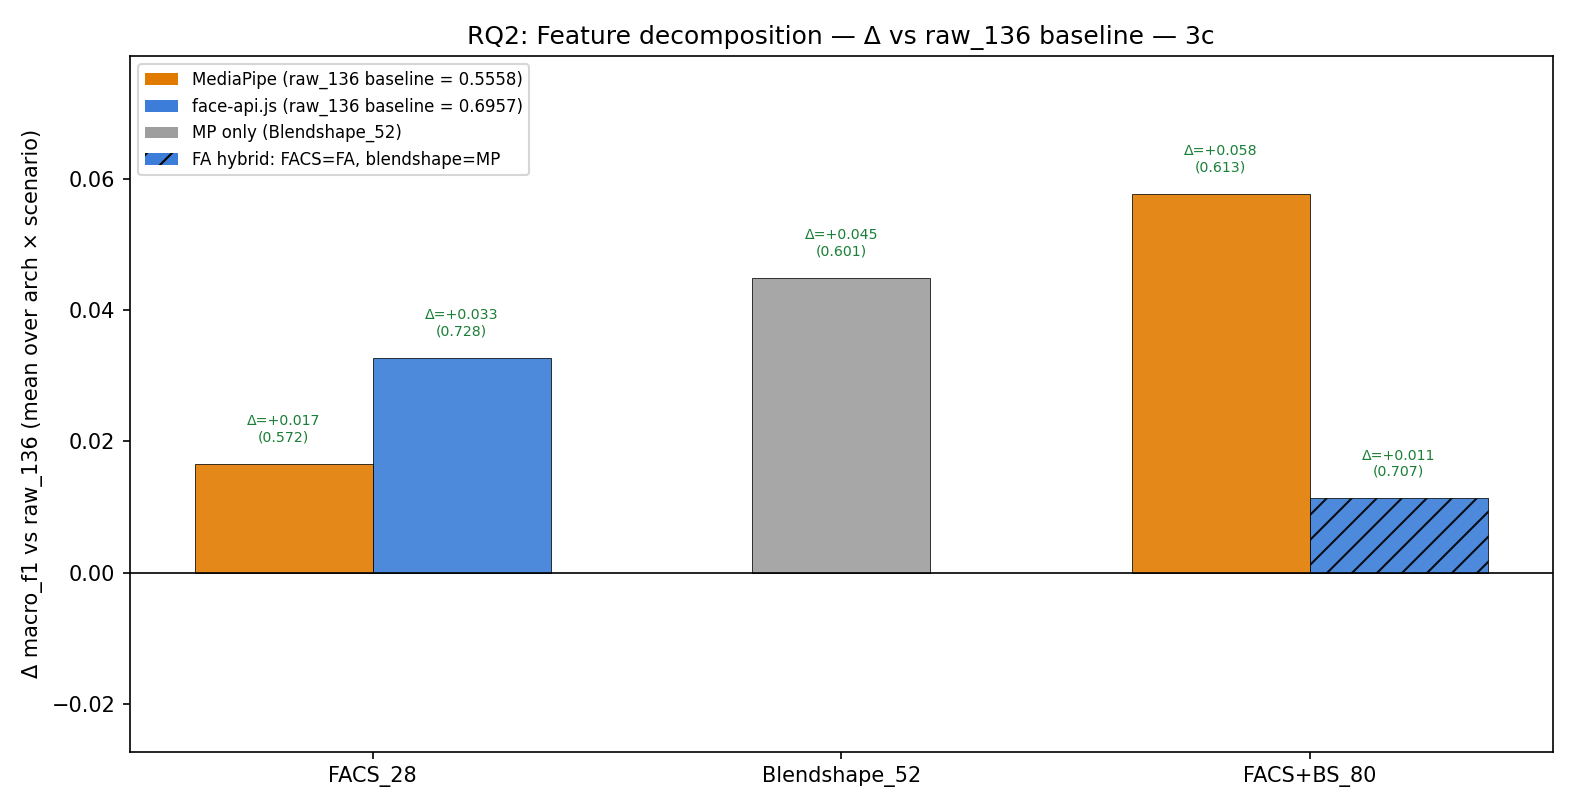

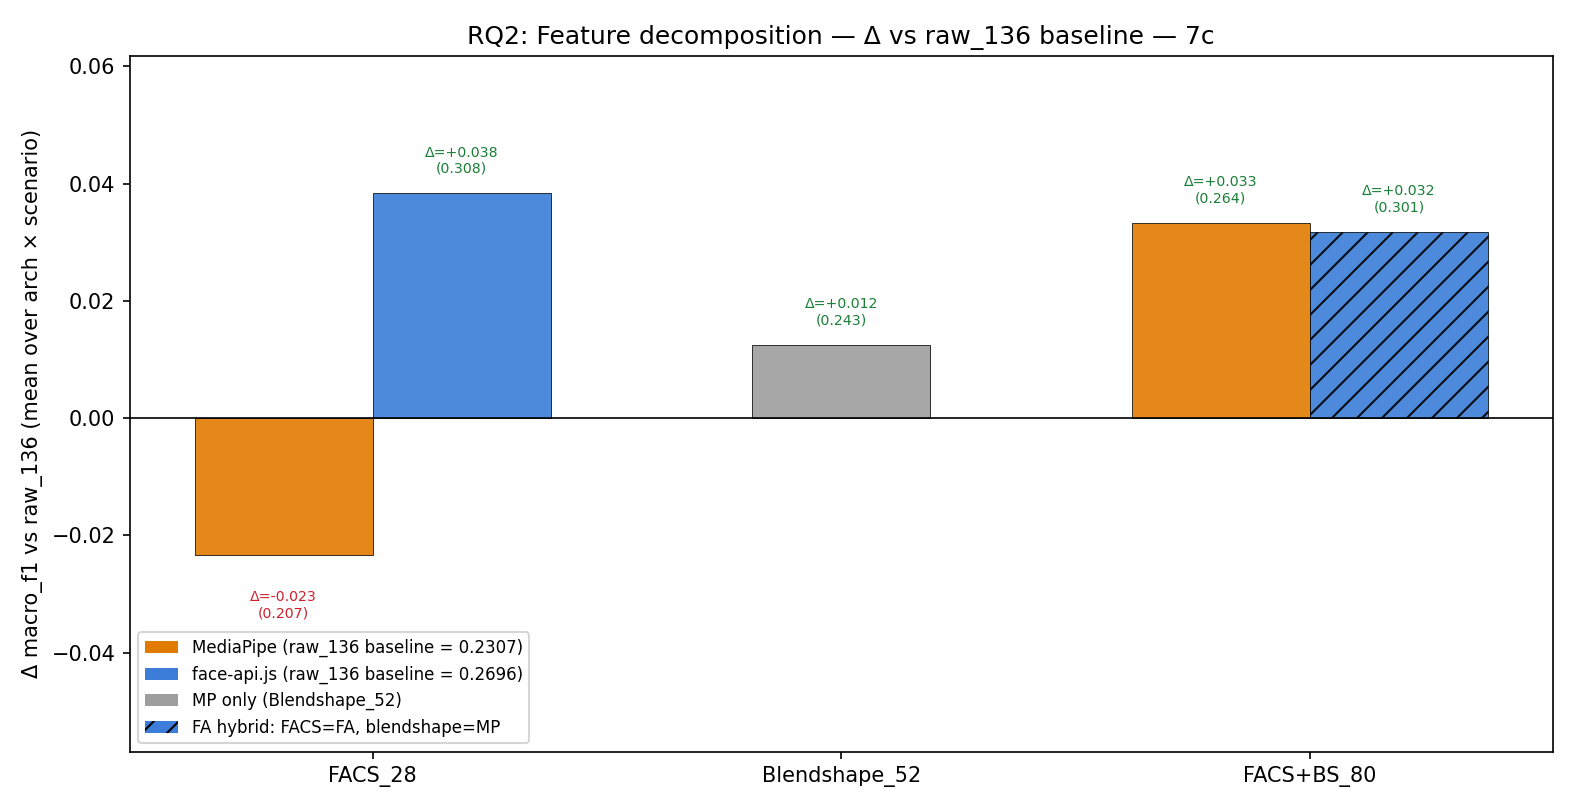

In [7]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'rq2_feature_decomposition_delta_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'rq2_feature_decomposition_delta_7c.png')))

##### (Perbaikan) RQ2 Δ plot — semua feature tampil

> **Fix Gambar 5.10.** Sebelumnya hanya `FACS_28` yang muncul; `Blendshape_52` dan `FACS+BS_80` kosong karena masalah *source grouping* yang sama. Cell di bawah me-*regenerate* delta plot (Δ vs baseline `raw_136` per source):
> - **FACS_28**: bar MP & FA
> - **Blendshape_52**: satu bar *MP only*
> - **FACS+BS_80**: bar MP & FA (FA = hybrid, lihat legenda)
> - Baseline `raw_136` per source dicantumkan di legenda.

wrote rq2_feature_decomposition_delta_3c.png


wrote rq2_feature_decomposition_delta_7c.png


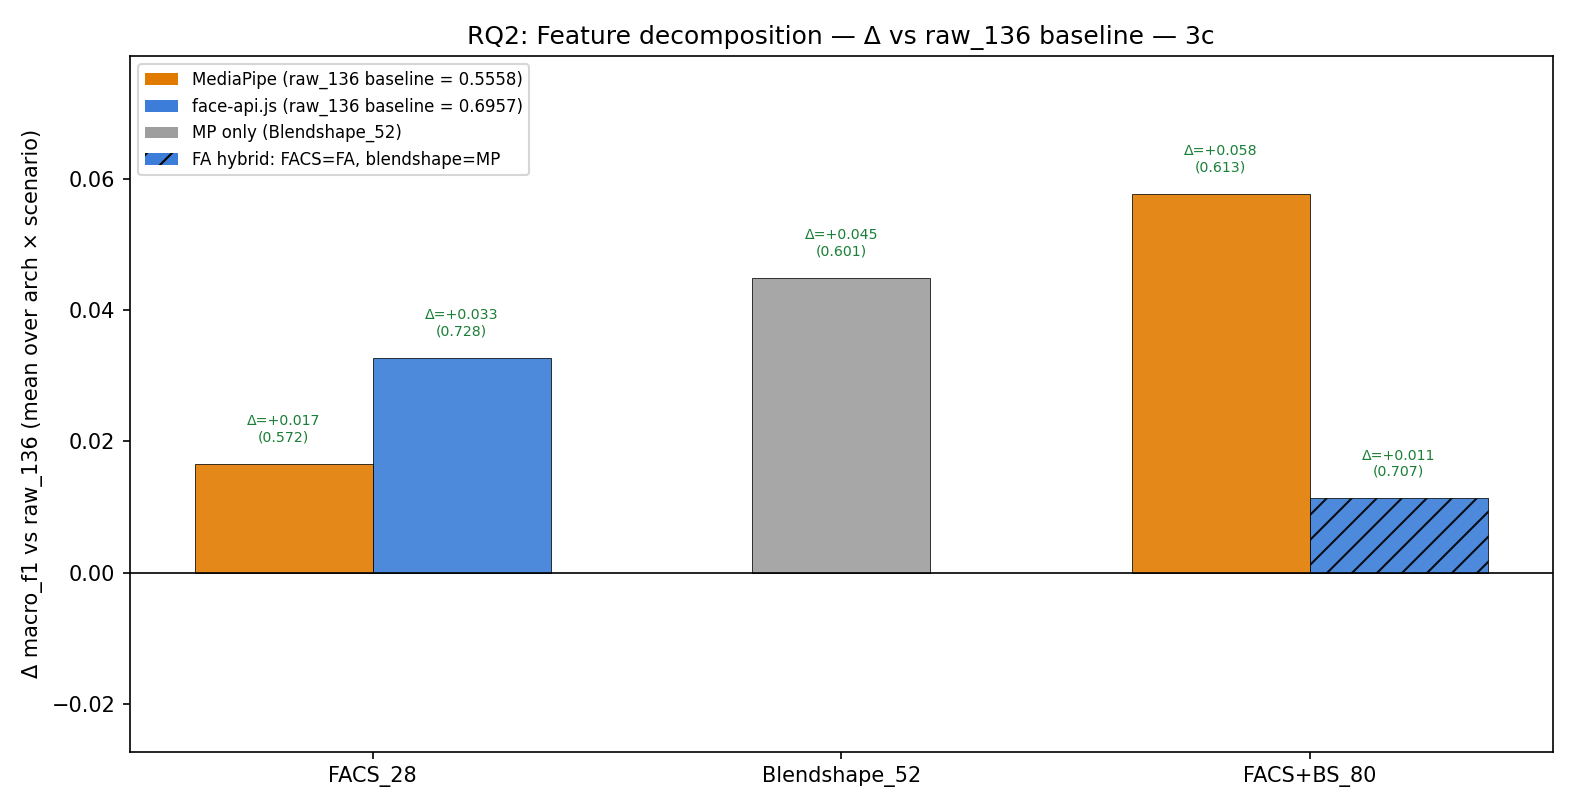

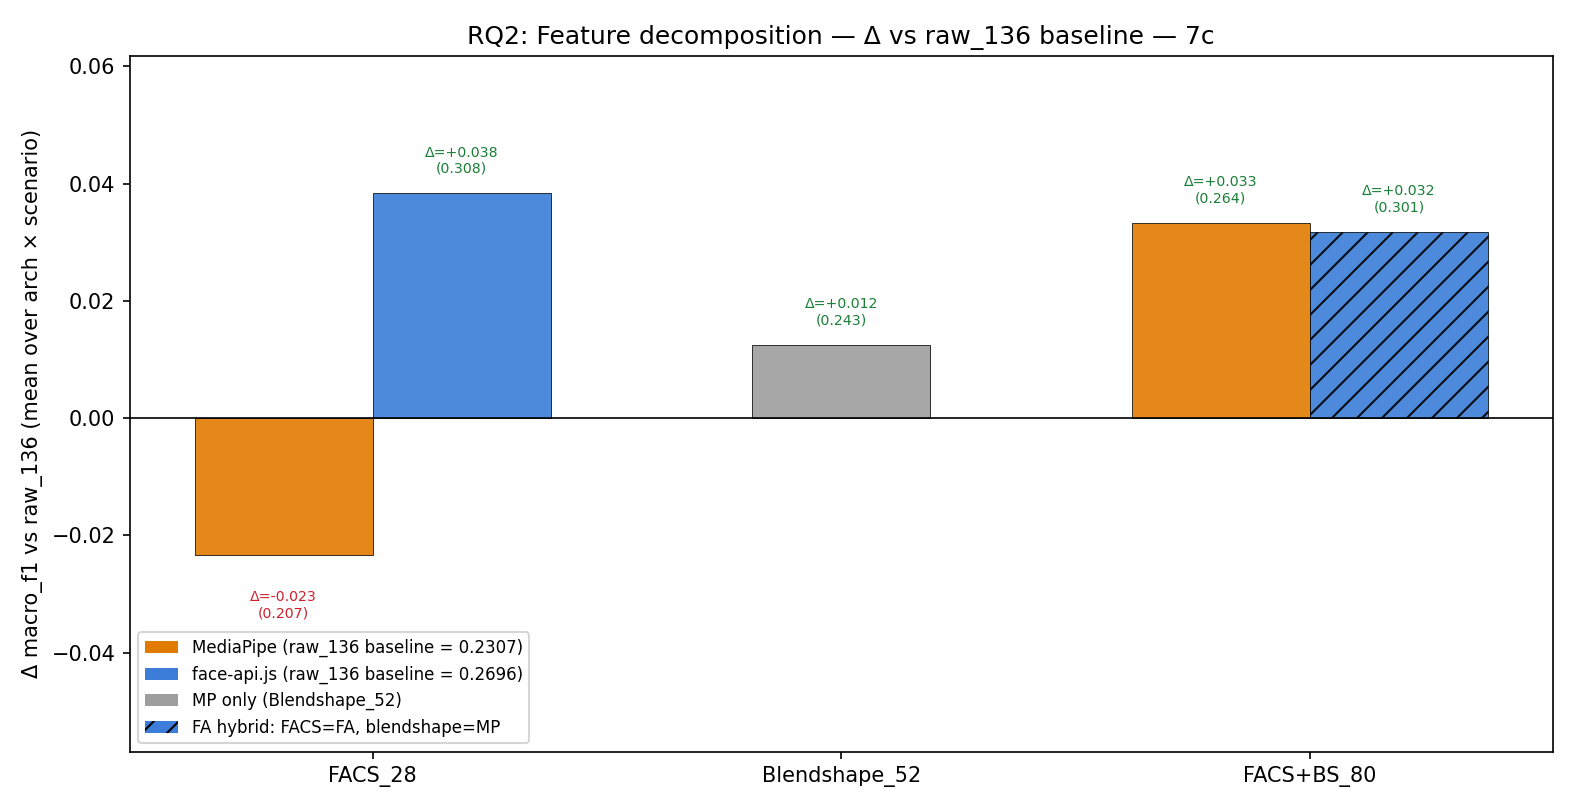

In [8]:
# === FIX: rq2_feature_decomposition_delta_{3c,7c}.png — source-aware ===
# Bug yang sama dengan feature_comparison: blendshape_52 & facs_plus_bs_80
# ter-skip. Cell ini self-contained (mendefinisikan ulang parser robust).
from matplotlib.patches import Patch

_MP, _FA, _MPONLY = "#e07b00", "#3b7dd8", "#9e9e9e"
_MP_ONLY = {"blendshape_52"}
_HYBRID = {"facs_plus_bs_80"}


def _collect_lm_robust(runs):
    rows = []
    for r in runs:
        parts = r['_run_key'].split('_')
        si = next((i for i, p in enumerate(parts) if p in ('mediapipe', 'faceapi')), None)
        if si is None:
            continue
        rows.append({'source': 'MP' if parts[si] == 'mediapipe' else 'FA',
                     'feature': '_'.join(p for j, p in enumerate(parts[:-3]) if j != si),
                     'arch': parts[-3], 'scenario': parts[-2].upper(), 'scheme': parts[-1],
                     'mf1': r.get('test', {}).get('macro_f1')})
    return rows


def _mean_mf1(lm, feature, source, scheme):
    vals = [r['mf1'] for r in lm if r['feature'] == feature and r['source'] == source
            and r['scheme'] == scheme and r['mf1'] is not None]
    return float(np.mean(vals)) if vals else None


def fig_rq2_delta_fixed(scheme):
    lm = _collect_lm_robust(primer[scheme])
    features = [("facs_28", "FACS_28"), ("blendshape_52", "Blendshape_52"),
                ("facs_plus_bs_80", "FACS+BS_80")]
    base = {src: _mean_mf1(lm, 'raw_136', src, scheme) for src in ('MP', 'FA')}
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    width, x = 0.38, np.arange(len(features))
    has_mponly = has_hybrid = False
    for si, src in enumerate(('MP', 'FA')):
        if base[src] is None:
            continue
        for xi, (feat, _lbl) in enumerate(features):
            if feat in _MP_ONLY and src == 'FA':
                continue
            m = _mean_mf1(lm, feat, src, scheme)
            if m is None:
                continue
            d = m - base[src]
            if feat in _MP_ONLY:
                offset, color = 0.0, _MPONLY
                has_mponly = True
            else:
                offset = (si - 0.5) * width
                color = _MP if src == 'MP' else _FA
            hatch = '//' if (src == 'FA' and feat in _HYBRID) else None
            has_hybrid = has_hybrid or bool(hatch)
            ax.bar(xi + offset, d, width, color=color, alpha=0.9, hatch=hatch,
                   edgecolor='black', linewidth=0.4)
            tcol = "#1a7f37" if d > 0 else "#cf222e"
            ax.text(xi + offset, d + (0.003 if d >= 0 else -0.006),
                    f"Δ={d:+.3f}\n({m:.3f})", ha='center',
                    va='bottom' if d >= 0 else 'top', fontsize=6.8, color=tcol)
    ax.axhline(0, color='black', linewidth=0.8)
    # headroom proporsional ke range data: bawah lebih lega utk label 2-baris
    # pada bar negatif (mis. FACS_28 MP di 7c) agar tidak keluar kotak.
    ymin, ymax = ax.get_ylim()
    rng = (ymax - ymin) or 1.0
    ax.set_ylim(ymin - rng * 0.45, ymax + rng * 0.30)
    ax.set_xticks(x); ax.set_xticklabels([f[1] for f in features])
    ax.set_ylabel("Δ macro_f1 vs raw_136 (mean over arch × scenario)")
    ax.set_title(f"RQ2: Feature decomposition — Δ vs raw_136 baseline — {scheme}")
    handles = []
    if base['MP'] is not None:
        handles.append(Patch(facecolor=_MP, label=f"MediaPipe (raw_136 baseline = {base['MP']:.4f})"))
    if base['FA'] is not None:
        handles.append(Patch(facecolor=_FA, label=f"face-api.js (raw_136 baseline = {base['FA']:.4f})"))
    if has_mponly:
        handles.append(Patch(facecolor=_MPONLY, label='MP only (Blendshape_52)'))
    if has_hybrid:
        handles.append(Patch(facecolor=_FA, hatch='//', label='FA hybrid: FACS=FA, blendshape=MP'))
    ax.legend(handles=handles, loc='best', fontsize=8)
    plt.tight_layout()
    out = FIG_ROOT / 'comparisons' / f'rq2_feature_decomposition_delta_{scheme}.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150); plt.close(fig)
    print('wrote', out.name)


for _sc in ('3c', '7c'):
    fig_rq2_delta_fixed(_sc)
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'rq2_feature_decomposition_delta_3c.png')))
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'rq2_feature_decomposition_delta_7c.png')))

**Tabel ringkas RQ2** — mean mf1 + Δ vs raw_136 baseline per (feature × source × scheme):


In [9]:
rq2_rows = []
for scheme in ('3c','7c'):
    runs = primer[scheme]
    for src in ('MP','FA'):
        # baseline: raw_136 FCNN+CNN1D mean
        base = []
        for r in runs:
            rk = r['_run_key']; parts = rk.split('_')
            if parts[0] not in ('mediapipe','faceapi'): continue
            r_src = 'MP' if parts[0]=='mediapipe' else 'FA'
            r_feat = '_'.join(parts[1:-3]); r_scheme = parts[-1]
            mf1 = r.get('test',{}).get('macro_f1')
            if r_src == src and r_feat == 'raw_136' and r_scheme == scheme and mf1 is not None:
                base.append(mf1)
        if not base: continue
        base_mean = float(np.mean(base))
        for feat in ('raw_136','facs_28','blendshape_52','facs_plus_bs_80'):
            vals = []
            for r in runs:
                rk = r['_run_key']; parts = rk.split('_')
                if parts[0] not in ('mediapipe','faceapi'): continue
                r_src = 'MP' if parts[0]=='mediapipe' else 'FA'
                r_feat = '_'.join(parts[1:-3]); r_scheme = parts[-1]
                mf1 = r.get('test',{}).get('macro_f1')
                if r_src == src and r_feat == feat and r_scheme == scheme and mf1 is not None:
                    vals.append(mf1)
            if not vals: continue
            m = float(np.mean(vals))
            rq2_rows.append({'scheme':scheme,'feature':feat,'source':src,
                             'mean_mf1':m,'delta_vs_raw':m-base_mean,'n':len(vals)})
rq2_df = pd.DataFrame(rq2_rows)
rq2_df.style.format({'mean_mf1':'{:.4f}','delta_vs_raw':'{:+.4f}'}, na_rep='-') \
            .background_gradient(subset=['delta_vs_raw'], cmap='RdYlGn', vmin=-0.05, vmax=0.05)

,scheme,feature,source,mean_mf1,delta_vs_raw,n
0,3c,raw_136,MP,0.5558,+0.0000,6
1,3c,facs_28,MP,0.5724,+0.0166,6
2,3c,raw_136,FA,0.6957,+0.0000,6
3,3c,facs_28,FA,0.7284,+0.0327,6
4,7c,raw_136,MP,0.2307,+0.0000,6
5,7c,facs_28,MP,0.2074,-0.0233,6
6,7c,raw_136,FA,0.2696,+0.0000,6
7,7c,facs_28,FA,0.3079,+0.0383,6


#### 4.0.3 Multi-metric summary — accuracy, macro_f1, weighted_f1

Pelengkap RQ1/RQ2: best run per kategori unimodal dievaluasi dengan **3 metrik sekaligus** (accuracy, macro_f1, weighted_f1) untuk validasi konsistensi ranking.


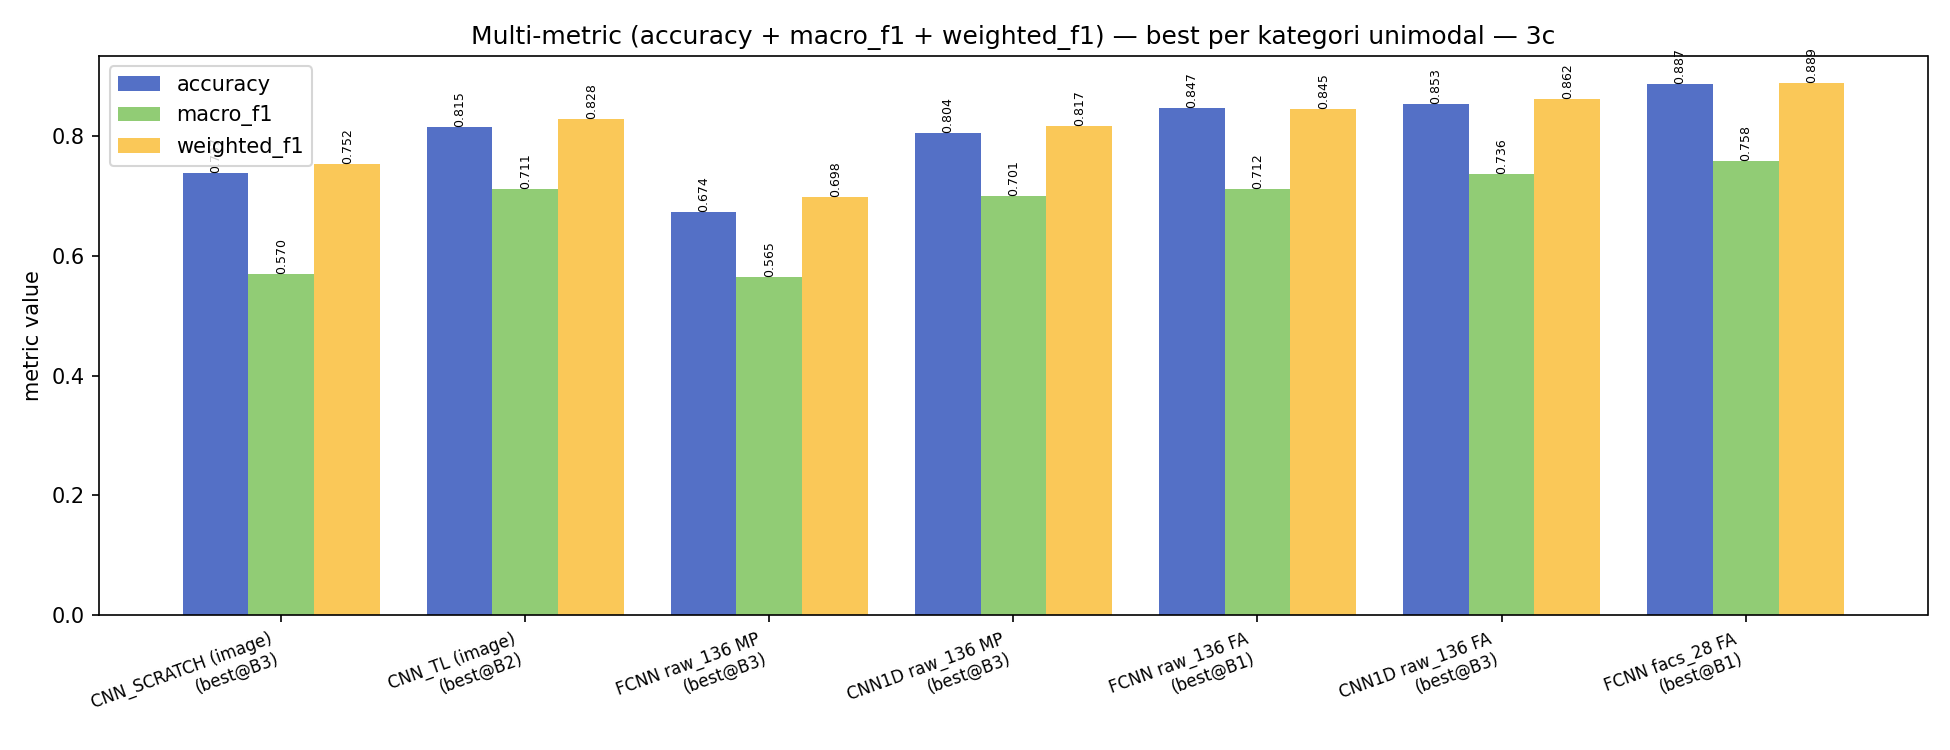

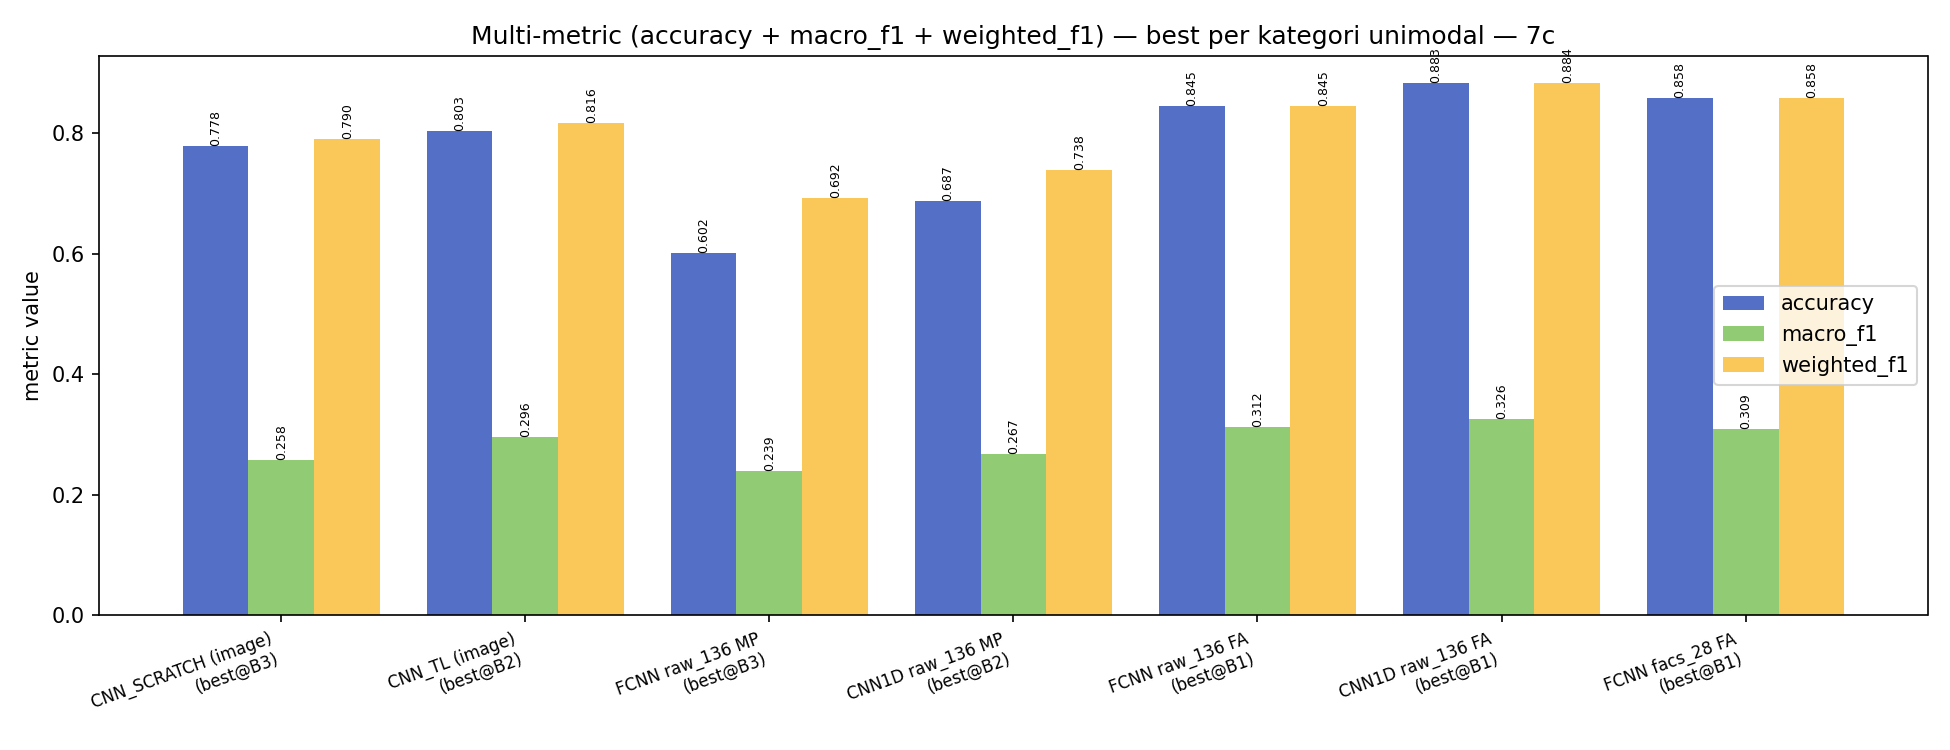

In [10]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'multi_metric_unimodal_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'multi_metric_unimodal_7c.png')))

#### 4.0.3.b CNN Transfer Learning vs Training from Scratch

> **Gambar 5.6 (baru).** Perbandingan langsung CNN image branch: **Transfer Learning (ResNet-18 ImageNet)** vs **Training from Scratch**, untuk skema 7c (panel a) dan 3c (panel b). Bar berkelompok per skenario B1/B2/B3, Y-axis = test `macro_f1`, nilai ditampilkan di atas tiap bar.
>
> Output: `docs/figures/unimodal/comparisons/cnn_tl_vs_scratch_{7c,3c}.png`.

wrote cnn_tl_vs_scratch_7c.png
wrote cnn_tl_vs_scratch_3c.png


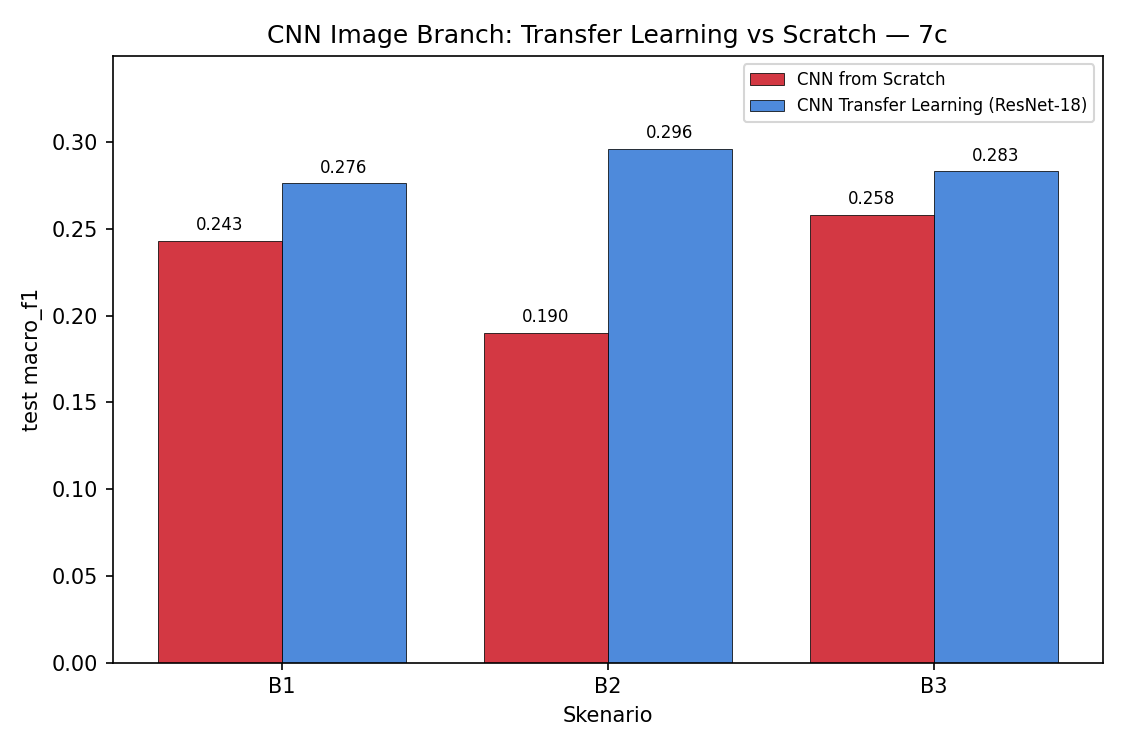

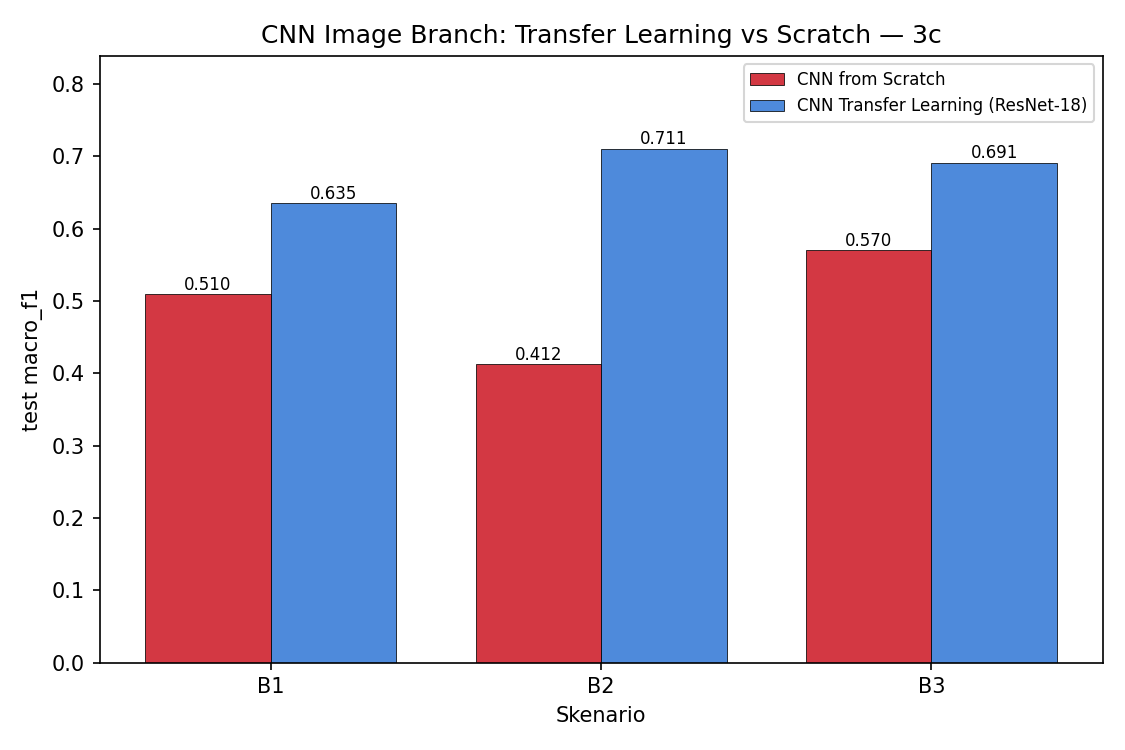

In [11]:
# === NEW: CNN Transfer Learning (ResNet-18) vs Training from Scratch ===
# Modul Unimodal CNN image branch. Data: results Primer cnn_tl & cnn_scratch.
def _cnn_mf1(runs, method, scenario, scheme):
    for r in runs:
        if r['_method_dir'] != method:
            continue
        parts = r['_run_key'].split('_')          # e.g. cnn_tl_b1_3c
        if parts[-1] == scheme and parts[-2].upper() == scenario:
            return r.get('test', {}).get('macro_f1')
    return None


def fig_cnn_tl_vs_scratch(scheme):
    runs = primer[scheme]
    scns = ['B1', 'B2', 'B3']
    scratch = [_cnn_mf1(runs, 'cnn_scratch', s, scheme) for s in scns]
    tl = [_cnn_mf1(runs, 'cnn_tl', s, scheme) for s in scns]
    fig, ax = plt.subplots(figsize=(7.5, 5))
    x, width = np.arange(len(scns)), 0.38
    b1 = ax.bar(x - width/2, [v or 0 for v in scratch], width,
                label='CNN from Scratch', color="#cf222e", alpha=0.9,
                edgecolor='black', linewidth=0.4)
    b2 = ax.bar(x + width/2, [v or 0 for v in tl], width,
                label='CNN Transfer Learning (ResNet-18)', color="#3b7dd8",
                alpha=0.9, edgecolor='black', linewidth=0.4)
    for bars, vals in ((b1, scratch), (b2, tl)):
        for rect, v in zip(bars, vals):
            if v is not None:
                ax.text(rect.get_x() + rect.get_width()/2, v + 0.006,
                        f"{v:.3f}", ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(scns)
    ax.set_xlabel('Skenario'); ax.set_ylabel('test macro_f1')
    ax.set_title(f'CNN Image Branch: Transfer Learning vs Scratch — {scheme}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, max([v for v in (scratch + tl) if v] + [0.1]) * 1.18)
    plt.tight_layout()
    out = FIG_ROOT / 'comparisons' / f'cnn_tl_vs_scratch_{scheme}.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150); plt.close(fig)
    print('wrote', out.name)


for _sc in ('7c', '3c'):   # panel a = 7c, panel b = 3c
    fig_cnn_tl_vs_scratch(_sc)
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'cnn_tl_vs_scratch_7c.png')))
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'cnn_tl_vs_scratch_3c.png')))

#### 4.0.4 Inference throughput per arch (samples/sec)

Relevan untuk klaim *applicability* / deployment trade-off — landmark-based model jauh lebih cepat dibandingkan image CNN (no convolution heavy).


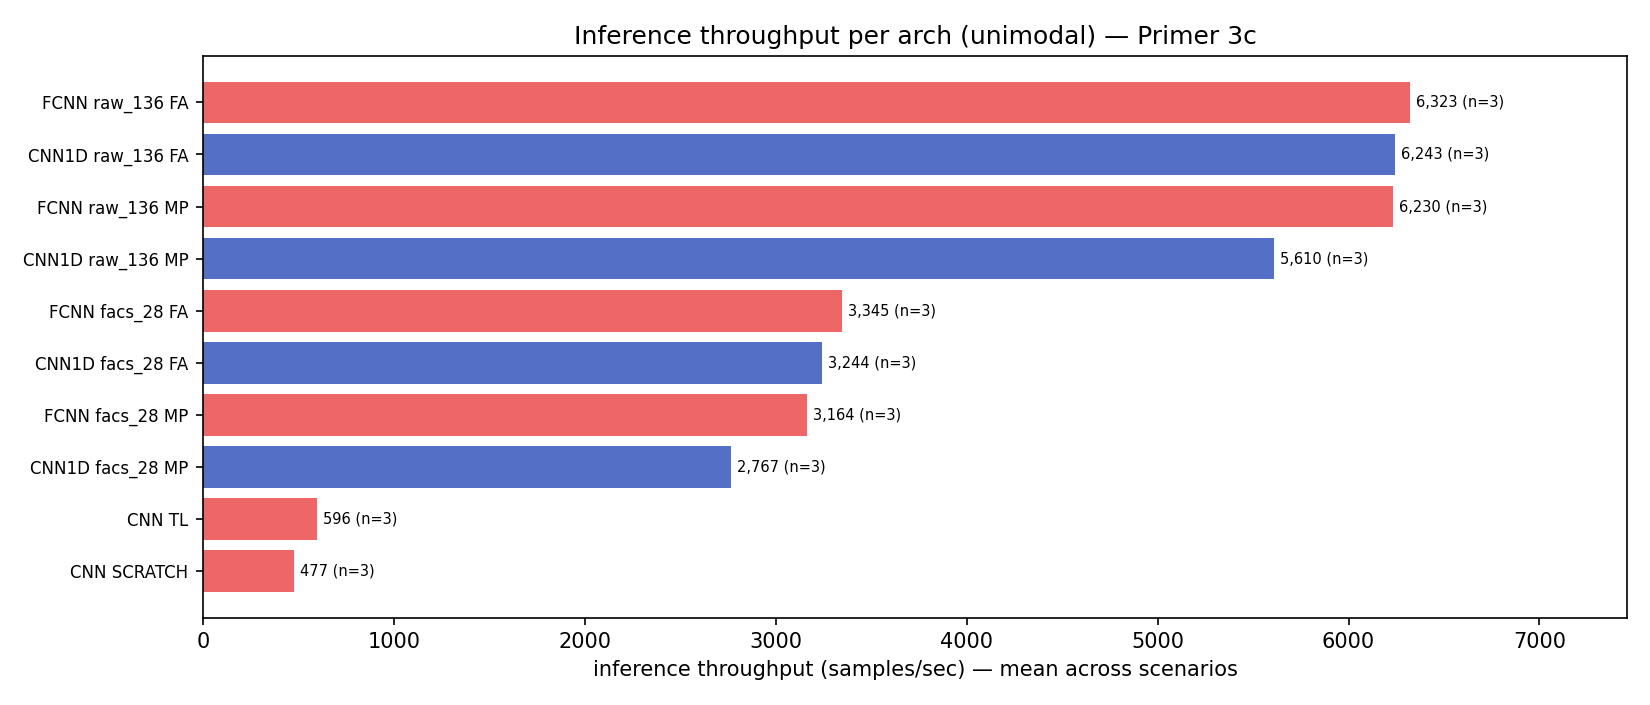

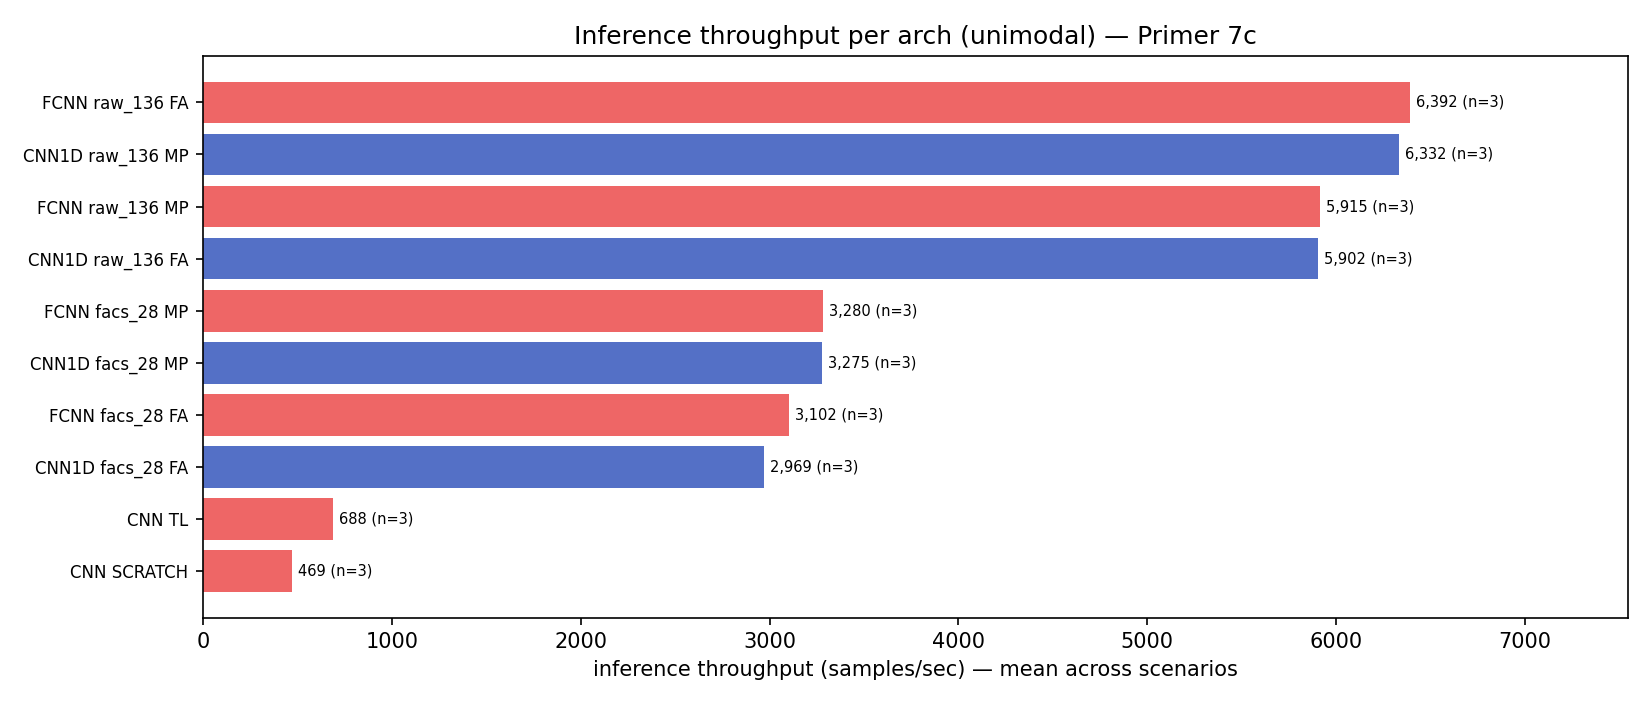

In [12]:
display(Image(filename=str(FIG_ROOT/'resources'/'inference_throughput_3c.png')))
display(Image(filename=str(FIG_ROOT/'resources'/'inference_throughput_7c.png')))

#### 4.0.5 Per-class Precision / Recall / F1 — top models per RQ kategori

Heatmap per-class metric untuk model terbaik di setiap kategori RQ. Berguna untuk pembahasan *class-wise behavior*, terutama di 7c dengan minority class.


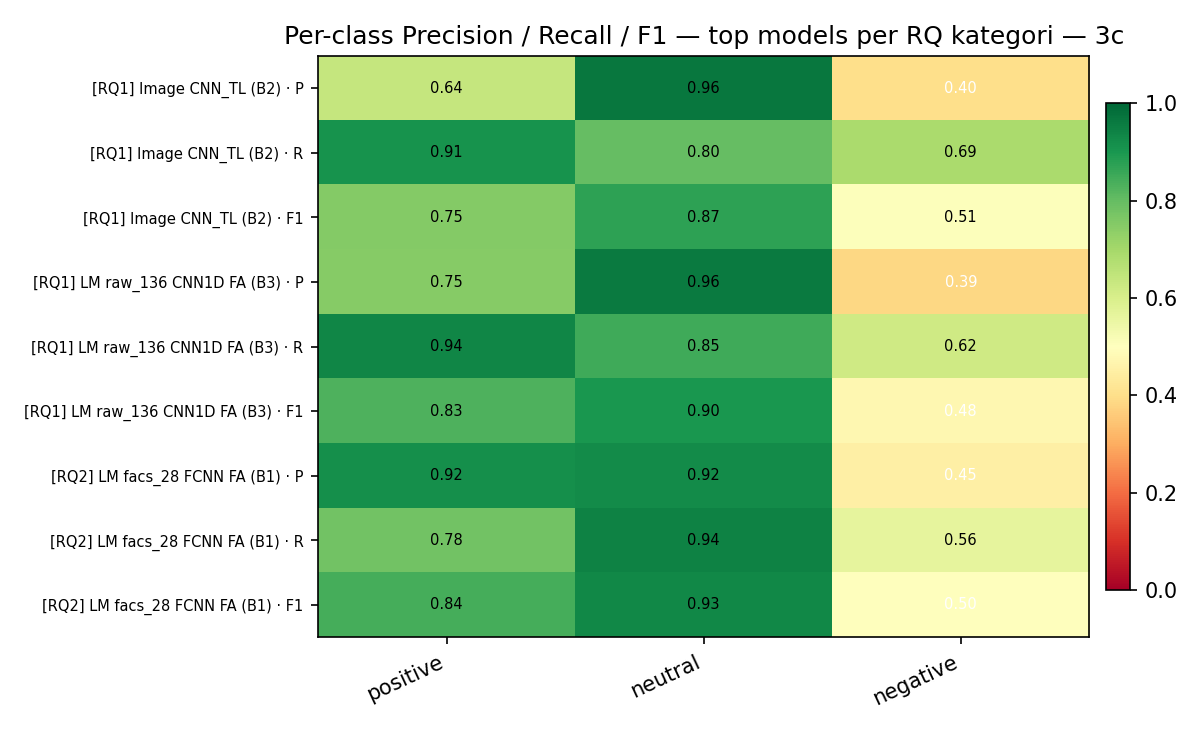

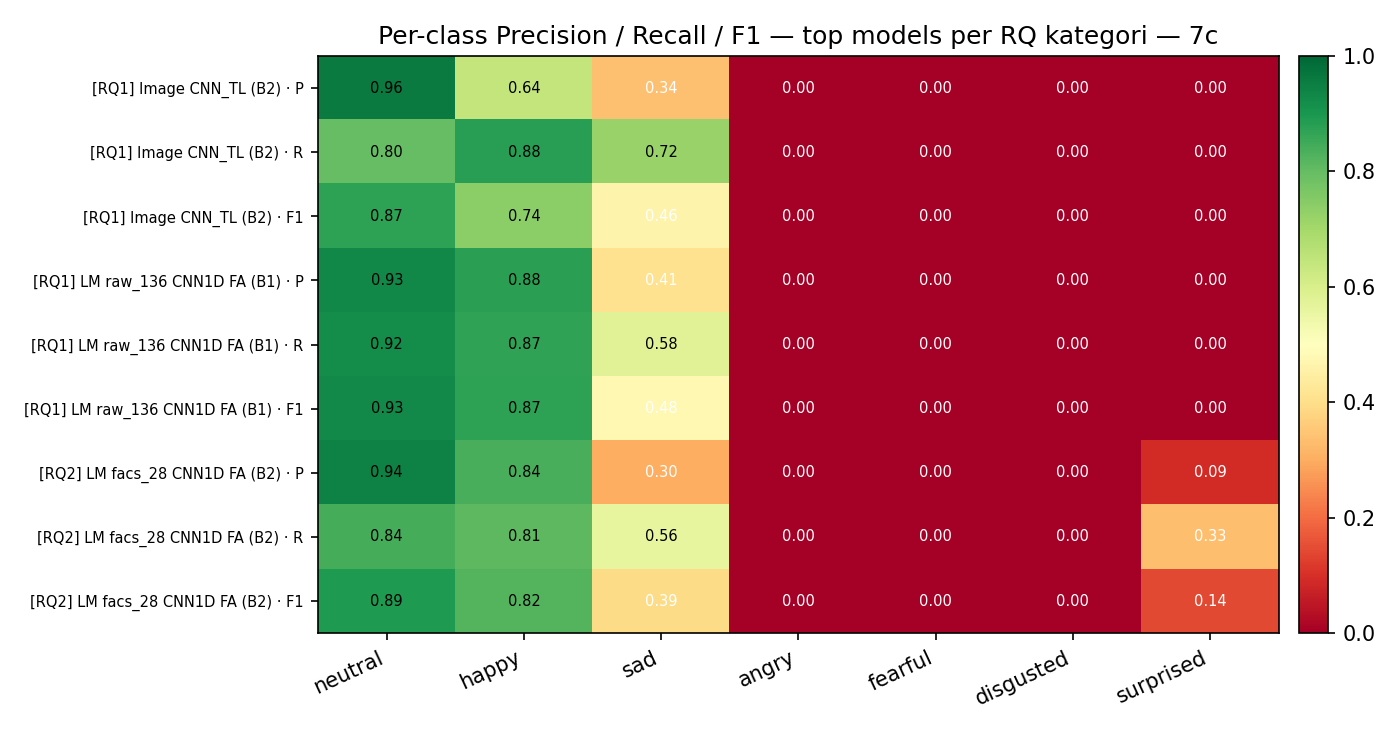

In [13]:
display(Image(filename=str(FIG_ROOT/'per_class'/'per_class_metrics_top_3c.png')))
display(Image(filename=str(FIG_ROOT/'per_class'/'per_class_metrics_top_7c.png')))

**Tabel per-class precision/recall/f1 — top unimodal models (Primer):**


In [14]:
# Per-class table for top model (overall) per scheme
rows = []
for scheme in ('3c','7c'):
    cands = [(r['test']['macro_f1'], r) for r in primer[scheme]
             if r.get('test',{}).get('macro_f1') is not None]
    if not cands: continue
    cands.sort(key=lambda t: -t[0])
    for rank, (mf1, r) in enumerate(cands[:3], start=1):
        rep = r.get('test',{}).get('classification_report', {})
        drop = {'accuracy','macro avg','weighted avg'}
        for cls, m in rep.items():
            if cls in drop or not isinstance(m, dict): continue
            rows.append({'scheme':scheme,'rank':rank,
                         'method':r.get('_run_key',''),
                         'class':cls,
                         'precision':m.get('precision'),
                         'recall':m.get('recall'),
                         'f1':m.get('f1-score'),
                         'support':int(m.get('support',0))})
per_class_df = pd.DataFrame(rows)
per_class_df.style.format({'precision':'{:.3f}','recall':'{:.3f}','f1':'{:.3f}'}, na_rep='-') \
                  .background_gradient(subset=['precision','recall','f1'], cmap='RdYlGn', vmin=0, vmax=1)

,scheme,rank,method,class,precision,recall,f1,support
0,3c,1,faceapi_facs_28_fcnn_b1_3c,positive,0.918,0.780,0.843,186
1,3c,1,faceapi_facs_28_fcnn_b1_3c,neutral,0.923,0.942,0.932,688
2,3c,1,faceapi_facs_28_fcnn_b1_3c,negative,0.449,0.564,0.500,55
3,3c,2,faceapi_facs_28_fcnn_b2_3c,positive,0.710,0.935,0.807,186
4,3c,2,faceapi_facs_28_fcnn_b2_3c,neutral,0.968,0.846,0.903,688
5,3c,2,faceapi_facs_28_fcnn_b2_3c,negative,0.446,0.673,0.536,55
6,3c,3,faceapi_facs_28_fcnn_b3_3c,positive,0.820,0.833,0.827,186
7,3c,3,faceapi_facs_28_fcnn_b3_3c,neutral,0.969,0.868,0.916,688
8,3c,3,faceapi_facs_28_fcnn_b3_3c,negative,0.339,0.764,0.469,55
9,7c,1,facs_plus_bs_80_faceapi_fcnn_b2_7c,neutral,0.974,0.817,0.889,688


### 4.1 Heatmap Master Table


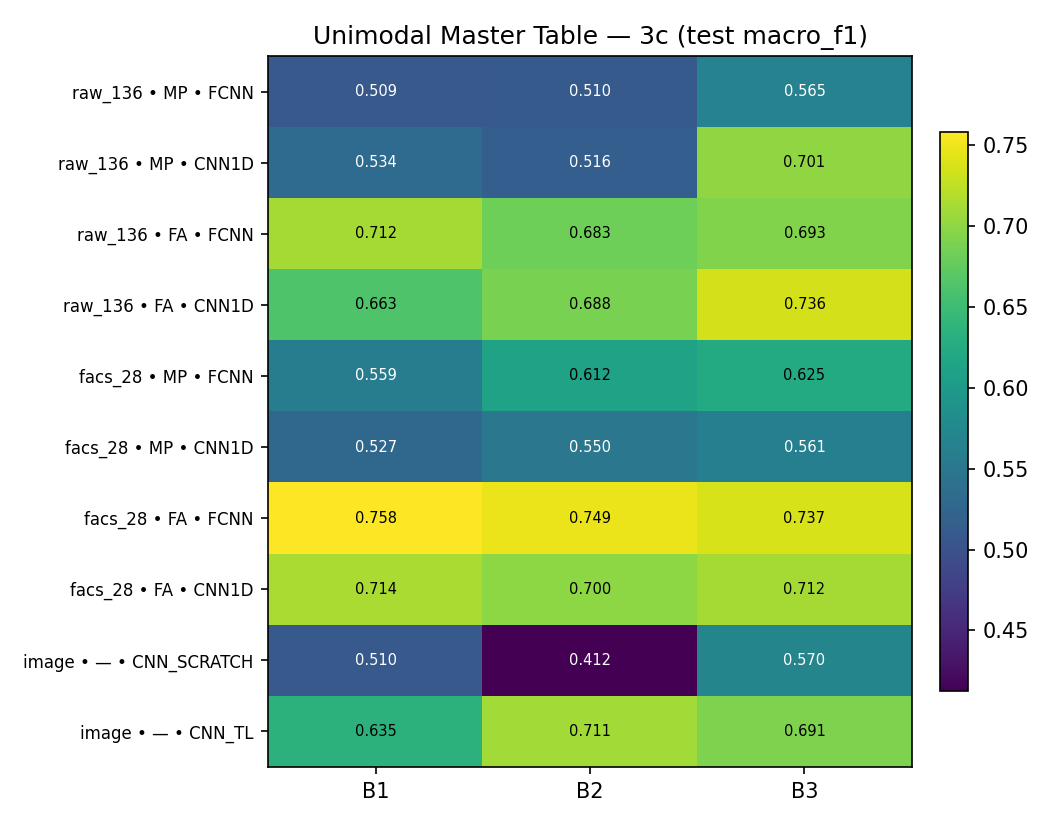

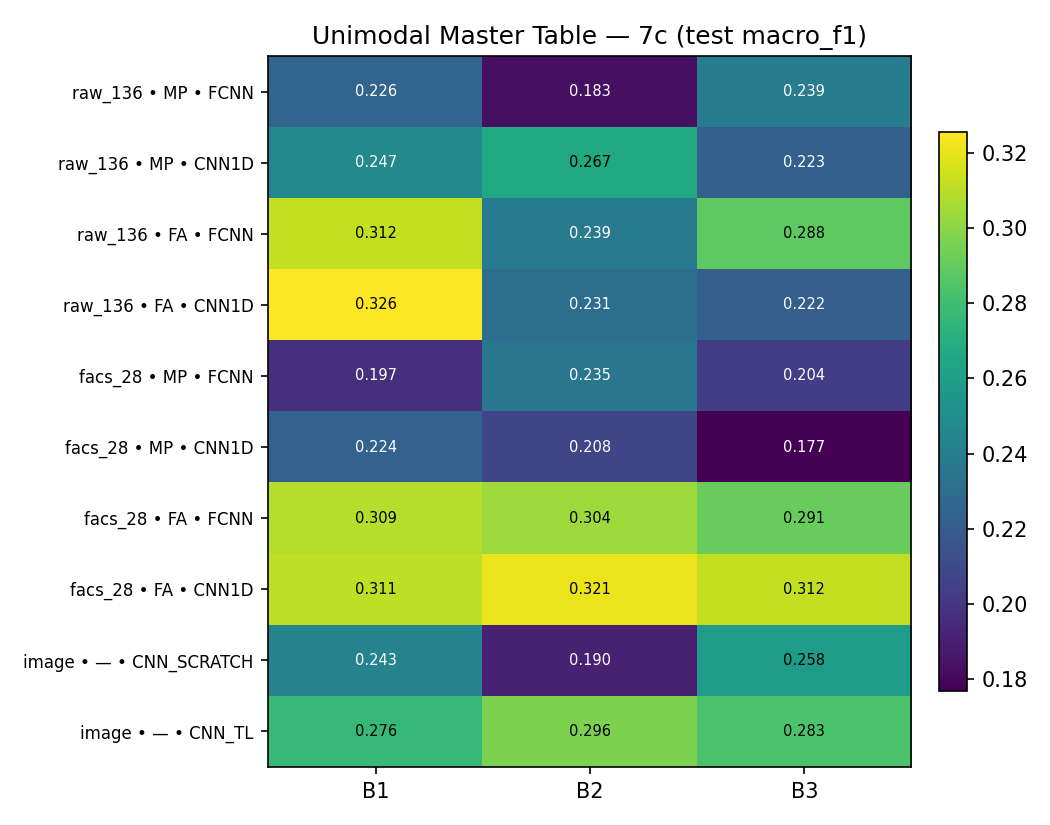

In [15]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'heatmap_master_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'heatmap_master_7c.png')))

### 4.2 Top-10 Leaderboard

Top-10 dari semua kombinasi unimodal (landmark + image) per scheme. Warna = kategori metode.


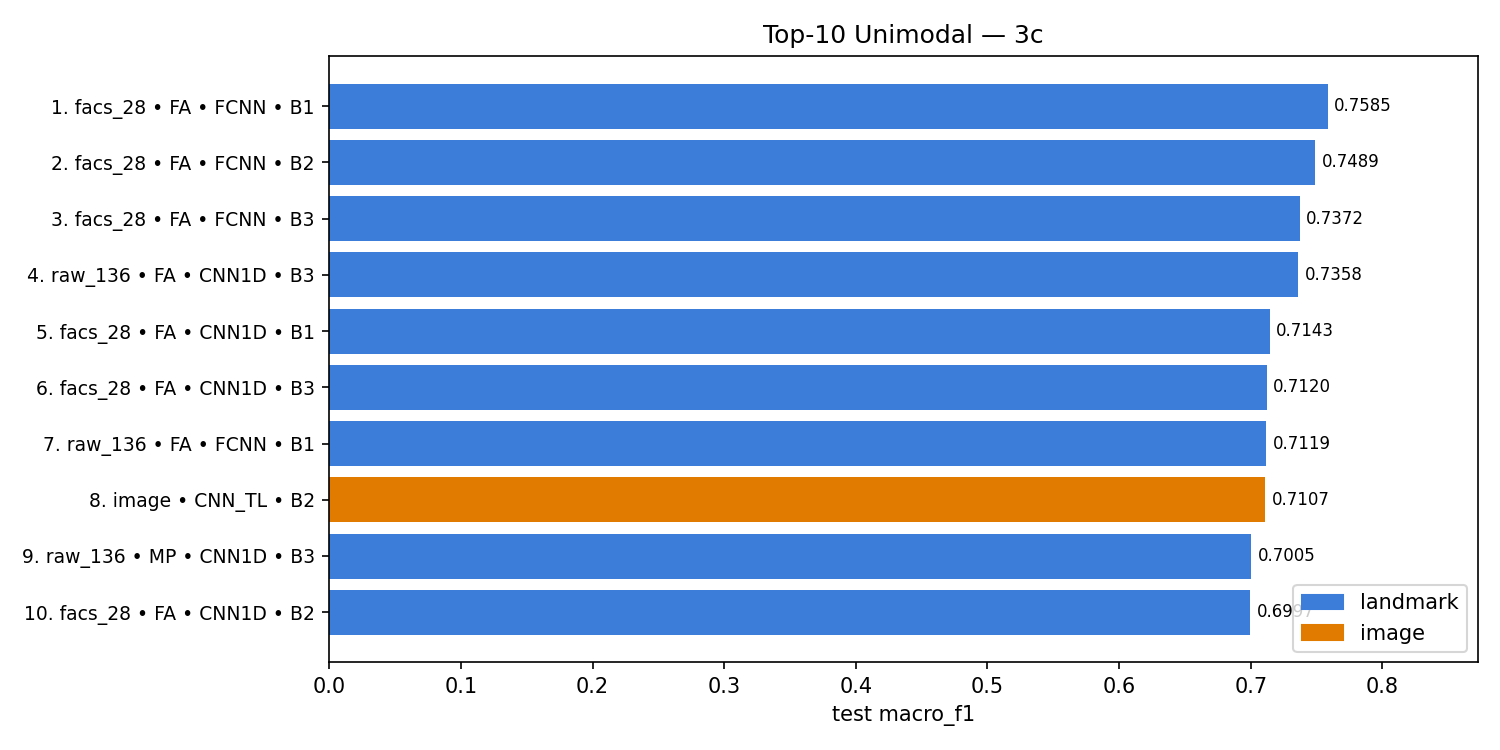

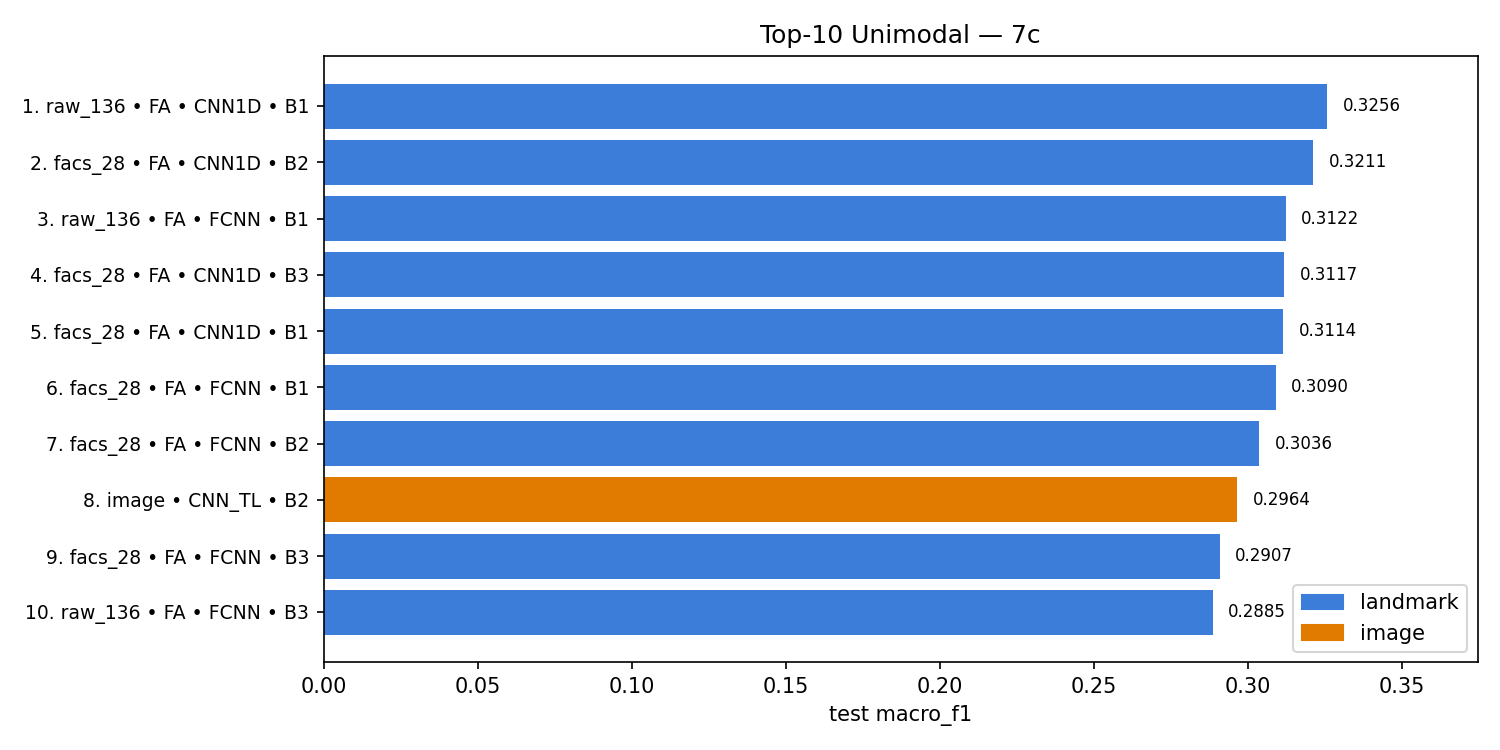

In [16]:
display(Image(filename=str(FIG_ROOT/'leaderboards'/'top10_3c.png')))
display(Image(filename=str(FIG_ROOT/'leaderboards'/'top10_7c.png')))

### 4.3 B1 / B2 / B3 Scenario Comparison

Bagaimana setiap metode merespon ke 3 imbalance scenarios?


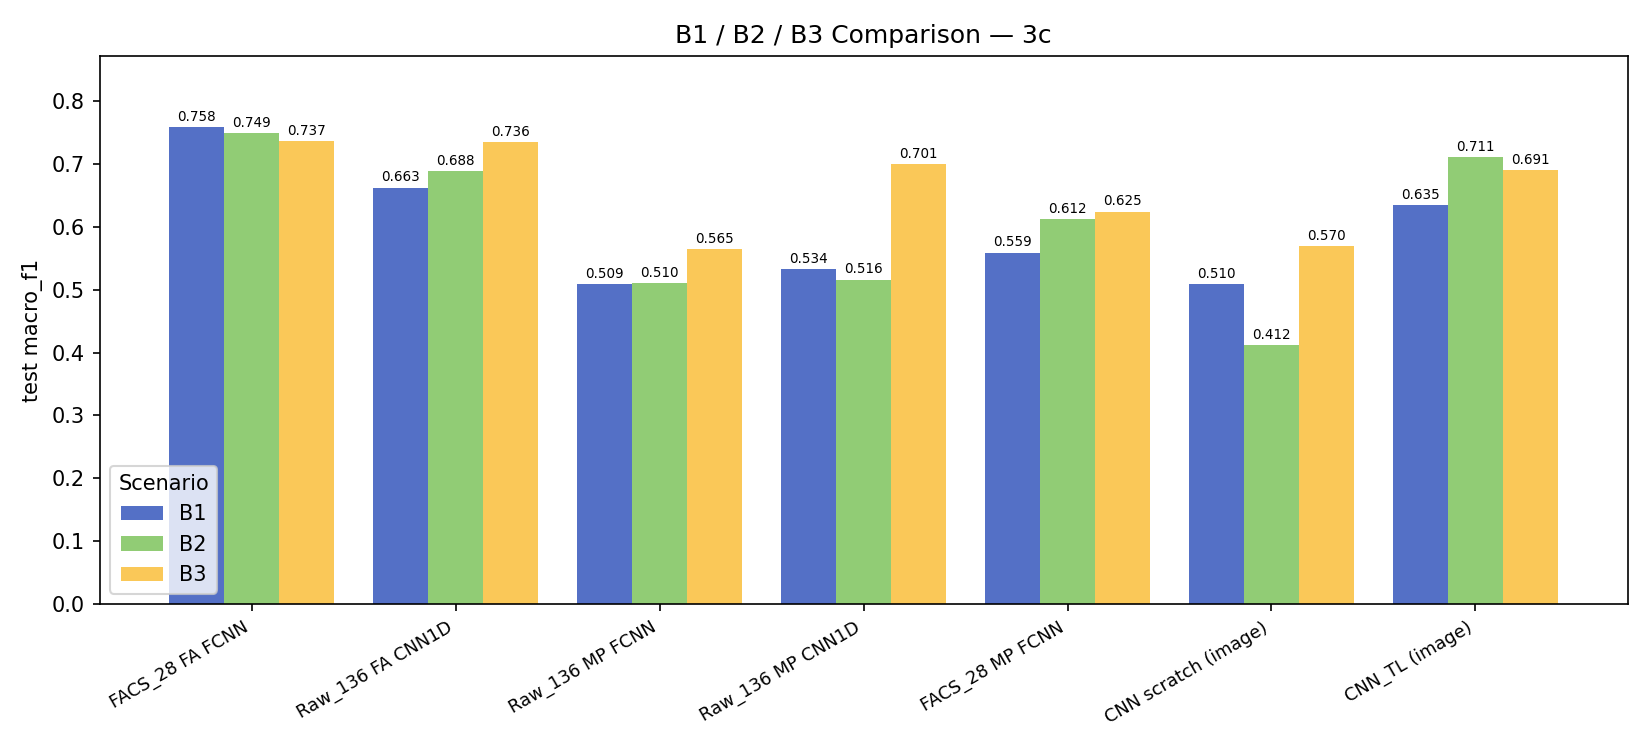

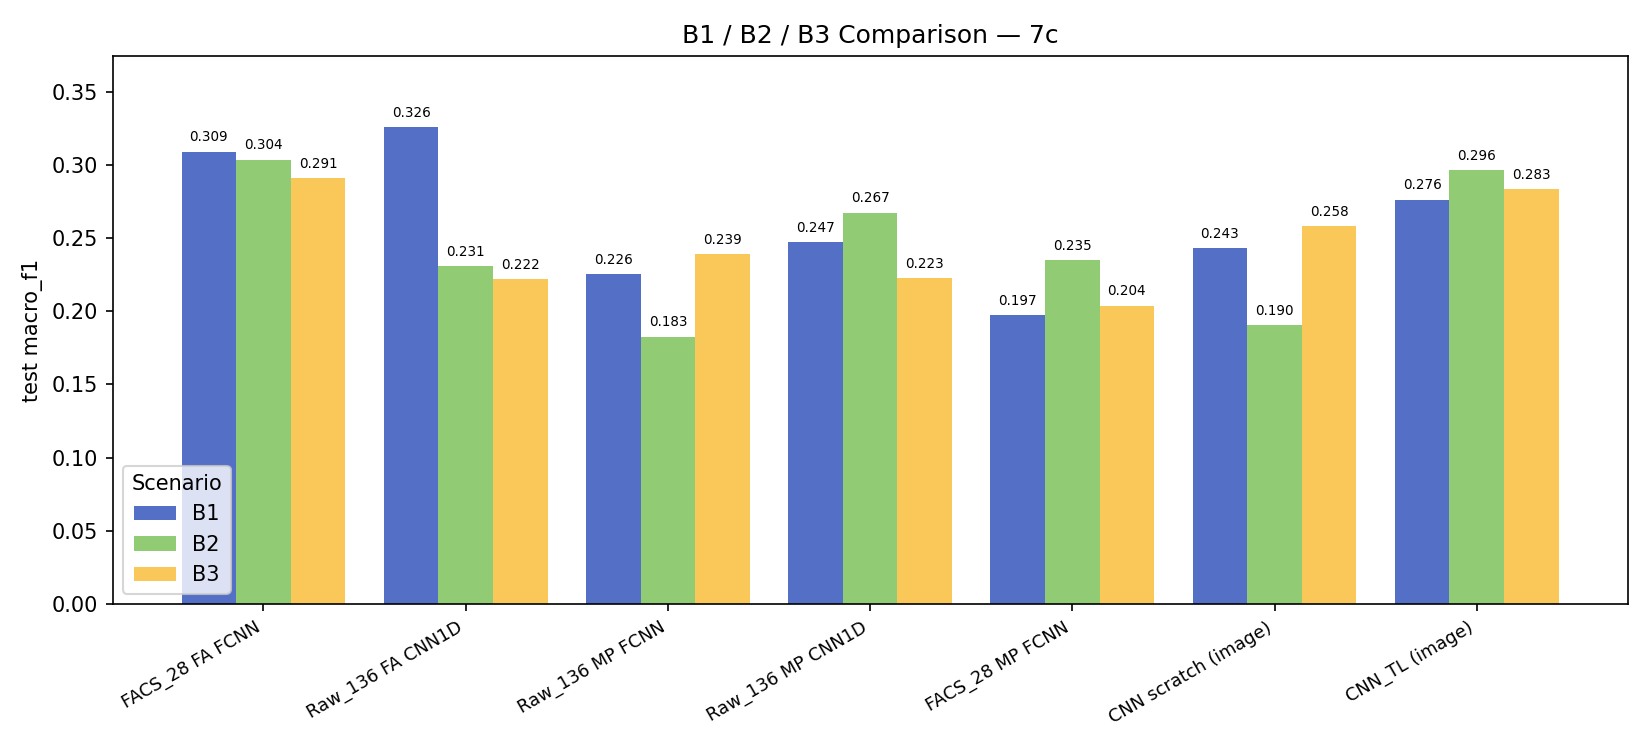

In [17]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'scenario_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'scenario_comparison_7c.png')))

### 4.4 Landmark Source: face-api.js vs MediaPipe

face-api.js (frame asli) vs MediaPipe (post face-crop 224×224, 478→68 mapping).


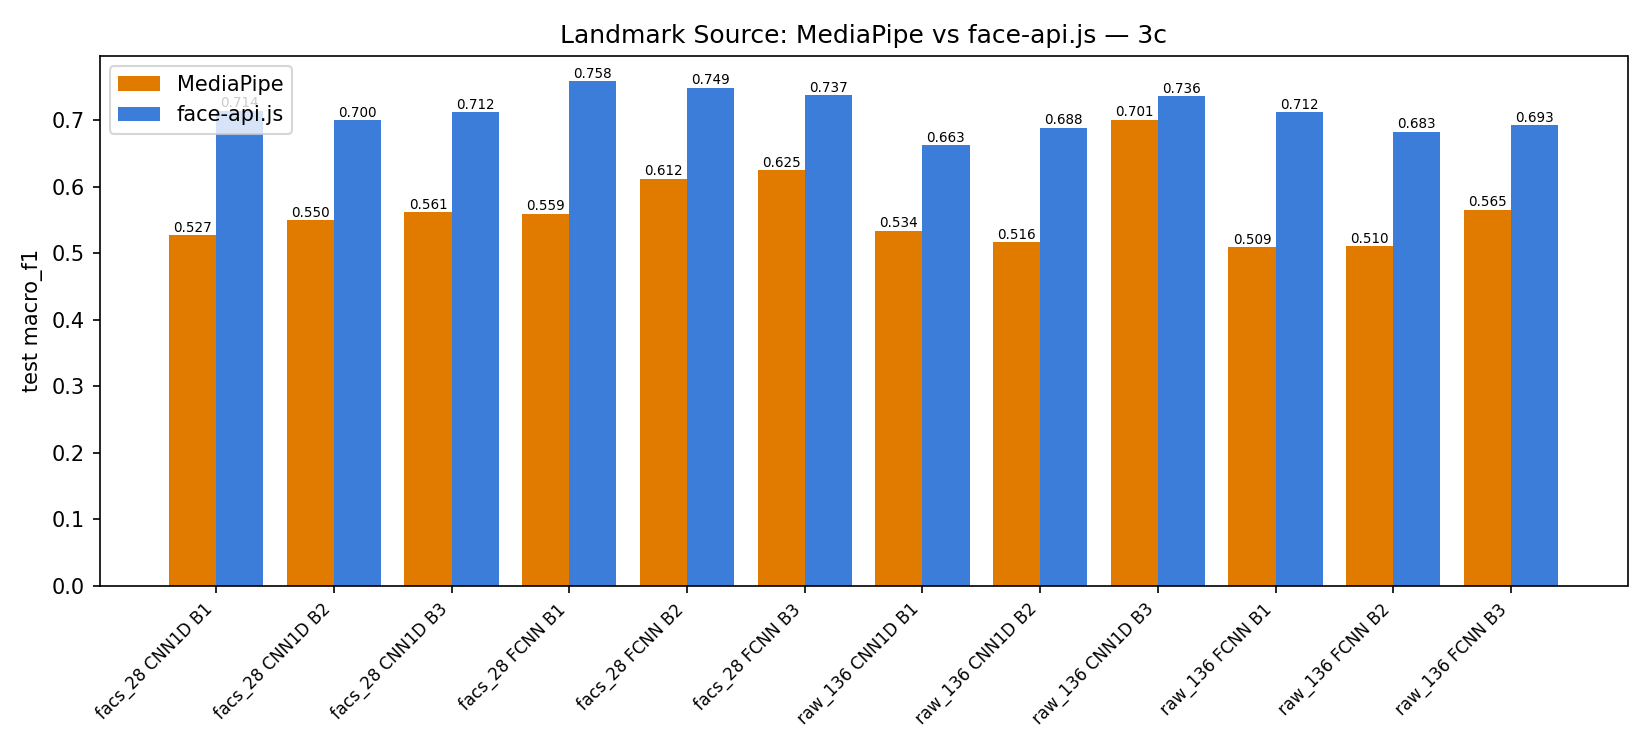

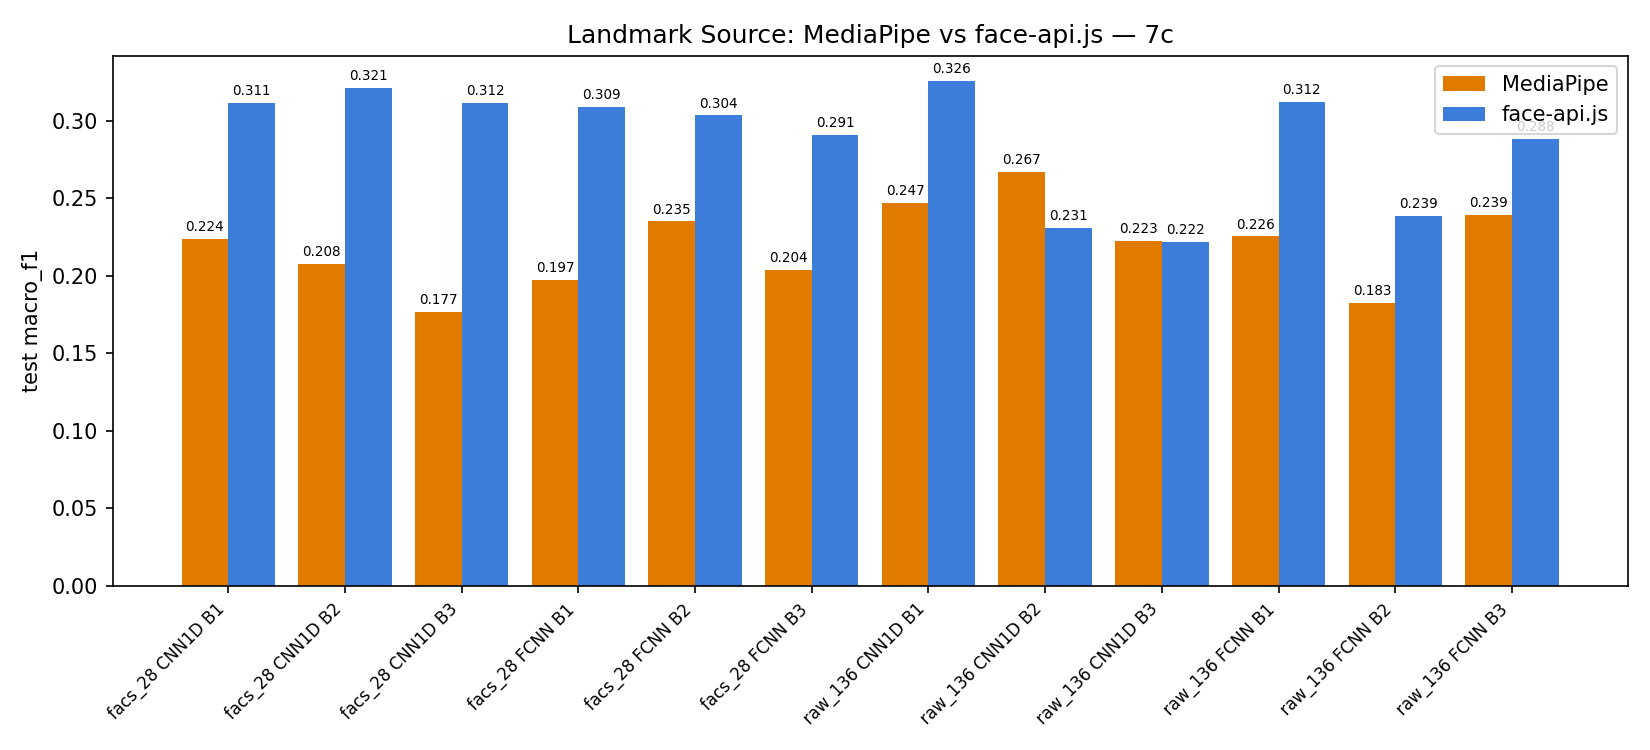

In [18]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'fa_vs_mp_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'fa_vs_mp_7c.png')))

### 4.5 Feature Comparison

Mean macro_f1 (atas arch × scenario) untuk tiap representasi landmark, dipecah per source. Error bar = range across arch × scenario.


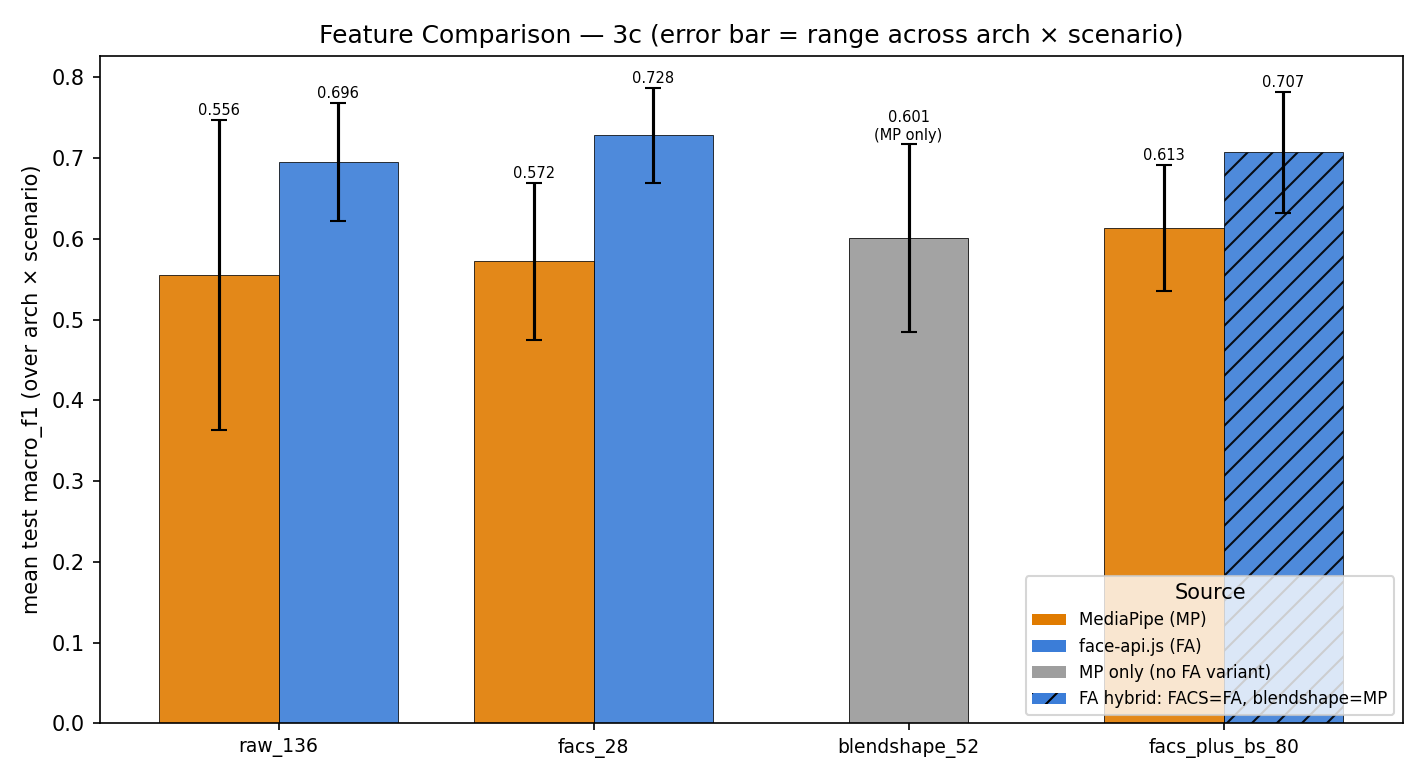

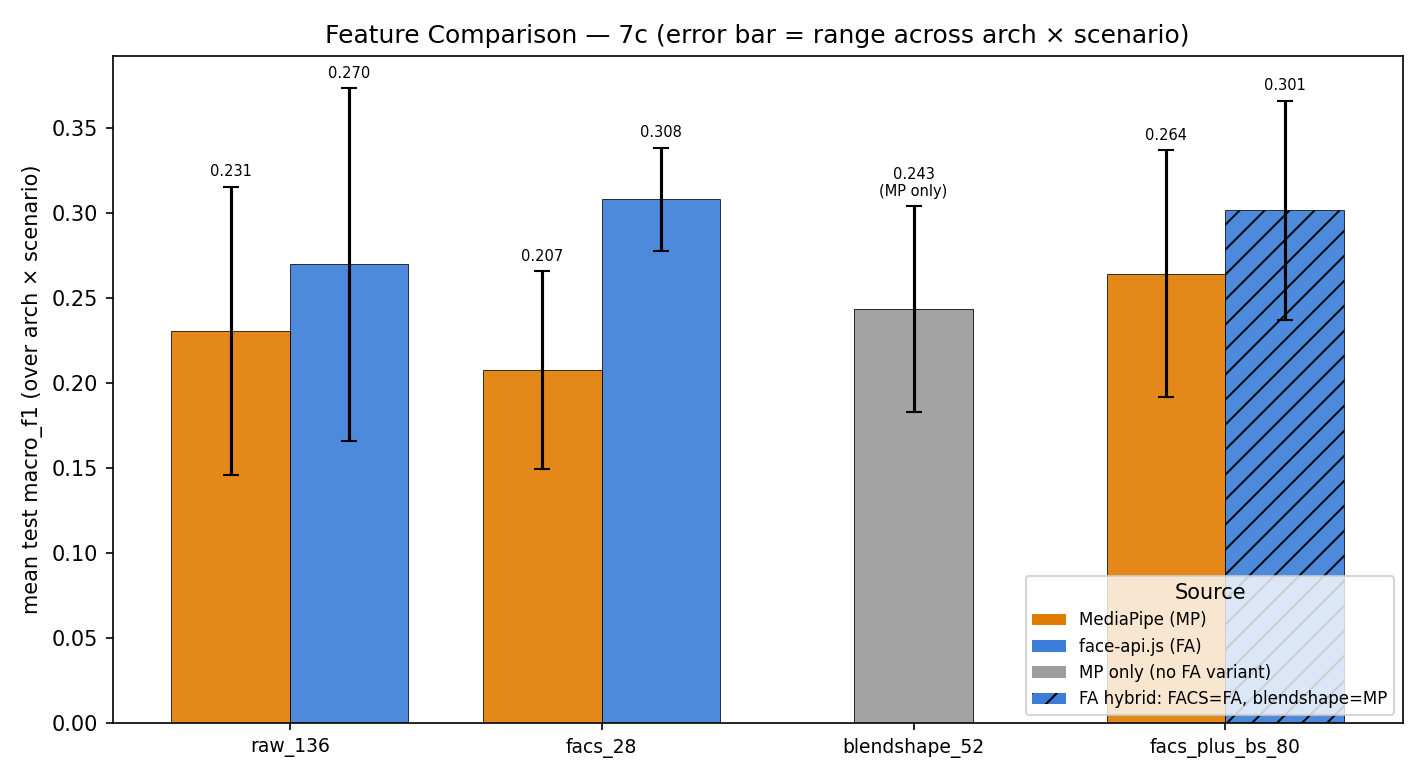

In [19]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'feature_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'feature_comparison_7c.png')))

#### 4.5.1 (Perbaikan) Feature Comparison — source-aware

> **Fix Gambar 5.8.** Pada versi sebelumnya bar `blendshape_52` dan `facs_plus_bs_80` **kosong** karena grouping MP vs FA tidak mengenali dua konvensi penamaan `run_key` (`mediapipe_raw_136_...` vs `blendshape_52_mediapipe_...`). Cell di bawah me-*regenerate* figure dengan parser yang robust:
> - `raw_136`, `facs_28`: bar **MP** dan **FA** terpisah
> - `blendshape_52`: satu bar **abu-abu** berlabel *MP only* (tidak ada varian face-api.js)
> - `facs_plus_bs_80`: bar **MP** + **FA**, dengan FA diberi *hatch* dan catatan legenda bahwa komponennya **hybrid** (FACS dari FA, blendshape dari MP)
>
> Nilai = mean `macro_f1` over arch × scenario; error bar = range. Output menimpa `docs/figures/unimodal/comparisons/feature_comparison_{3c,7c}.png` (yang ditampilkan di cell §4.5 di atas).

wrote feature_comparison_3c.png


wrote feature_comparison_7c.png


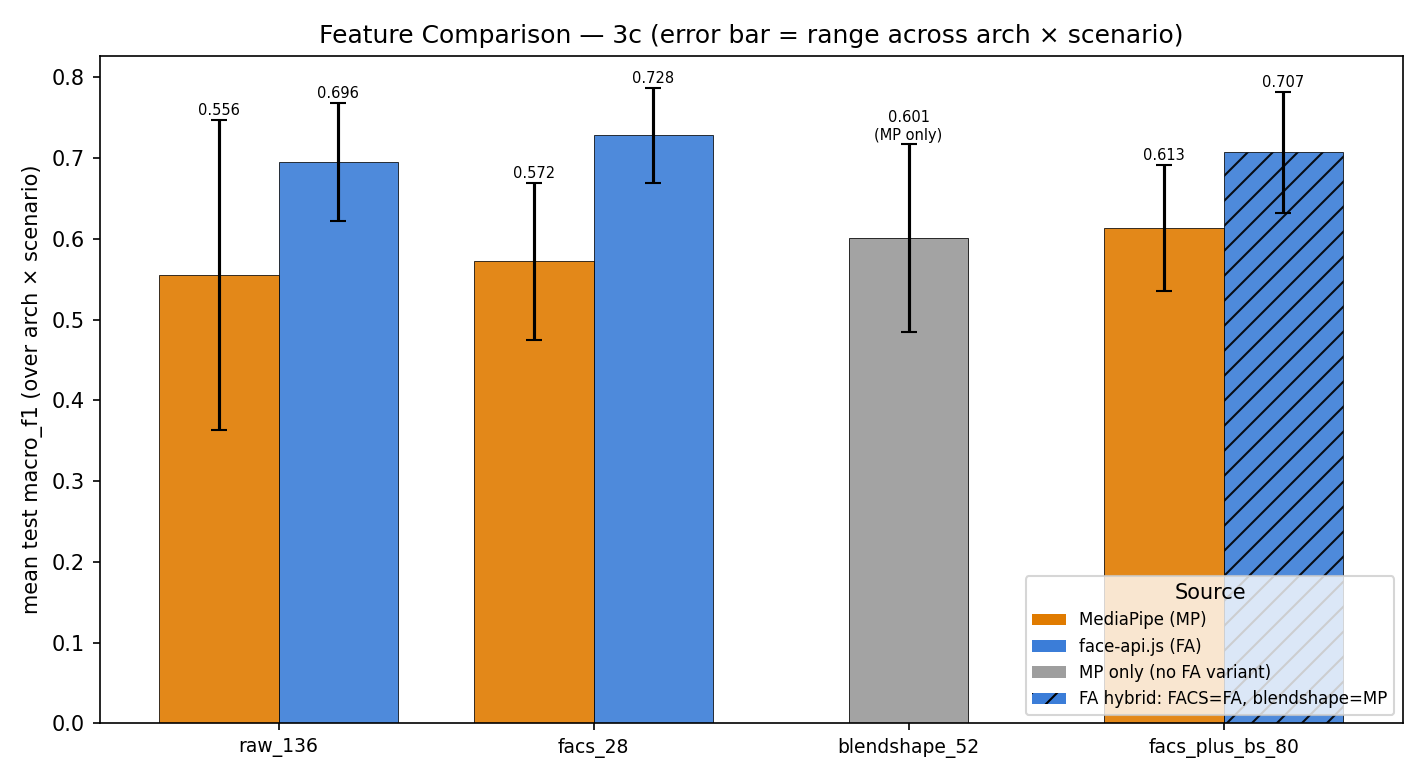

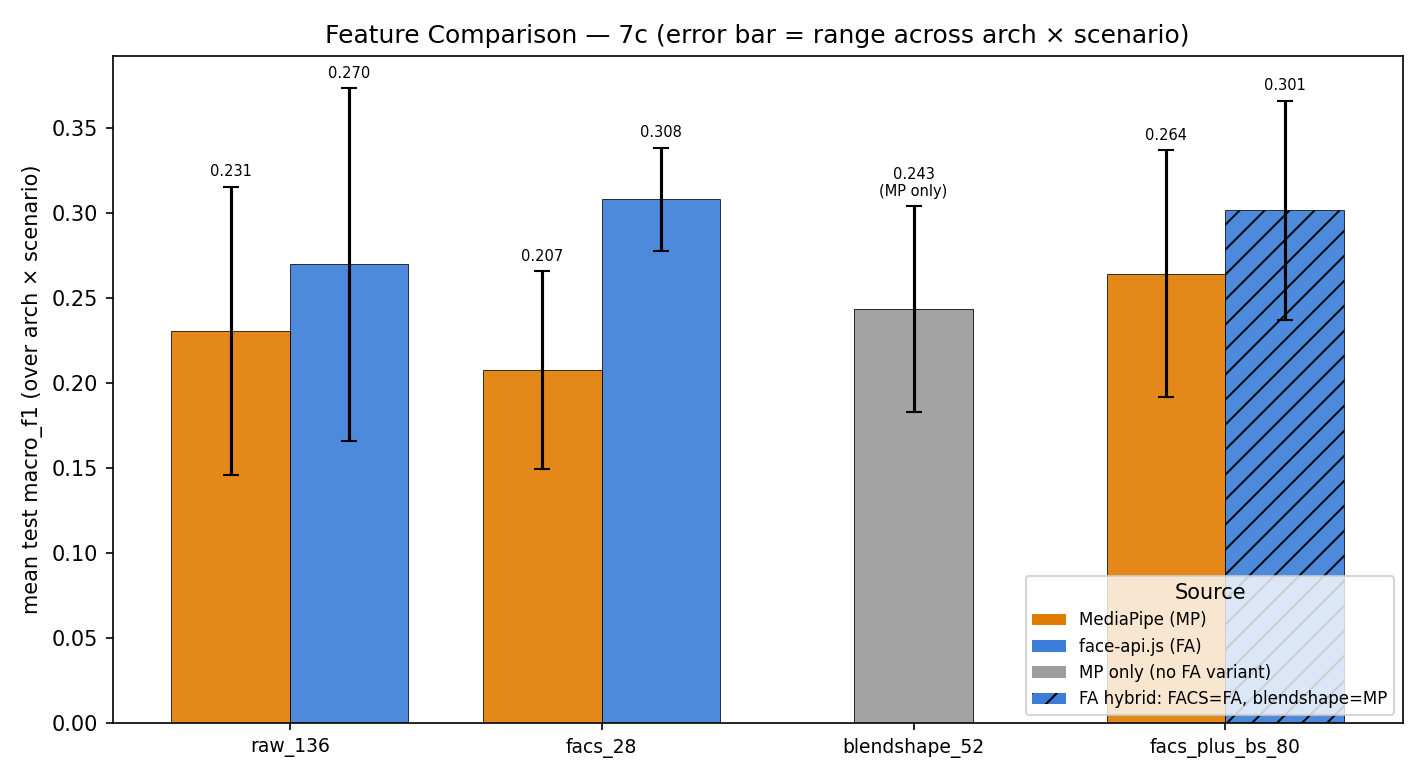

In [20]:
# === FIX: feature_comparison_{3c,7c}.png — source-aware (blendshape_52 MP-only, fb80 hybrid) ===
# Root cause: collect_landmark_rows / parse_landmark_key hanya mengenali run_key
# yang DIAWALI 'mediapipe'/'faceapi' (mis. mediapipe_raw_136_...). Namun key
# blendshape_52_mediapipe_... dan facs_plus_bs_80_mediapipe_... diawali nama
# feature, sehingga ter-skip -> bar kosong. Parser di bawah mencari token source
# di posisi mana pun.
from matplotlib.patches import Patch

MP_COLOR, FA_COLOR, MPONLY_COLOR = "#e07b00", "#3b7dd8", "#9e9e9e"
FEAT_ORDER = ["raw_136", "facs_28", "blendshape_52", "facs_plus_bs_80"]
MP_ONLY_FEATURES = {"blendshape_52"}        # tidak ada varian face-api.js
HYBRID_FA_FEATURES = {"facs_plus_bs_80"}    # FA = FACS(FA) + blendshape(MP)


def collect_landmark_rows_robust(runs):
    """Parse run_key landmark tanpa peduli urutan token (source-first / feature-first)."""
    rows = []
    for r in runs:
        parts = r['_run_key'].split('_')
        src_idx = next((i for i, p in enumerate(parts) if p in ('mediapipe', 'faceapi')), None)
        if src_idx is None:
            continue  # baris image CNN — ditangani terpisah
        source = 'MP' if parts[src_idx] == 'mediapipe' else 'FA'
        arch, scn, scheme = parts[-3], parts[-2].upper(), parts[-1]
        feature = '_'.join(p for j, p in enumerate(parts[:-3]) if j != src_idx)
        rows.append({'source': source, 'feature': feature, 'arch': arch,
                     'scenario': scn, 'scheme': scheme,
                     'mf1': r.get('test', {}).get('macro_f1')})
    return rows


def _feat_stats(lm, feature, source, scheme):
    vals = [r['mf1'] for r in lm if r['feature'] == feature and r['source'] == source
            and r['scheme'] == scheme and r['mf1'] is not None]
    return (np.mean(vals), np.max(vals) - np.min(vals)) if vals else None


def fig_feature_compare_fixed(scheme):
    lm = collect_landmark_rows_robust(primer[scheme])
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    width, x = 0.38, np.arange(len(FEAT_ORDER))
    has_hybrid = False
    for xi, feat in enumerate(FEAT_ORDER):
        if feat in MP_ONLY_FEATURES:
            st = _feat_stats(lm, feat, 'MP', scheme)
            if st:
                m, e = st
                ax.bar(xi, m, width, yerr=e, capsize=4, color=MPONLY_COLOR,
                       alpha=0.95, edgecolor='black', linewidth=0.4)
                ax.text(xi, m + e + 0.006, f"{m:.3f}\n(MP only)", ha='center', fontsize=7)
            continue
        for j, src in enumerate(('MP', 'FA')):
            st = _feat_stats(lm, feat, src, scheme)
            if st is None:
                continue
            m, e = st
            offset = (j - 0.5) * width
            hatch = '//' if (src == 'FA' and feat in HYBRID_FA_FEATURES) else None
            ax.bar(xi + offset, m, width, yerr=e, capsize=4,
                   color=MP_COLOR if src == 'MP' else FA_COLOR, alpha=0.9,
                   hatch=hatch, edgecolor='black', linewidth=0.4)
            ax.text(xi + offset, m + e + 0.006, f"{m:.3f}", ha='center', fontsize=7)
            has_hybrid = has_hybrid or bool(hatch)
    ax.set_xticks(x); ax.set_xticklabels(FEAT_ORDER, fontsize=9)
    ax.set_ylabel("mean test macro_f1 (over arch × scenario)")
    ax.set_title(f"Feature Comparison — {scheme} (error bar = range across arch × scenario)")
    handles = [Patch(facecolor=MP_COLOR, label='MediaPipe (MP)'),
               Patch(facecolor=FA_COLOR, label='face-api.js (FA)'),
               Patch(facecolor=MPONLY_COLOR, label='MP only (no FA variant)')]
    if has_hybrid:
        handles.append(Patch(facecolor=FA_COLOR, hatch='//',
                             label='FA hybrid: FACS=FA, blendshape=MP'))
    ax.legend(handles=handles, title='Source', fontsize=8)
    plt.tight_layout()
    out = FIG_ROOT / 'comparisons' / f'feature_comparison_{scheme}.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150); plt.close(fig)
    print('wrote', out.name)


for _sc in ('3c', '7c'):
    fig_feature_compare_fixed(_sc)
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'feature_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT / 'comparisons' / 'feature_comparison_7c.png')))

### 4.6 Architecture Comparison: FCNN vs CNN1D

Mean macro_f1 (atas scenarios) untuk FCNN vs CNN1D pada tiap (feature, source).


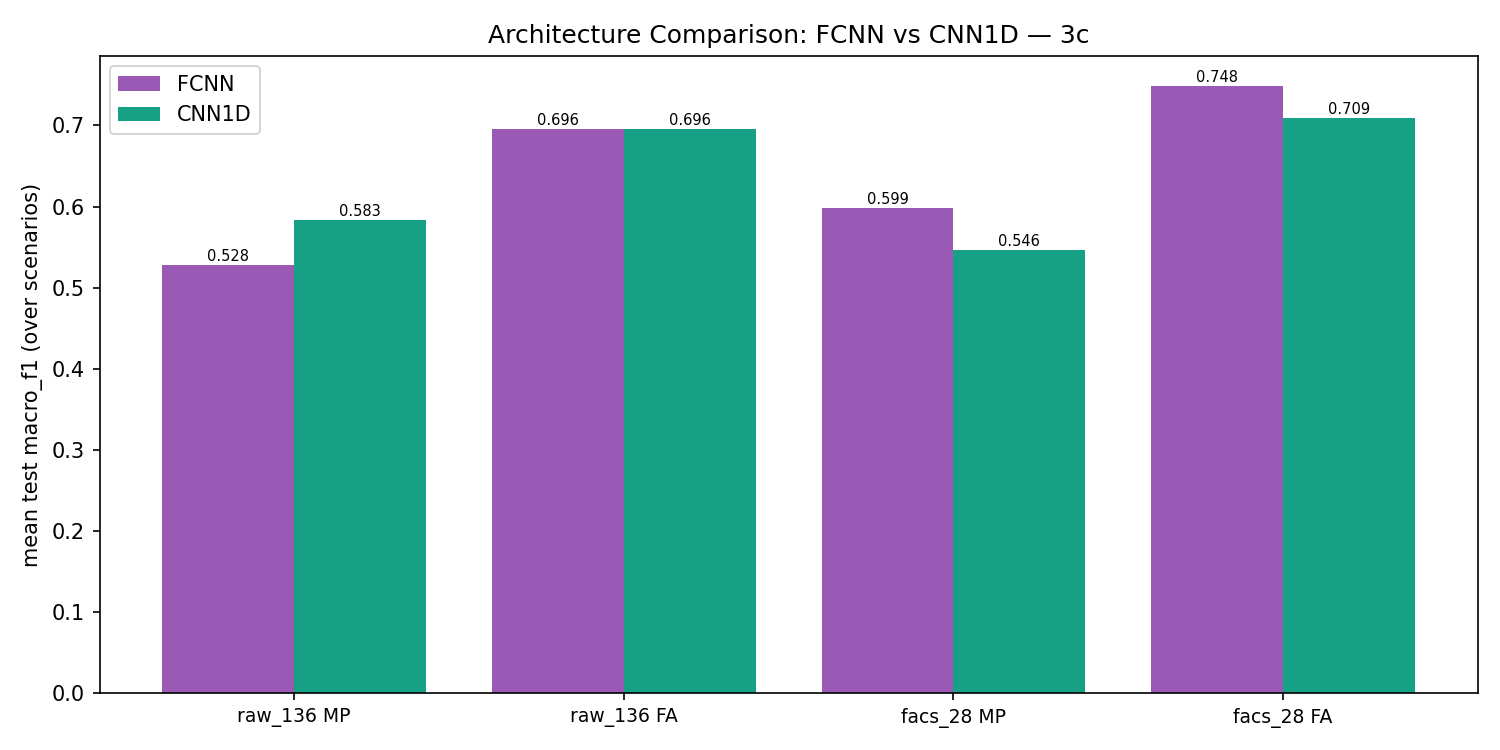

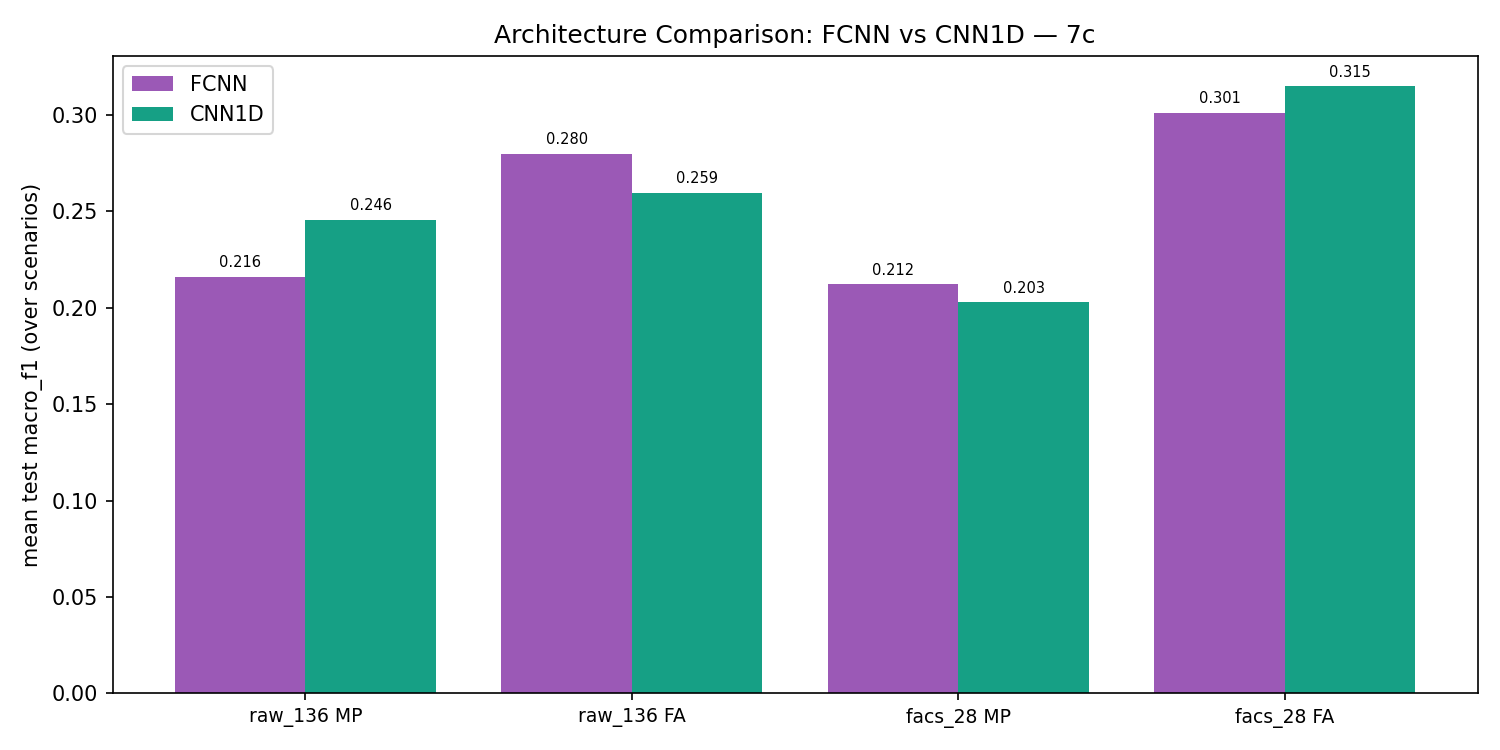

In [21]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'arch_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'arch_comparison_7c.png')))

### 4.7 Confusion Matrices — Top Model per Kategori


--- best landmark 3c ---


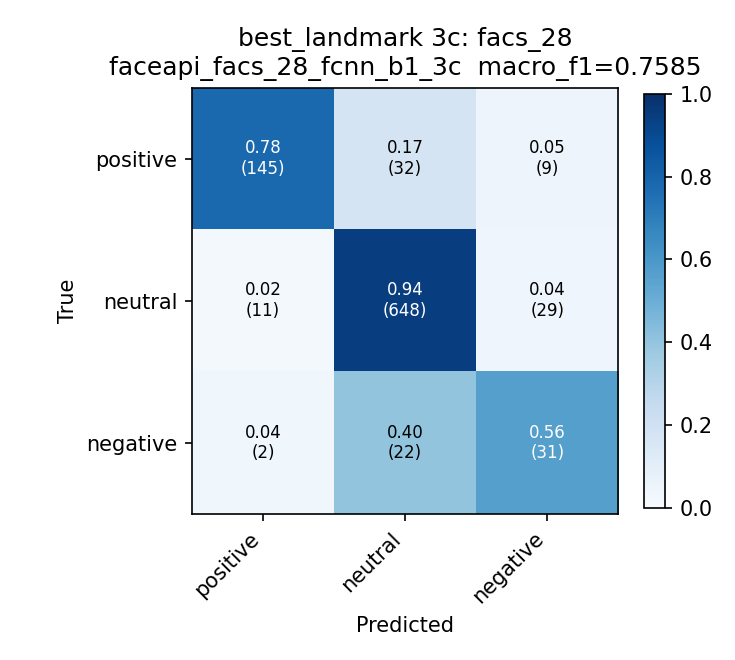

--- best image 3c ---


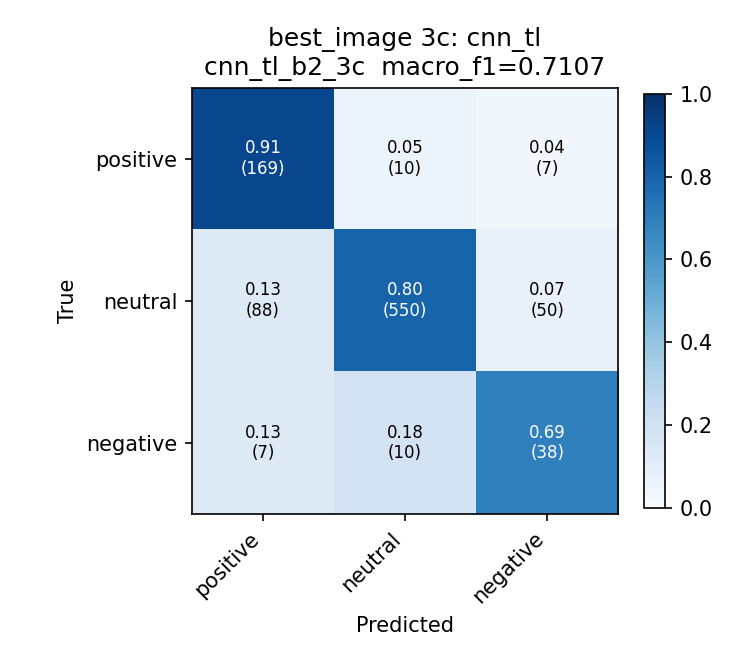

--- best landmark 7c ---


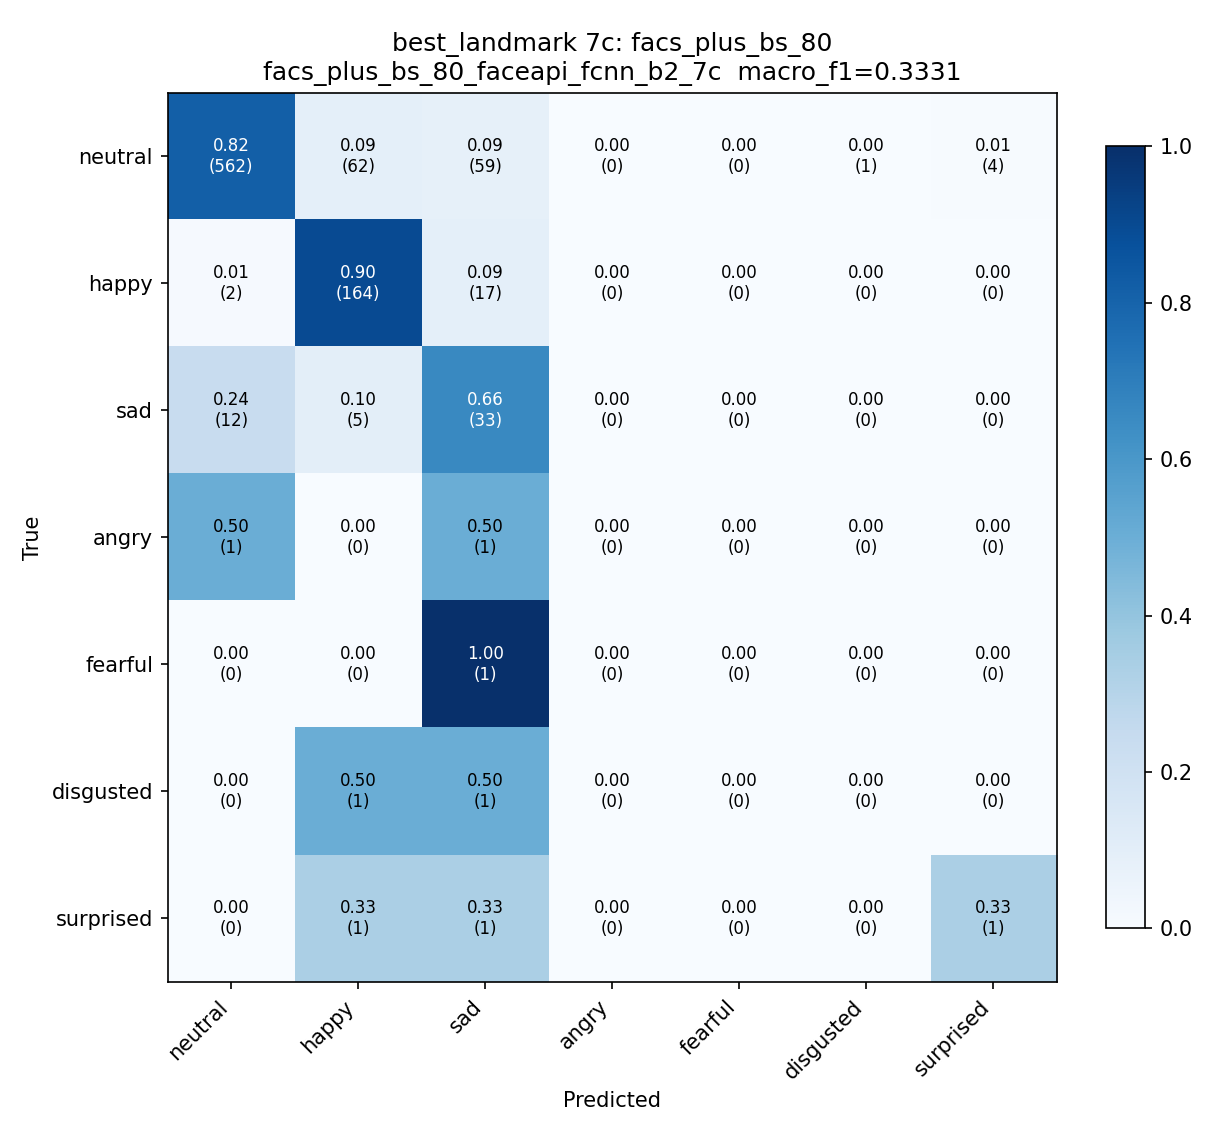

--- best image 7c ---


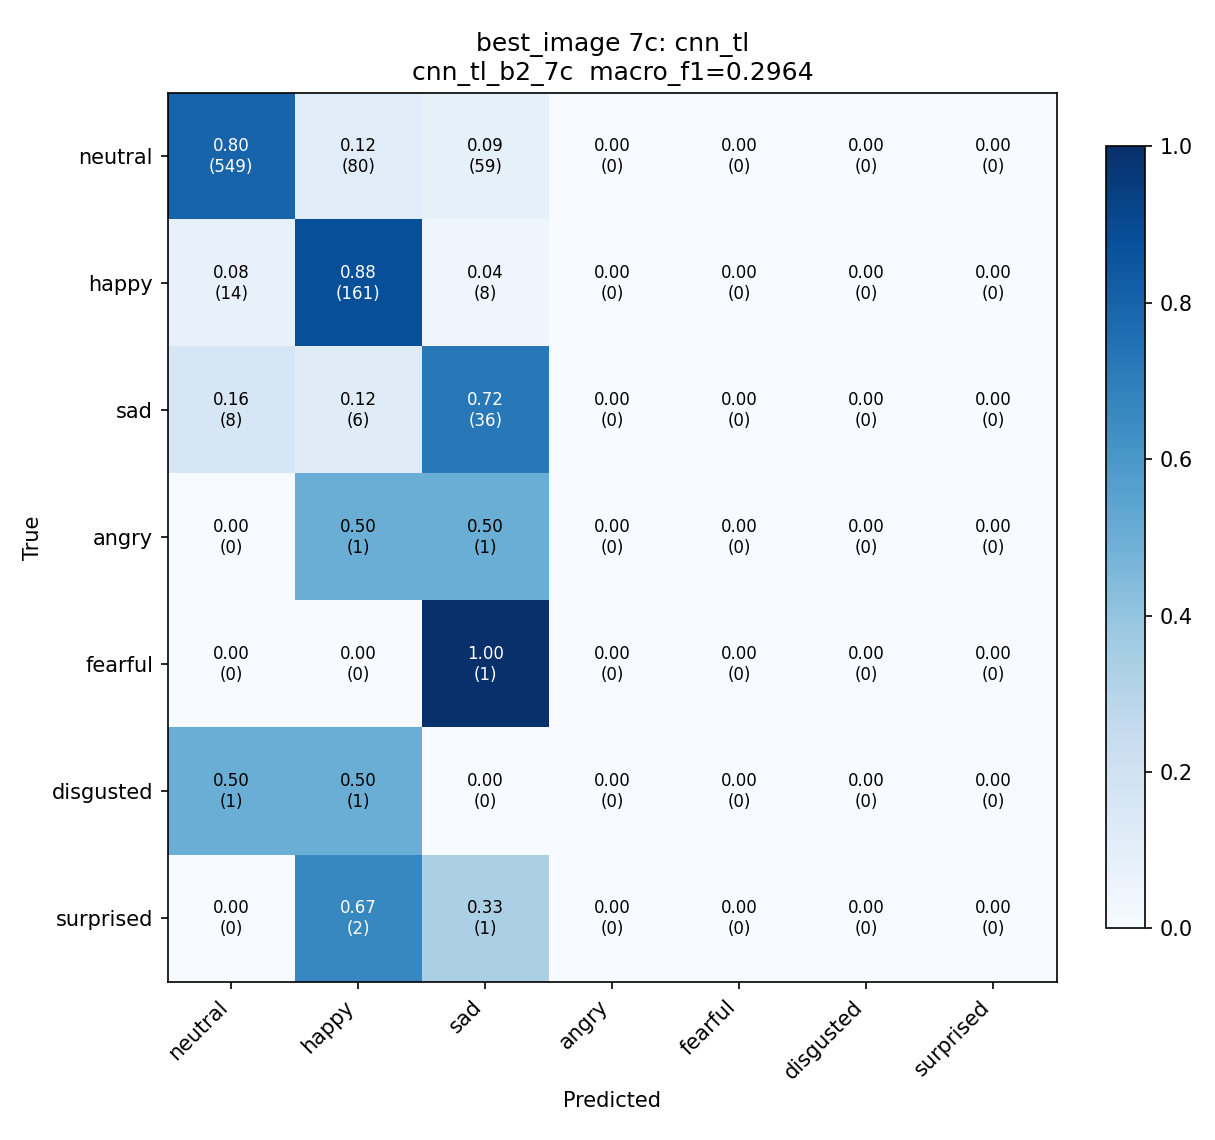

In [22]:
print('--- best landmark 3c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_landmark_3c.png')))
print('--- best image 3c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_image_3c.png')))
print('--- best landmark 7c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_landmark_7c.png')))
print('--- best image 7c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_image_7c.png')))

### 4.8 Per-class F1 — Top-3 Models

F1 per kelas untuk top-3 model unimodal. Berguna untuk melihat dampak class imbalance ke kelas minoritas.


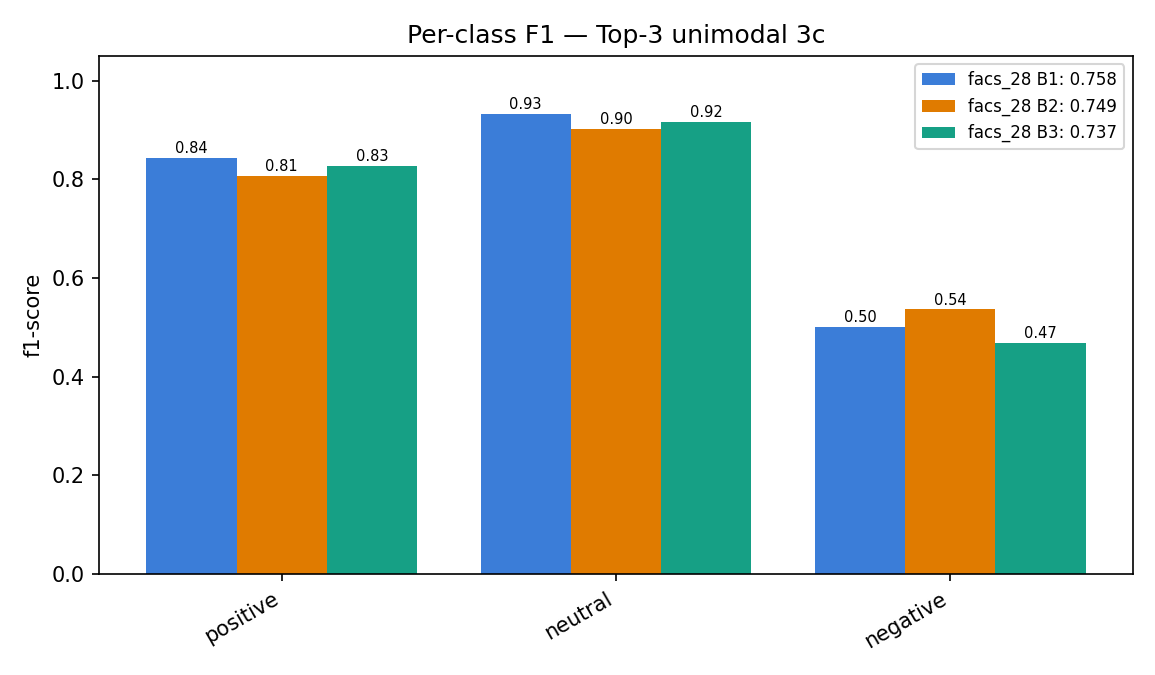

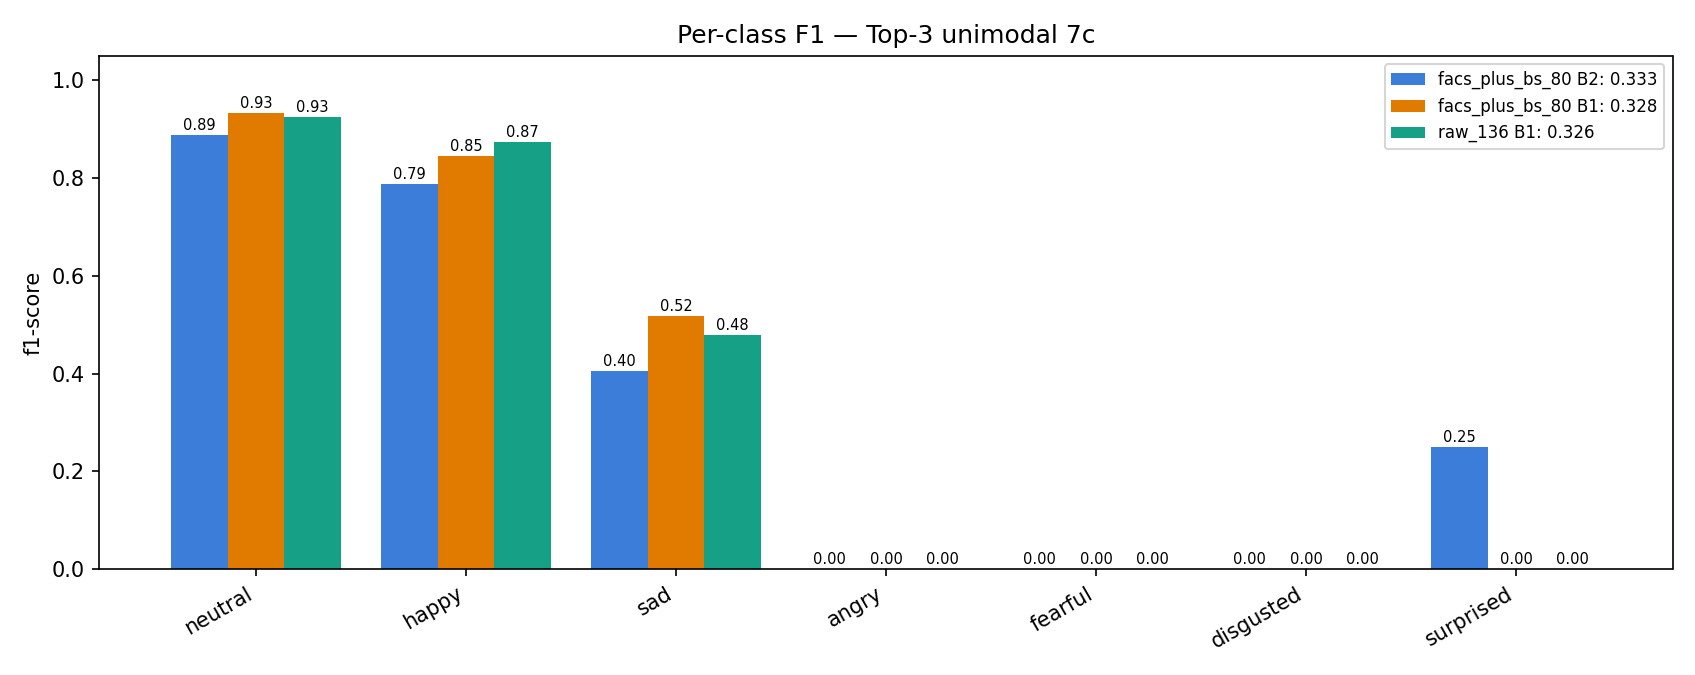

In [23]:
display(Image(filename=str(FIG_ROOT/'per_class'/'top3_per_class_f1_3c.png')))
display(Image(filename=str(FIG_ROOT/'per_class'/'top3_per_class_f1_7c.png')))

### 4.9 Training Curves — Top-3 per Kategori

Per-epoch `val_macro_f1` untuk top-3 landmark + top-3 image. Bintang ⭐ = best epoch yang dipilih untuk evaluasi test.


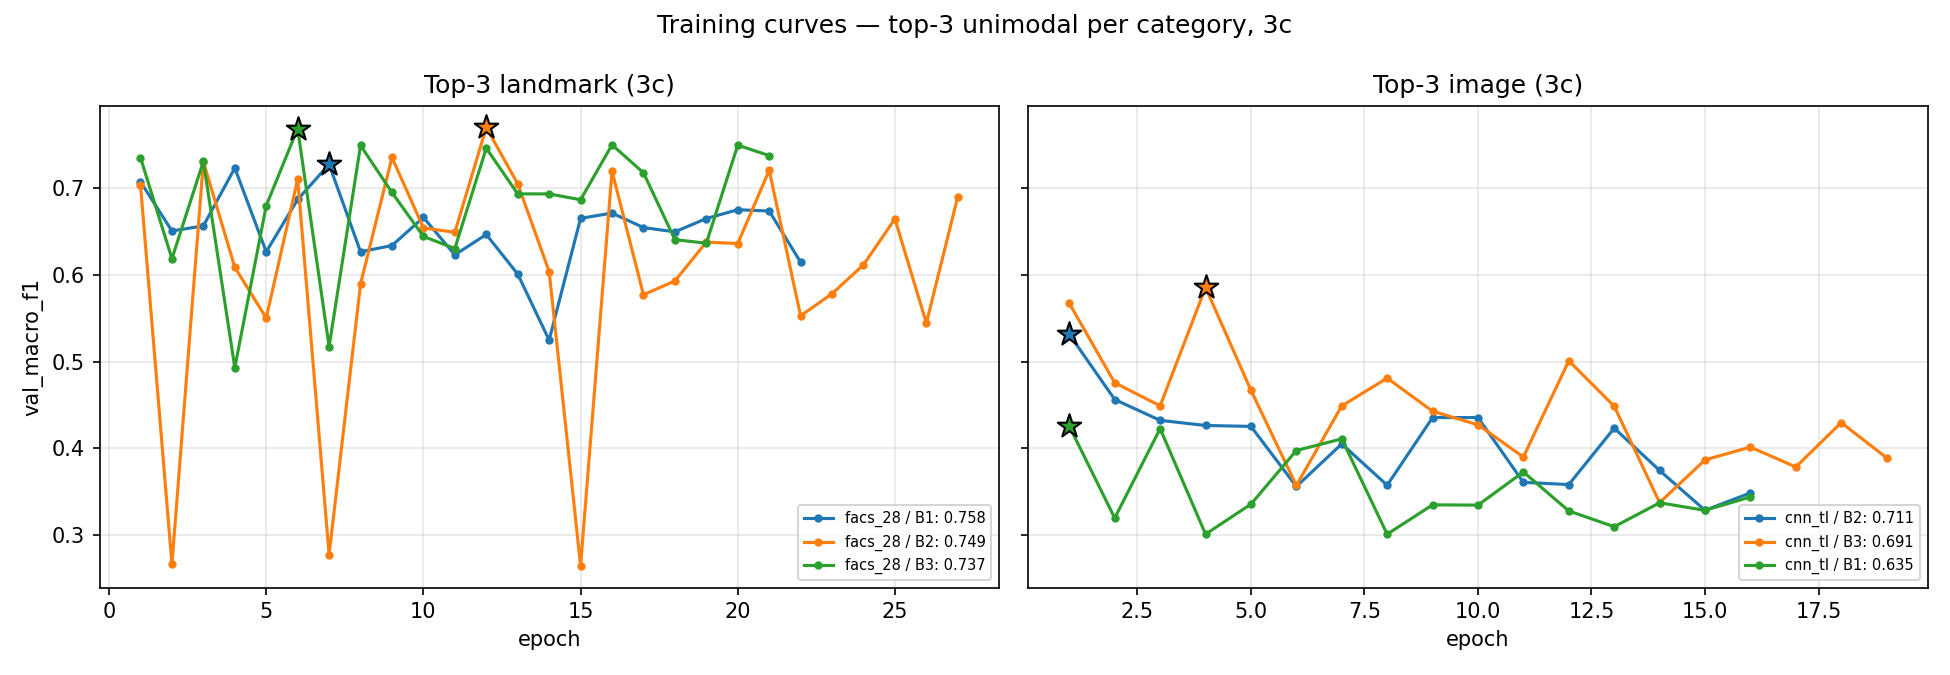

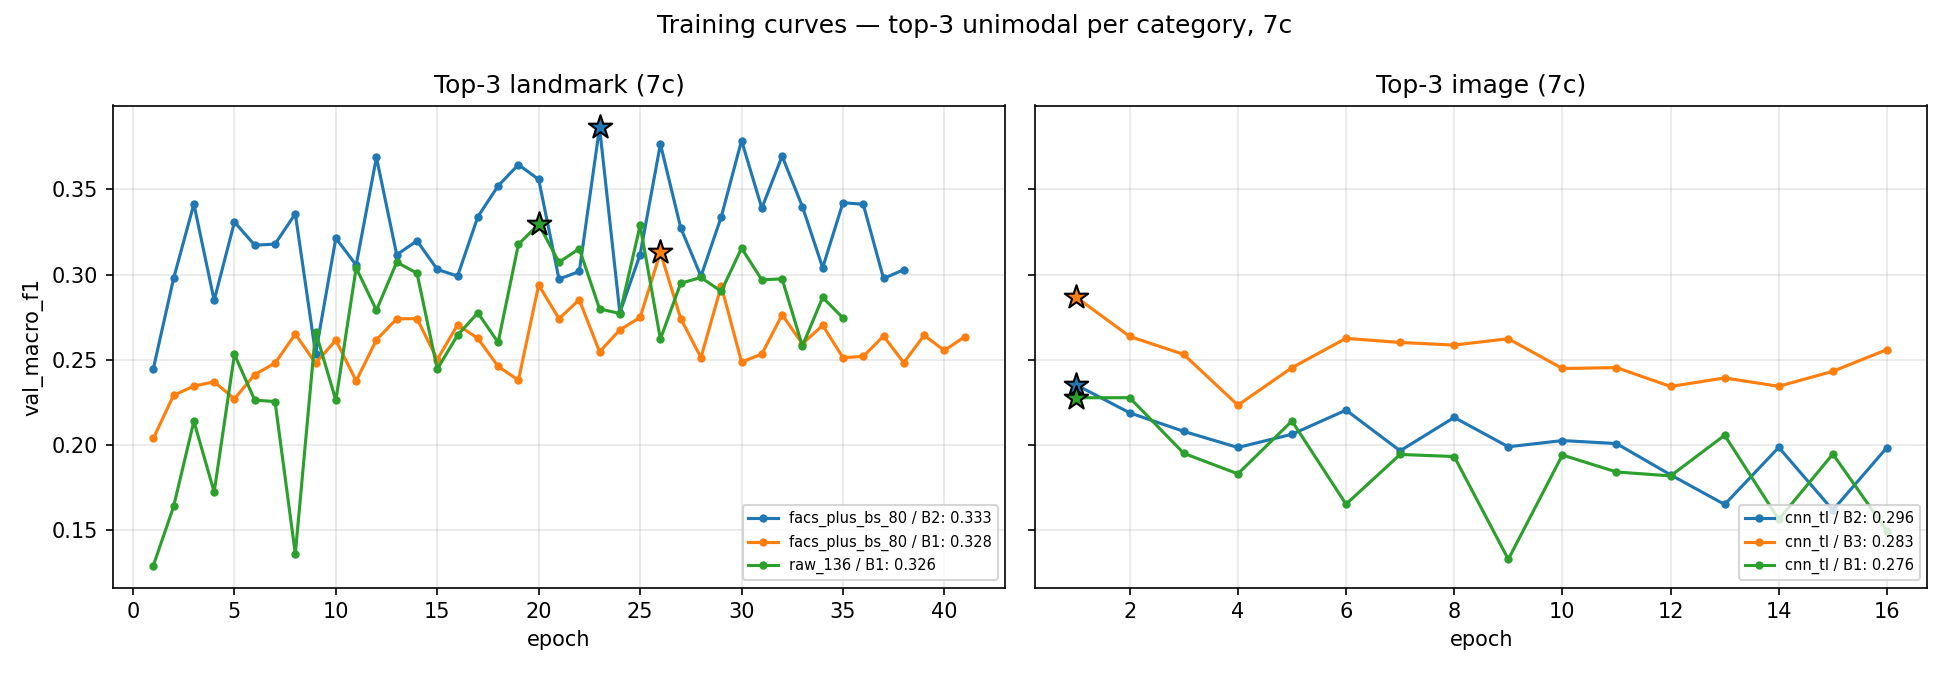

In [24]:
display(Image(filename=str(FIG_ROOT/'training_curves'/'top3_3c.png')))
display(Image(filename=str(FIG_ROOT/'training_curves'/'top3_7c.png')))

#### 4.9.1 Konvergensi Top-3 per Modalitas (legend anonim)

> Training curves `val_macro_f1` per epoch untuk **top-3 landmark** (panel kiri) dan **top-3 image/CNN** (panel kanan), per scheme. Legend **sengaja tidak menyebut representasi fitur** (raw_136/facs_28/blendshape_52/facs_plus_bs_80) agar tidak membocorkan detail dekomposisi yang baru dibahas di RQ berikutnya — cukup `Top-k {modalitas} (skenario, val best)`. ★ = best epoch. Output: `docs/figures/unimodal/training_curves/top3_convergence_{7c,3c}.png`.


wrote top3_convergence_7c.png


wrote top3_convergence_3c.png


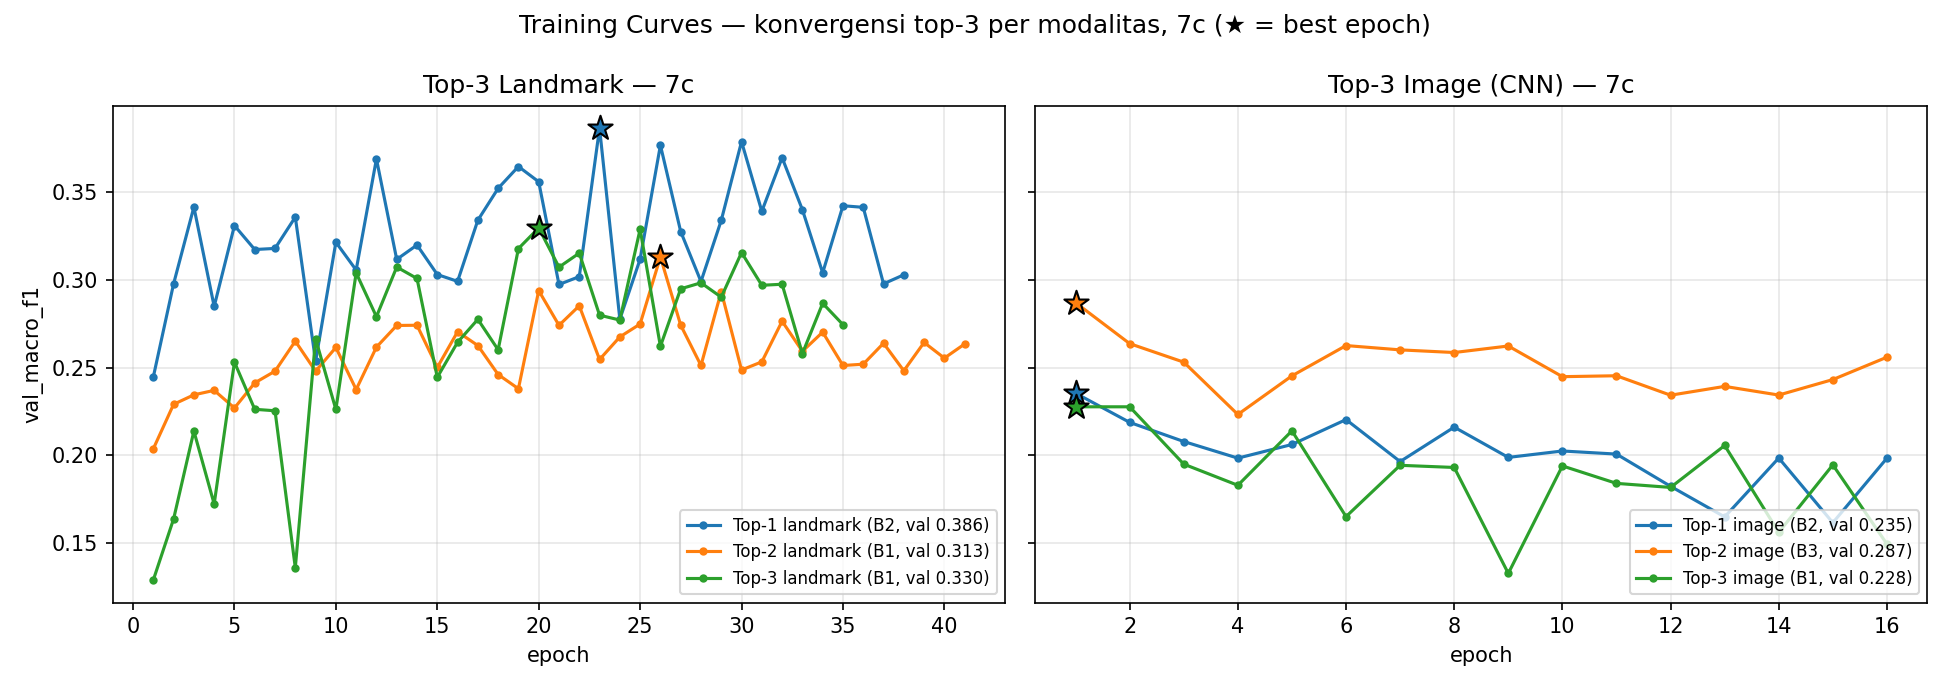

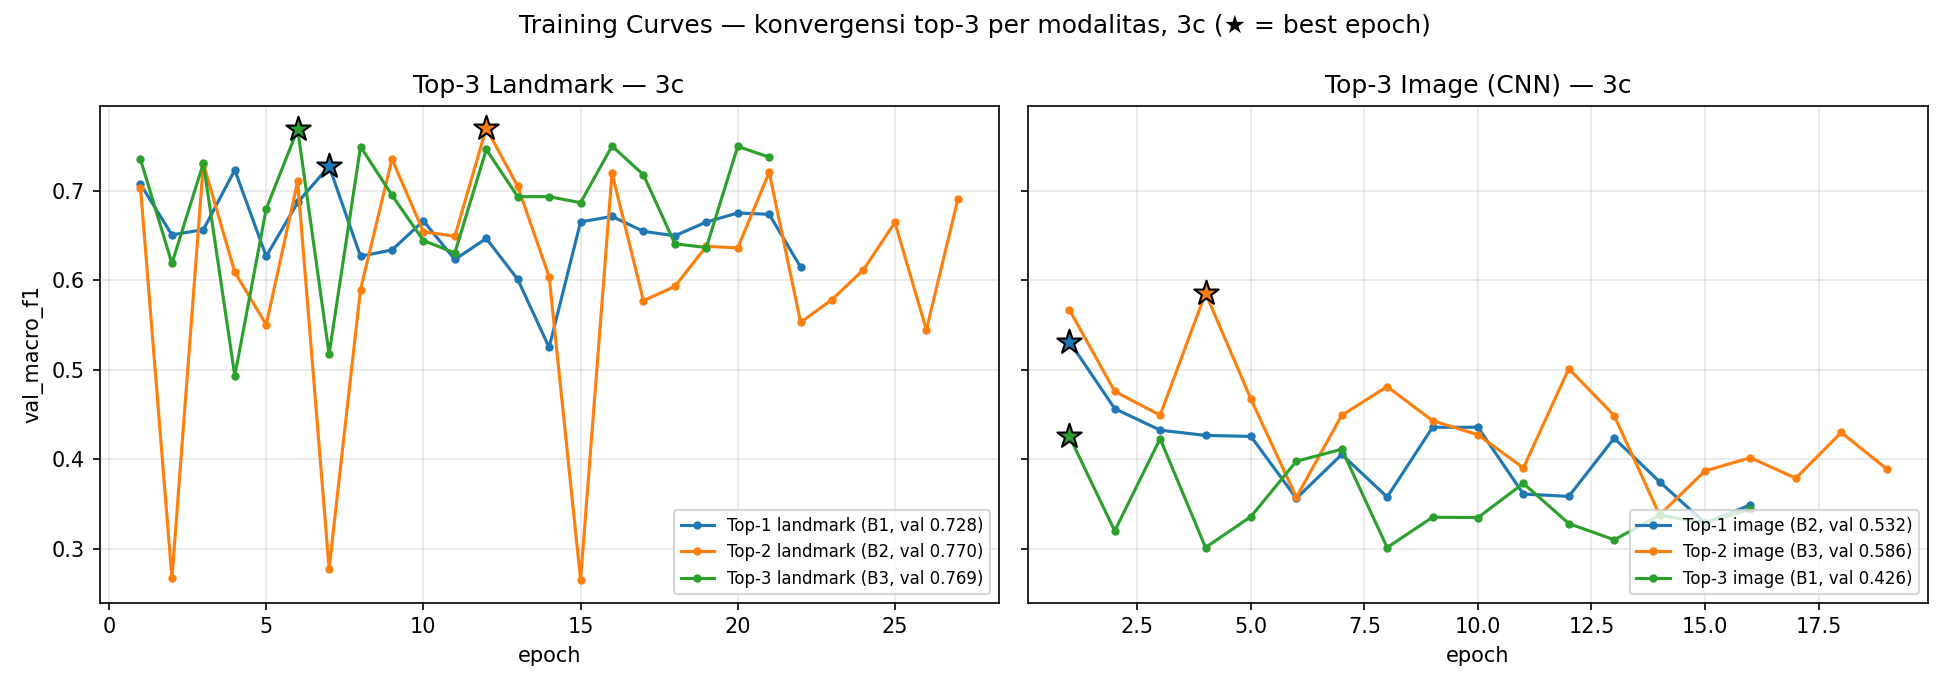

In [25]:
# === NEW: Training Curves anonim — konvergensi top-3 per modalitas (tanpa nama fitur) ===
# Legend tidak menyebut representasi fitur (raw_136/facs_28/blendshape_52/
# facs_plus_bs_80) agar tidak membocorkan detail dekomposisi yang dibahas di RQ
# berikutnya. Label = peringkat + modalitas + skenario + best val_macro_f1.
def _best_mf1(r):
    return r.get('test', {}).get('macro_f1')


def fig_training_curves_anon(scheme):
    runs = primer[scheme]
    cats = [('Landmark', {'raw_136', 'facs_28', 'blendshape_52', 'facs_plus_bs_80'}, 'landmark'),
            ('Image (CNN)', {'cnn_scratch', 'cnn_tl'}, 'image')]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    for ax, (title, dirs, tag) in zip(axes, cats):
        cand = [r for r in runs if r['_method_dir'] in dirs and _best_mf1(r) is not None]
        cand.sort(key=_best_mf1, reverse=True)
        for i, r in enumerate(cand[:3], start=1):
            hist = r.get('training', {}).get('history', [])
            if not hist:
                continue
            ep = [h['epoch'] for h in hist]
            val = [h.get('val_macro_f1') for h in hist]
            be = r.get('training', {}).get('best_epoch')
            if be is not None and 1 <= be <= len(val):
                best_val = val[be - 1]
            else:
                best_val = max(v for v in val if v is not None)
            scn = r.get('hyperparams', {}).get('scenario', '?')
            label = f'Top-{i} {tag} ({scn}, val {best_val:.3f})'
            line, = ax.plot(ep, val, marker='o', markersize=3, linewidth=1.5, label=label)
            if be is not None and 1 <= be <= len(val):
                ax.scatter([be], [val[be - 1]], marker='*', s=150,
                           color=line.get_color(), edgecolor='k', zorder=10)
        ax.set_xlabel('epoch')
        ax.set_title(f'Top-3 {title} — {scheme}')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)
    axes[0].set_ylabel('val_macro_f1')
    plt.suptitle(f'Training Curves — konvergensi top-3 per modalitas, {scheme} (★ = best epoch)')
    plt.tight_layout()
    out = FIG_ROOT / 'training_curves' / f'top3_convergence_{scheme}.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print('wrote', out.name)


for _sc in ('7c', '3c'):
    fig_training_curves_anon(_sc)
display(Image(filename=str(FIG_ROOT / 'training_curves' / 'top3_convergence_7c.png')))
display(Image(filename=str(FIG_ROOT / 'training_curves' / 'top3_convergence_3c.png')))

### 4.10 Resource Usage

Training time, model size (params), dan peak VRAM untuk tiap metode (mean across scenarios).


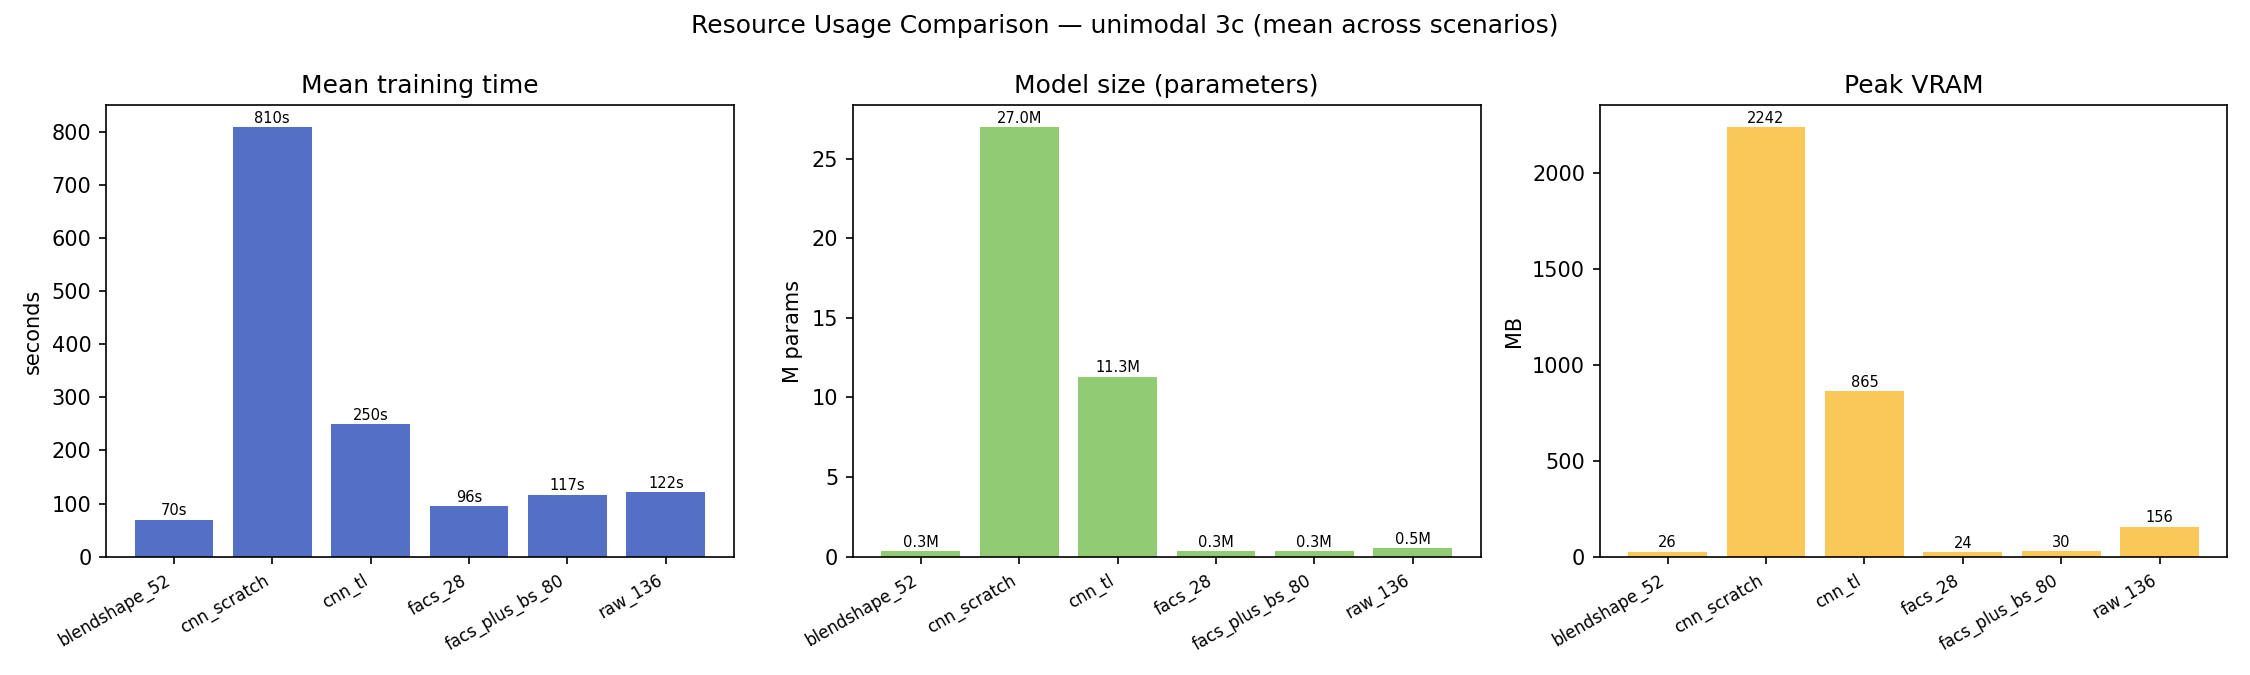

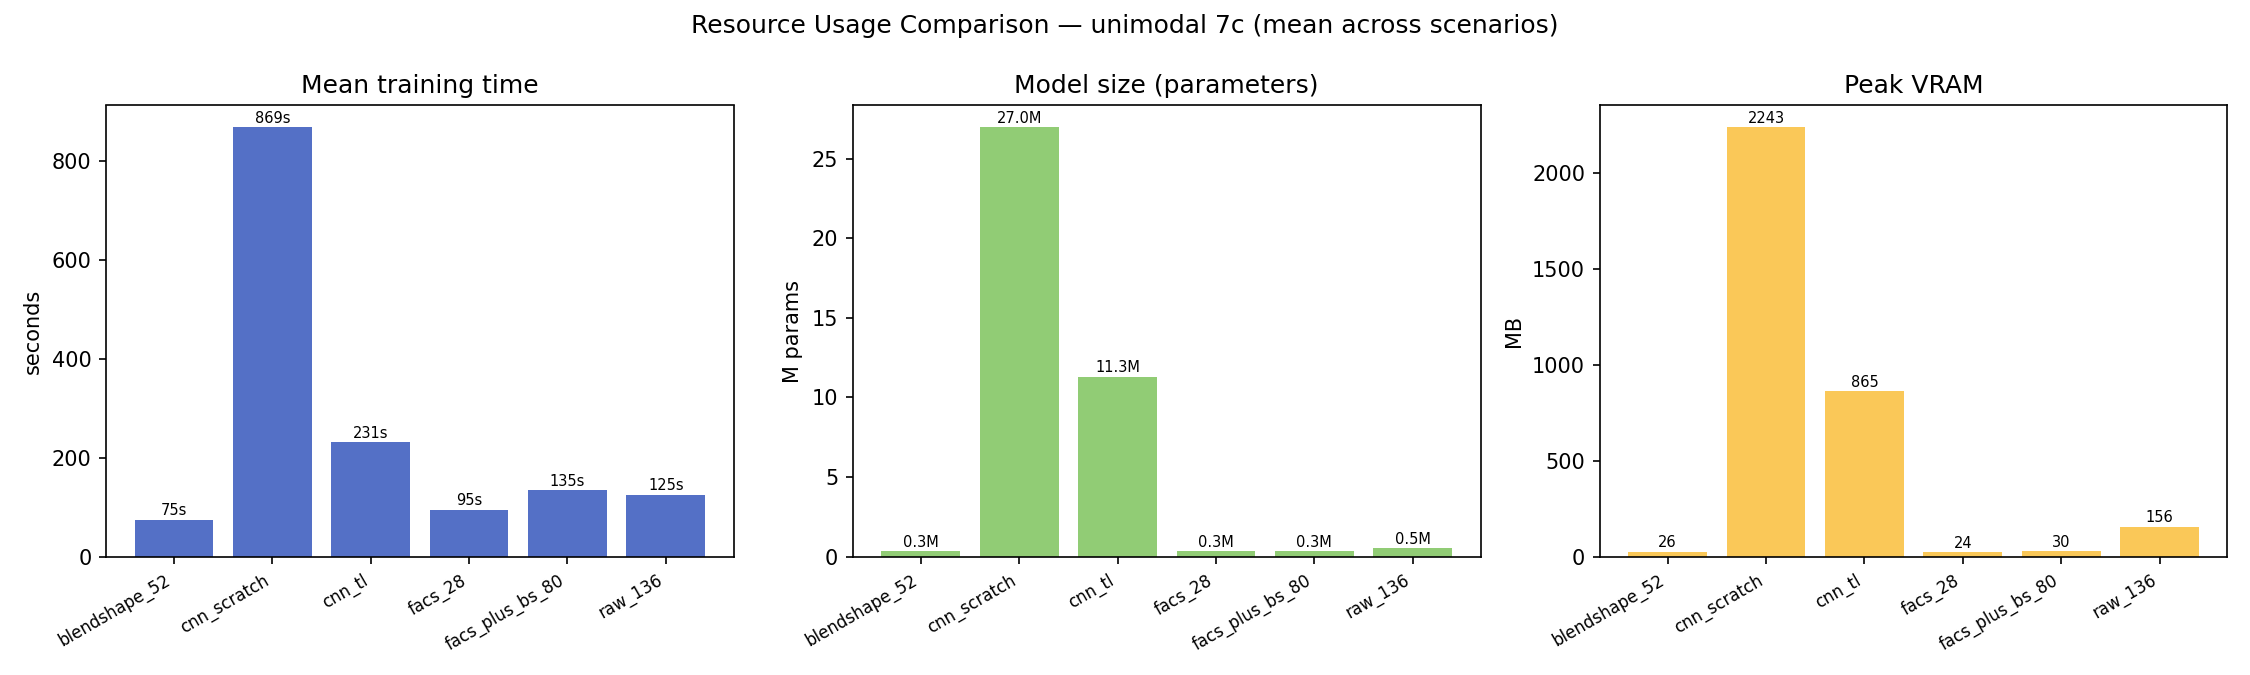

In [26]:
display(Image(filename=str(FIG_ROOT/'resources'/'resource_compare_3c.png')))
display(Image(filename=str(FIG_ROOT/'resources'/'resource_compare_7c.png')))

### 4.11 Class Distribution: Primer + semua benchmark

Distribusi kelas (train split) untuk Primer dan 4 benchmark (KDEF, RAF-DB, CK+, JAFFE).
Primer punya class imbalance ekstrem; benchmark bervariasi (KDEF perfectly balanced;
CK+/JAFFE relatif balanced; RAF-DB skewed seperti dataset in-the-wild).


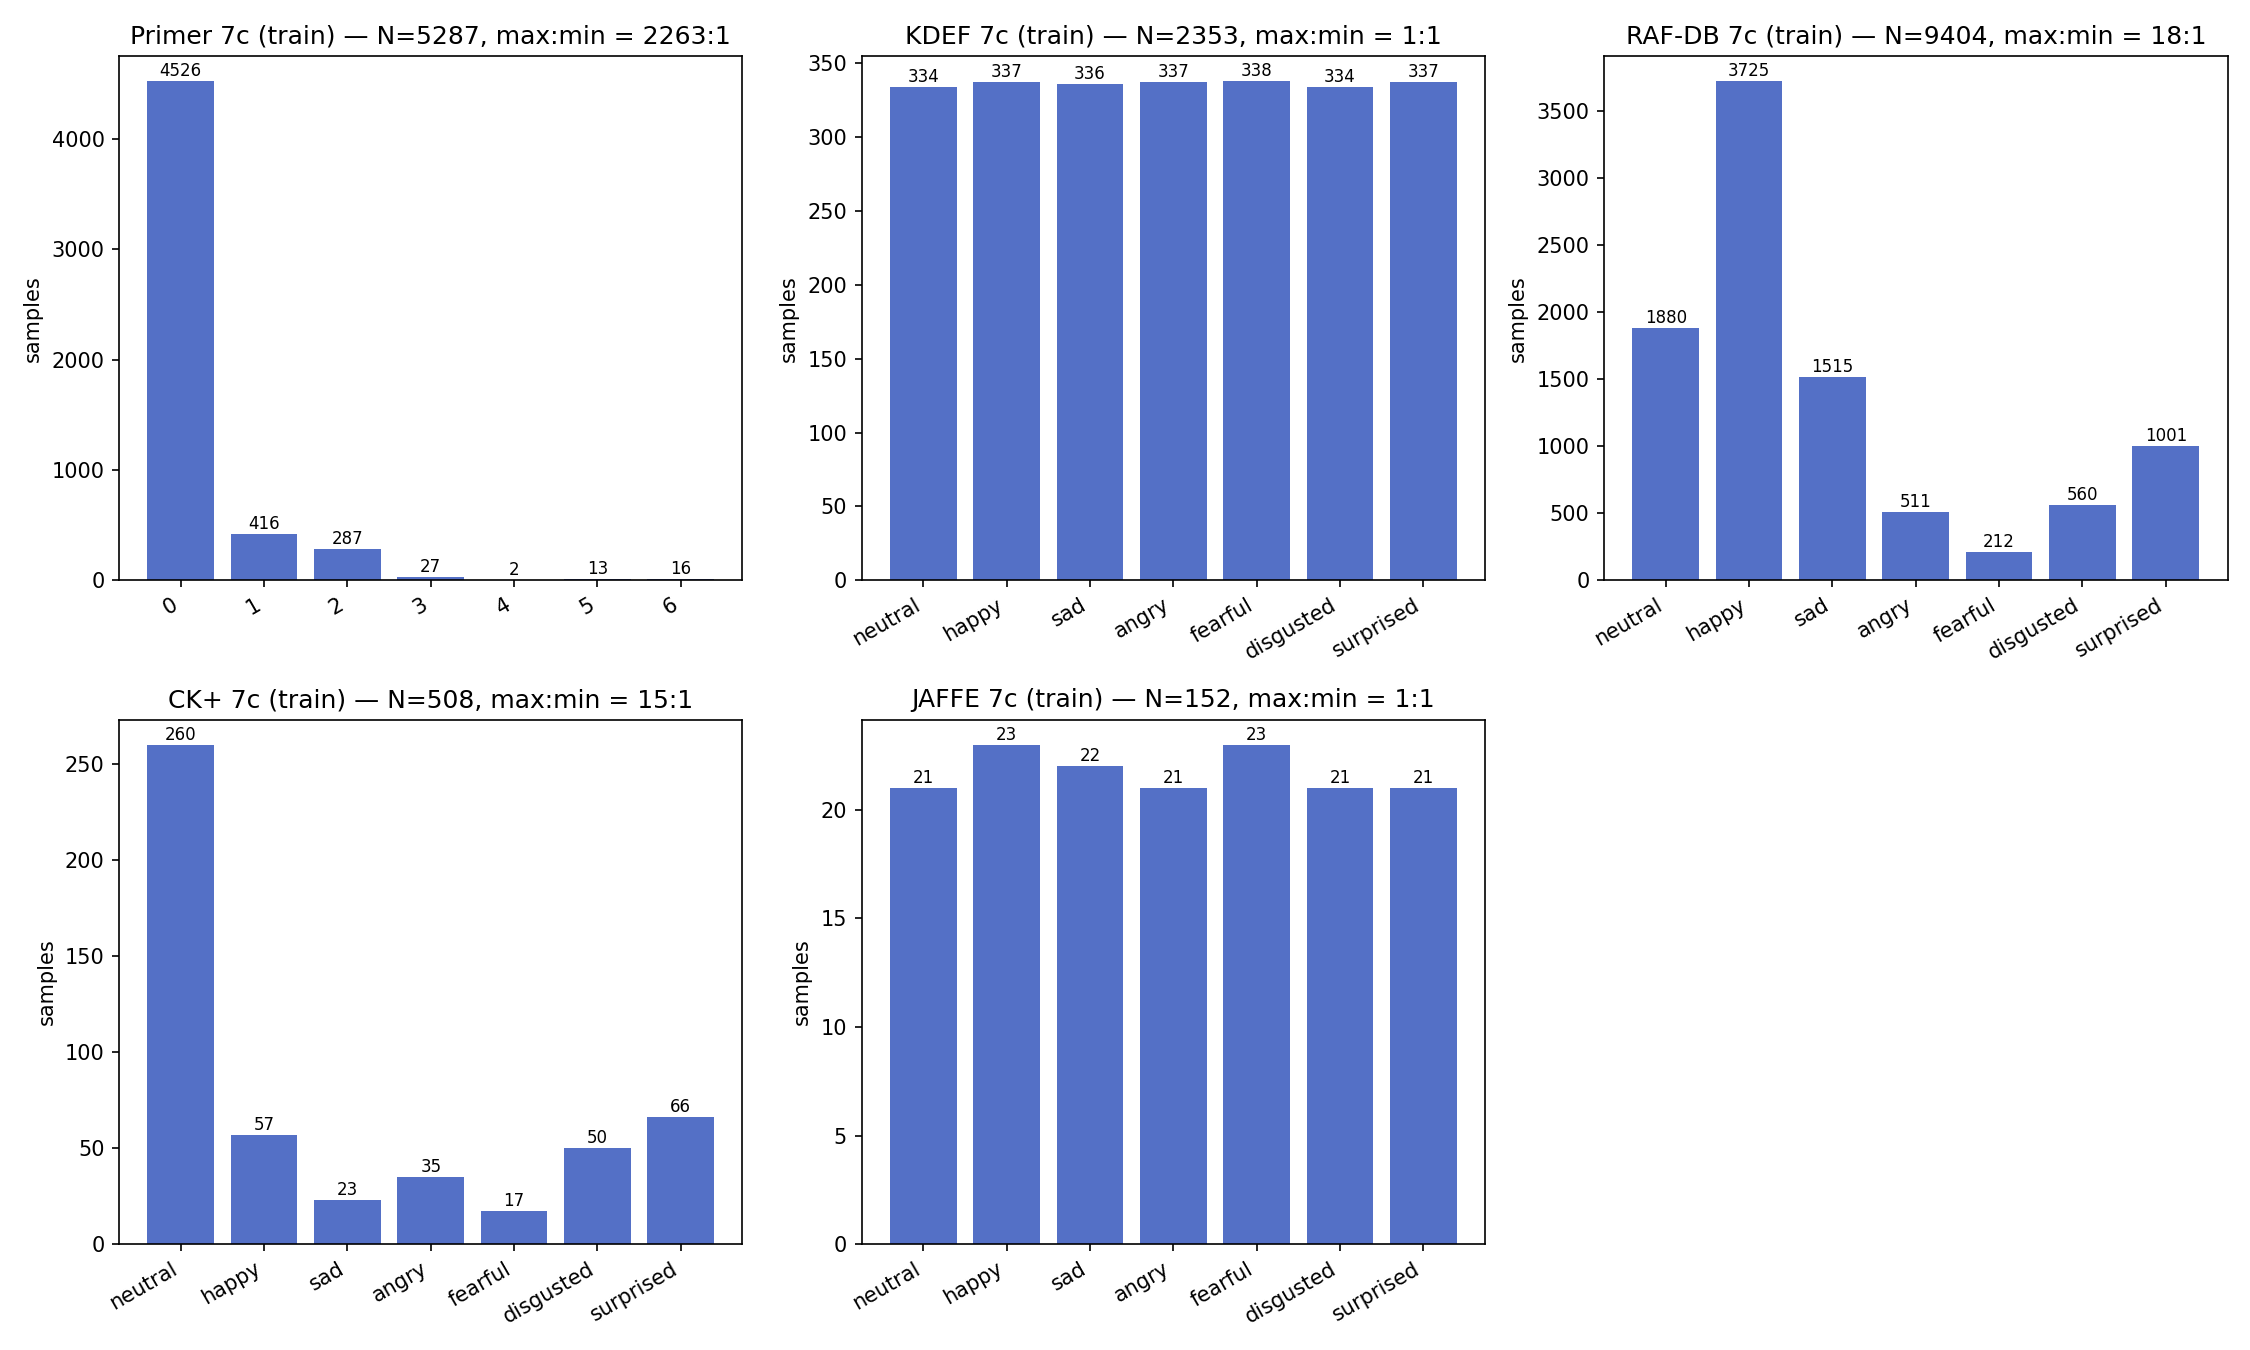

In [27]:
display(Image(filename=str(FIG_ROOT/'dataset'/'class_distribution.png')))

### 4.12 Cross-dataset: Primer vs setiap benchmark

Apakah ranking method konsisten antara Primer (in-the-wild) dan tiap benchmark? Comparison di scenario B1, source MediaPipe.


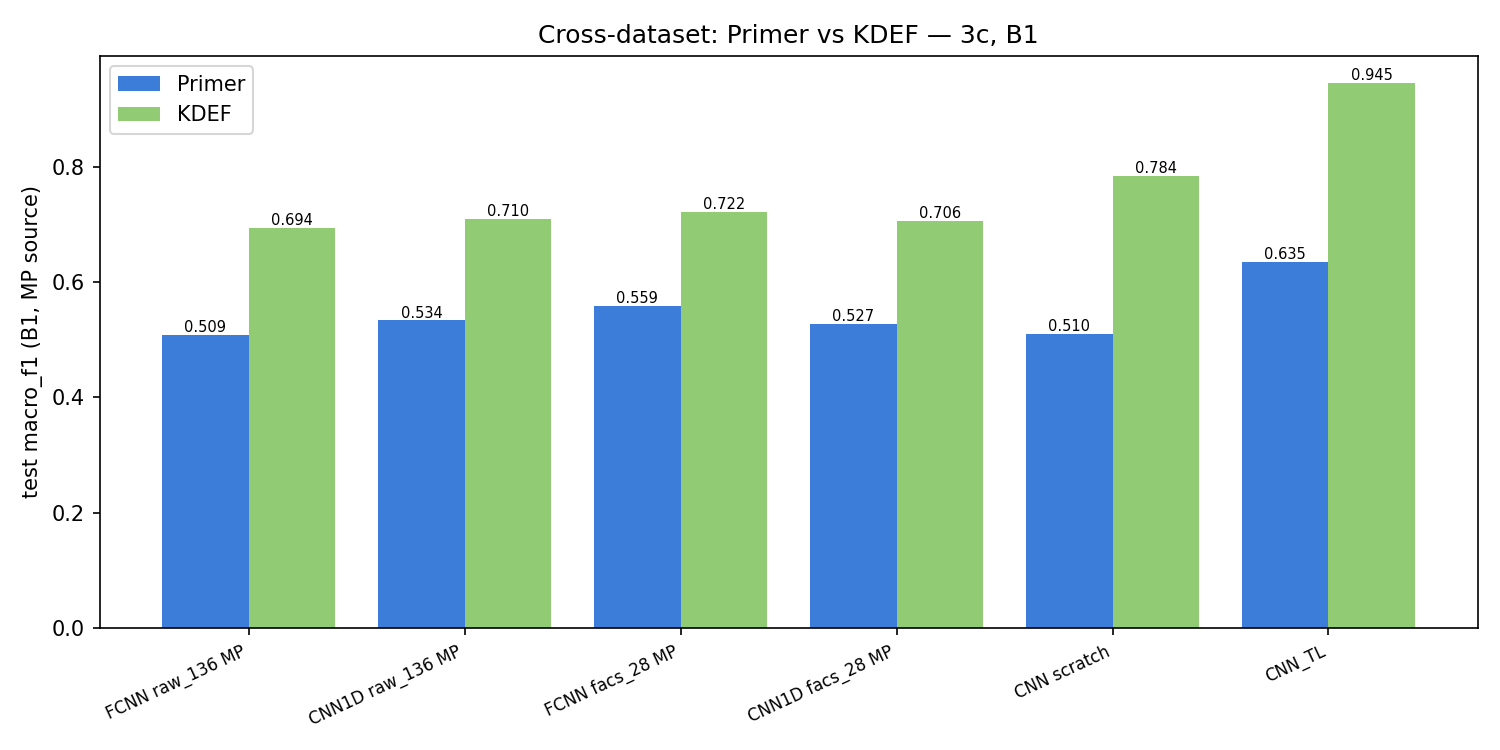

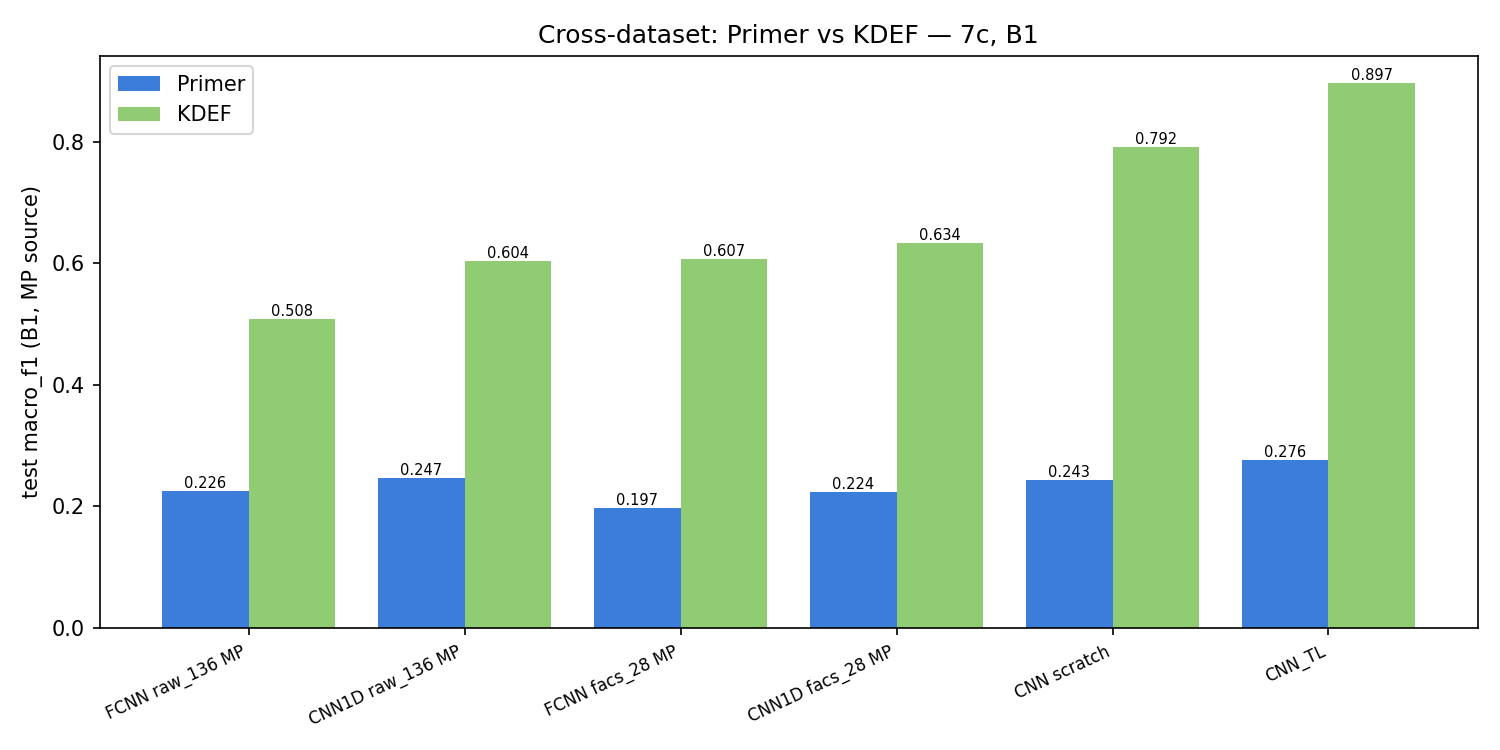

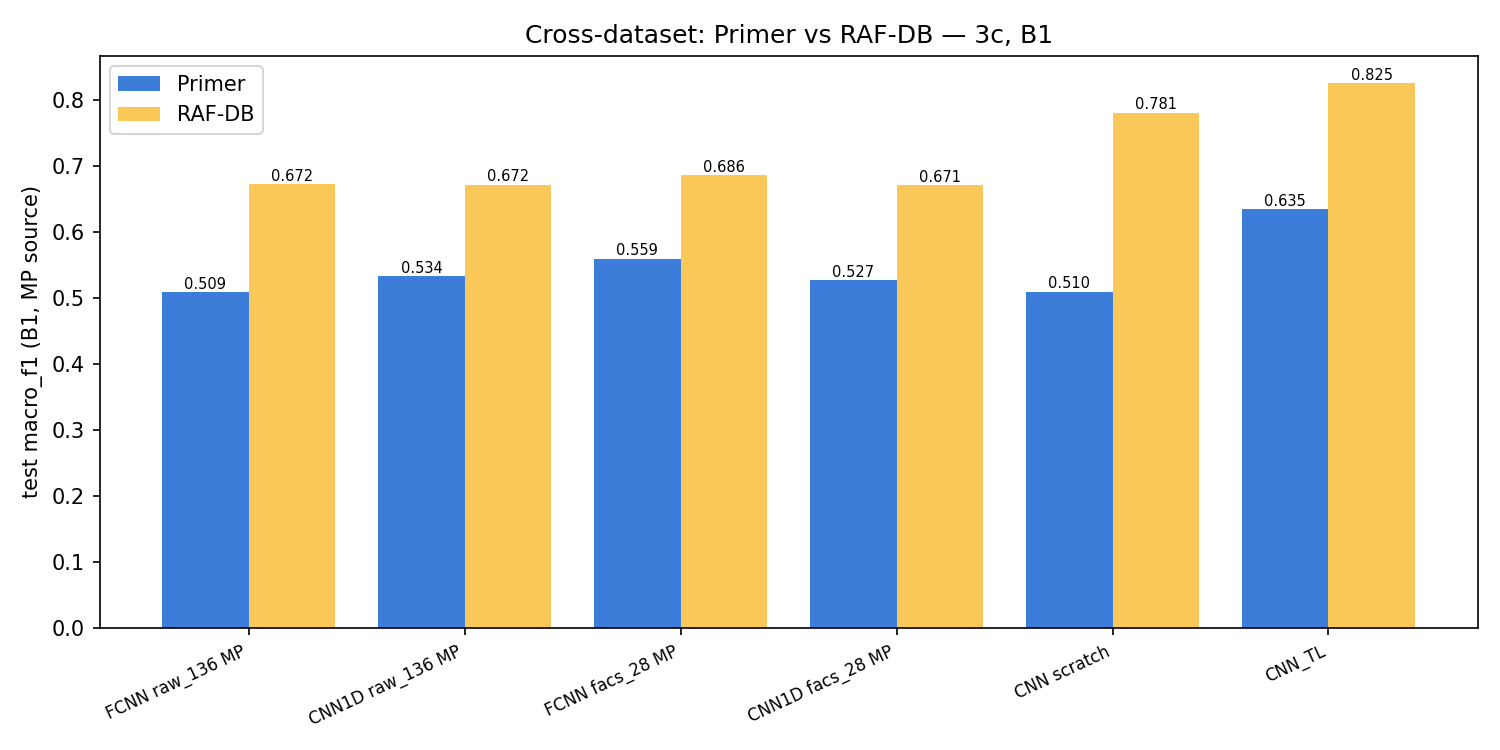

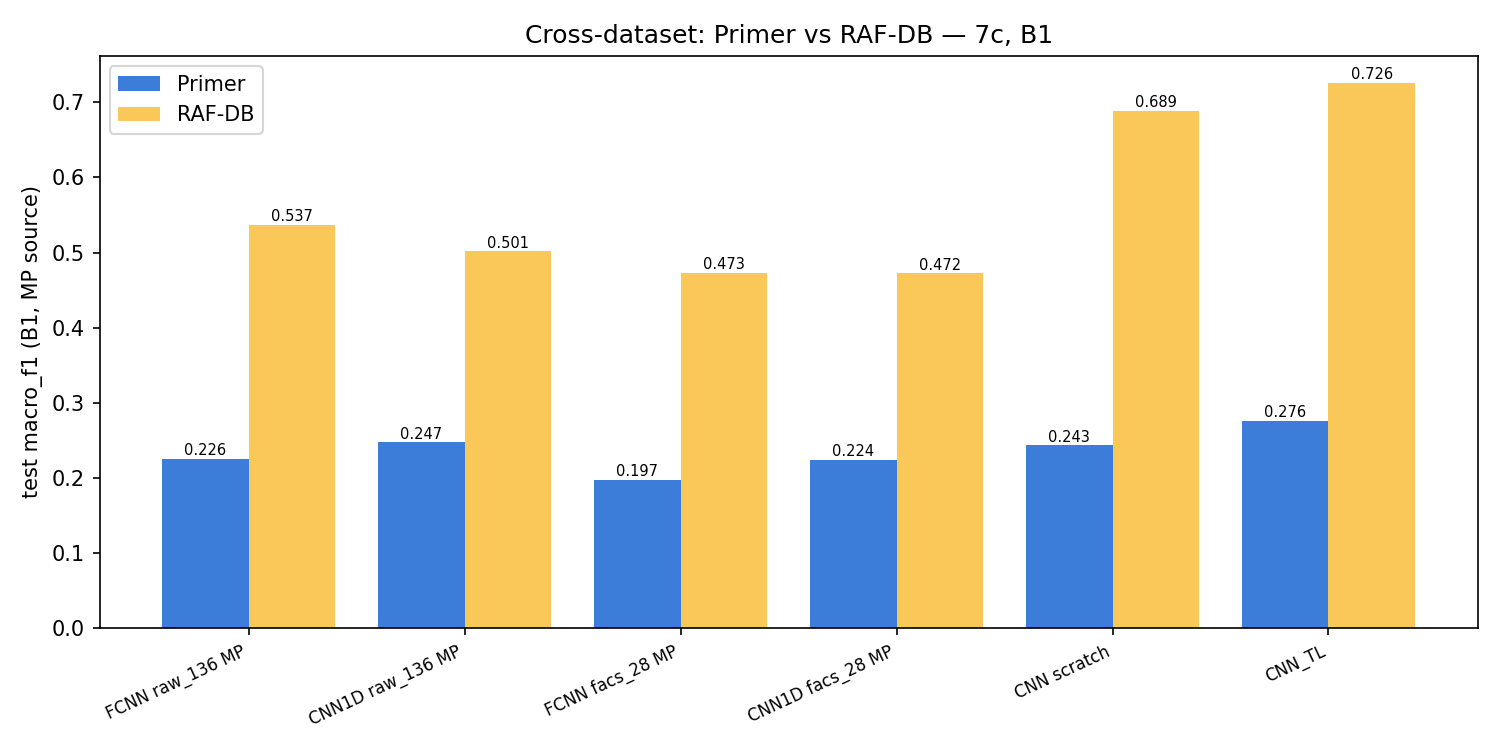

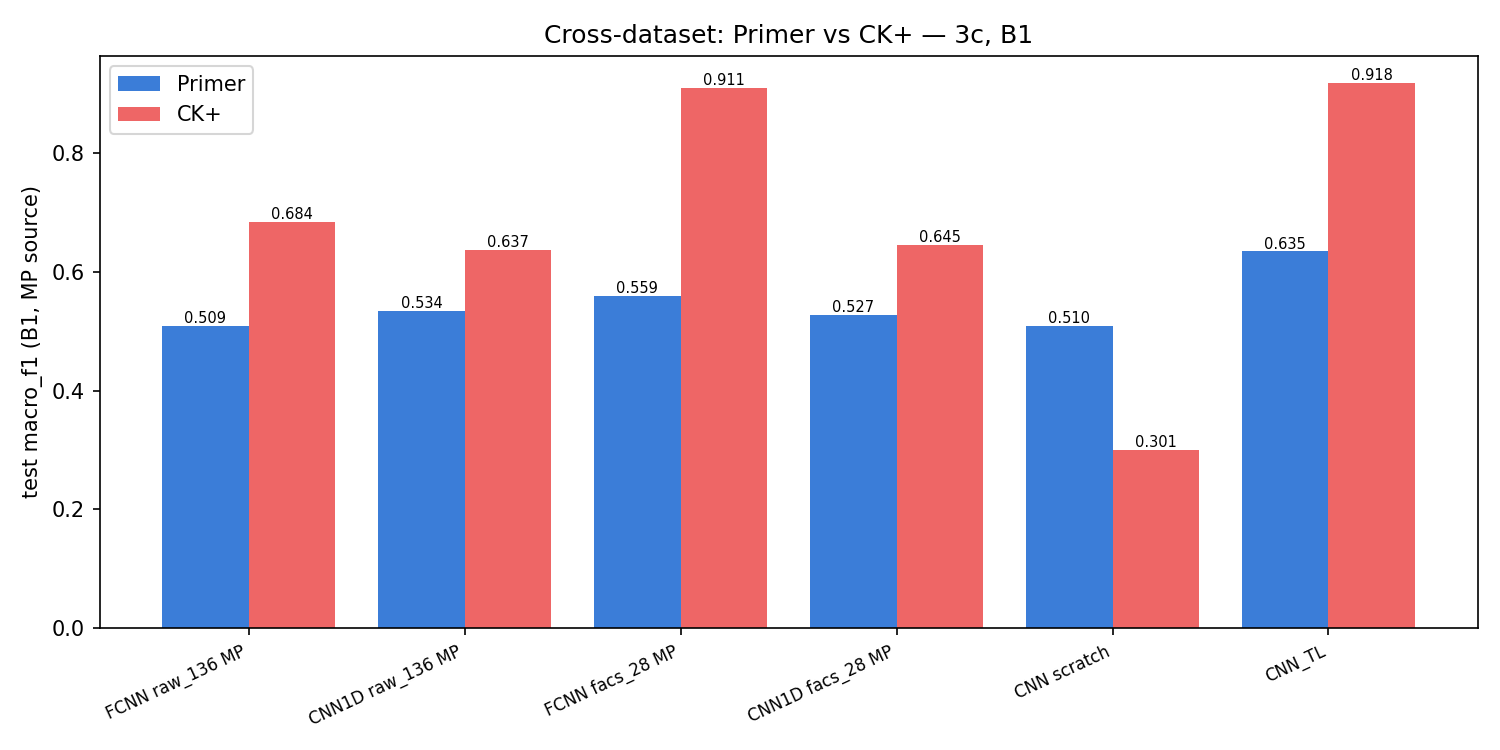

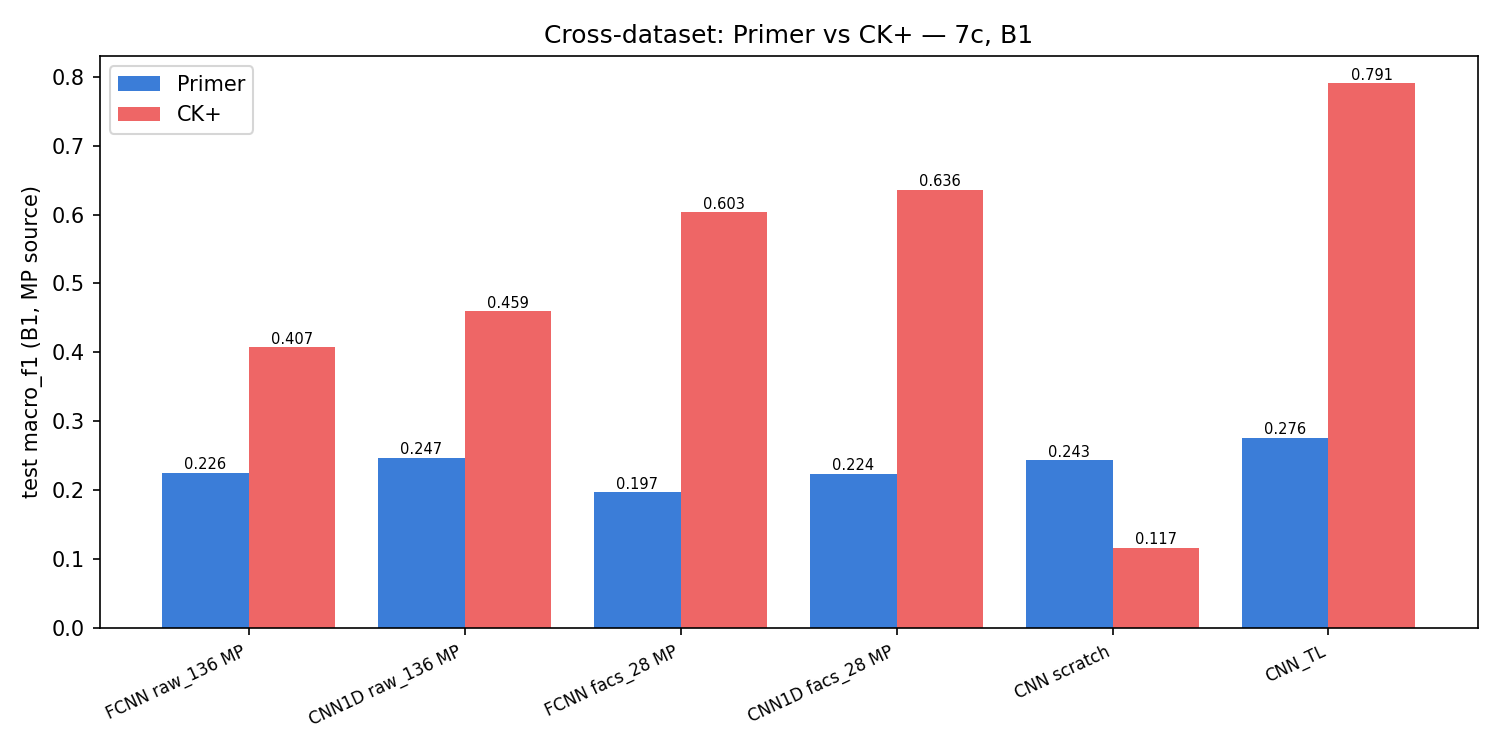

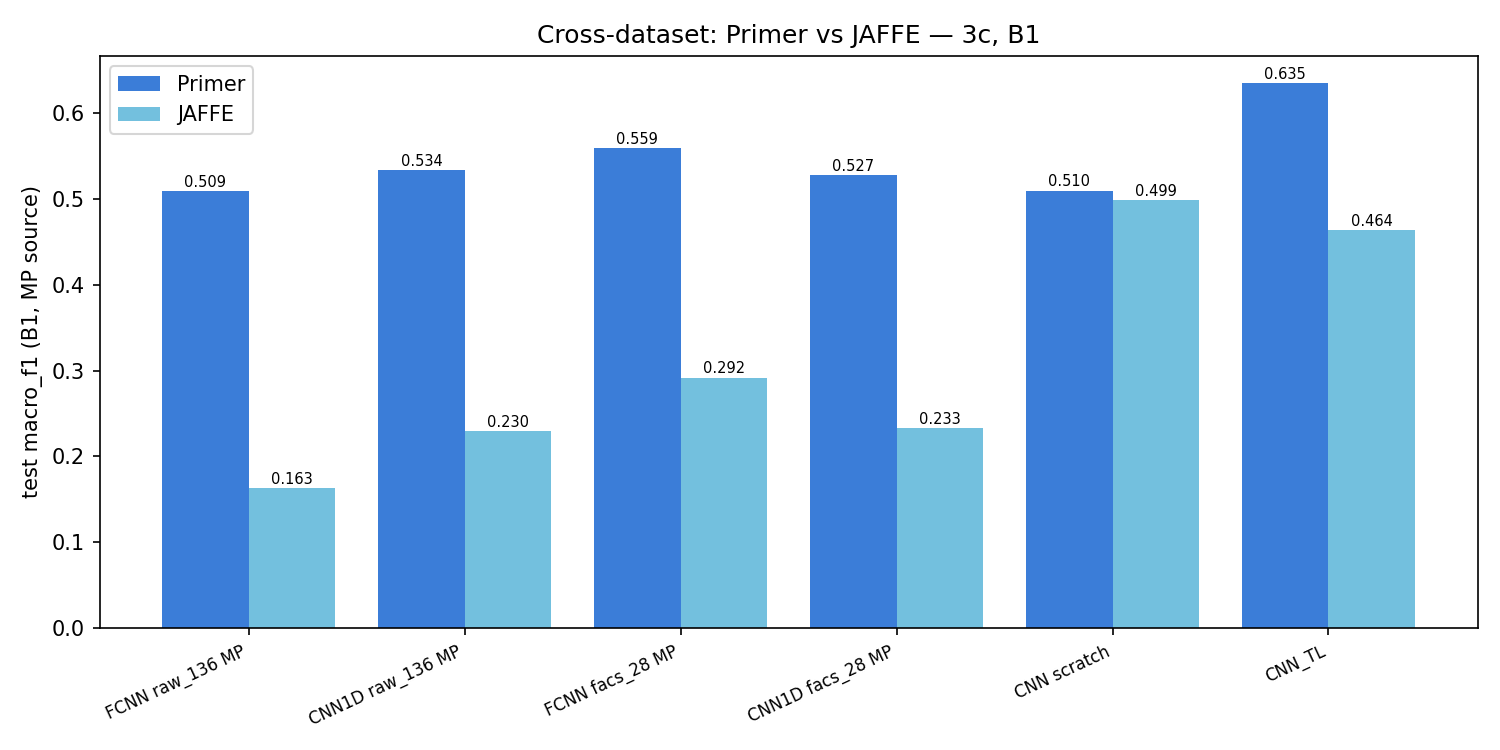

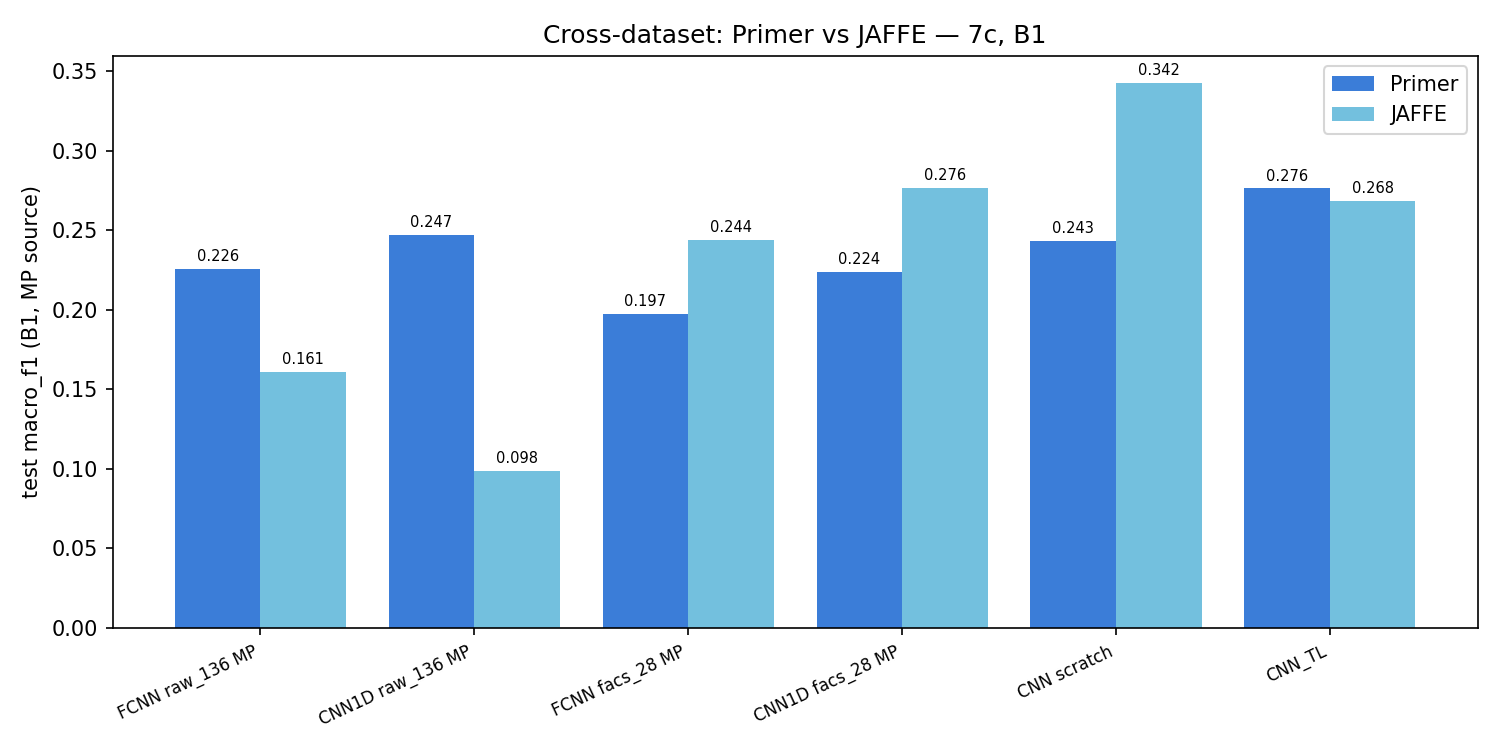

In [28]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_kdef_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_kdef_7c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_rafdb_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_rafdb_7c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_ckplus_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_ckplus_7c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_jaffe_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_jaffe_7c.png')))

### 4.13 Cross-dataset: Primer vs SEMUA benchmark (sekali tampil)

Ringkasan visual semua dataset side-by-side dalam satu chart per scheme.


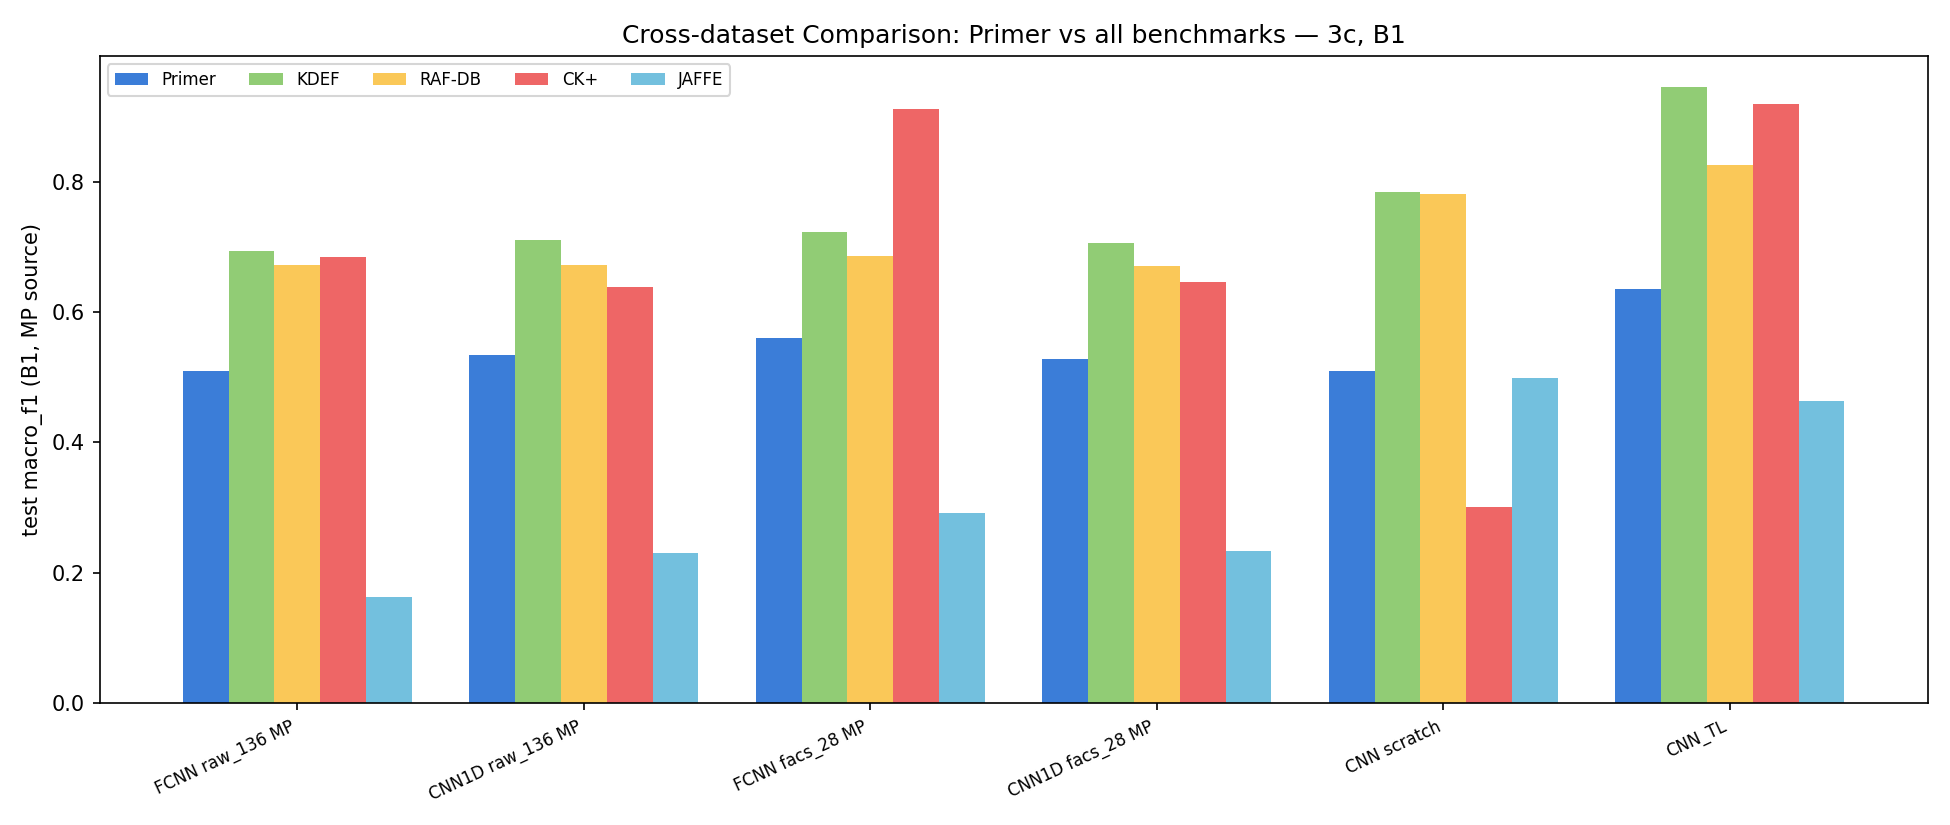

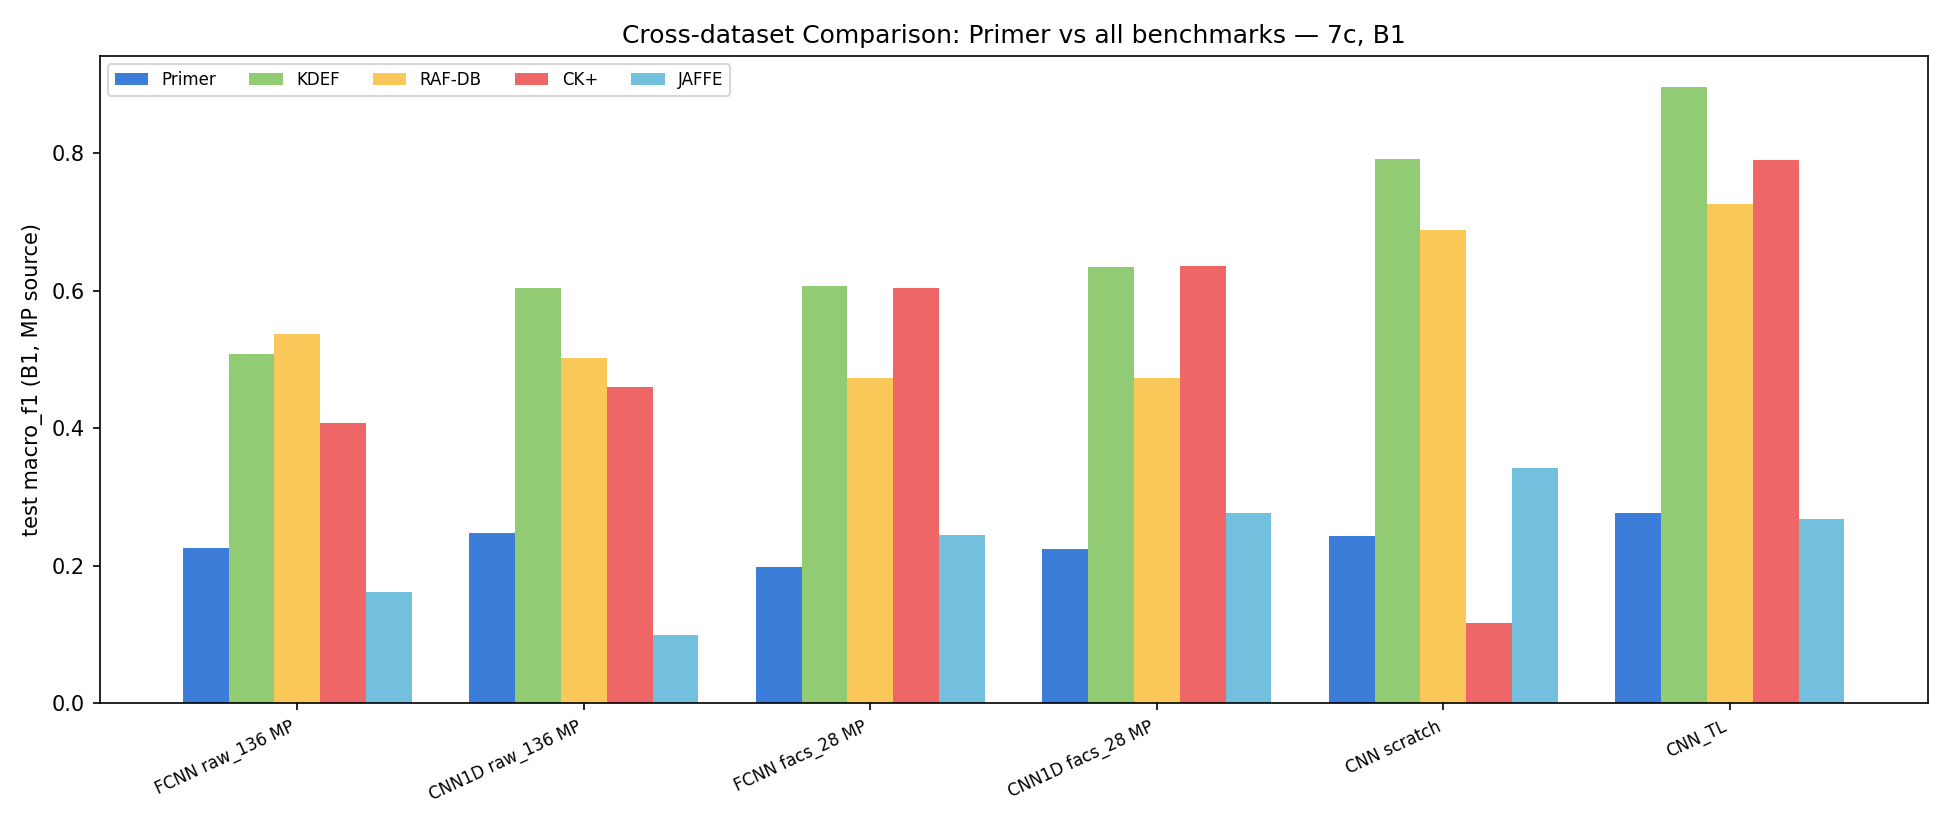

In [29]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_all_benchmarks_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_all_benchmarks_7c.png')))

### 4.14 Top-5 Leaderboard per Dataset (cross-dataset)

Top-5 model unimodal per dataset (Primer + 4 benchmark) berdasarkan macro_f1 di B1.


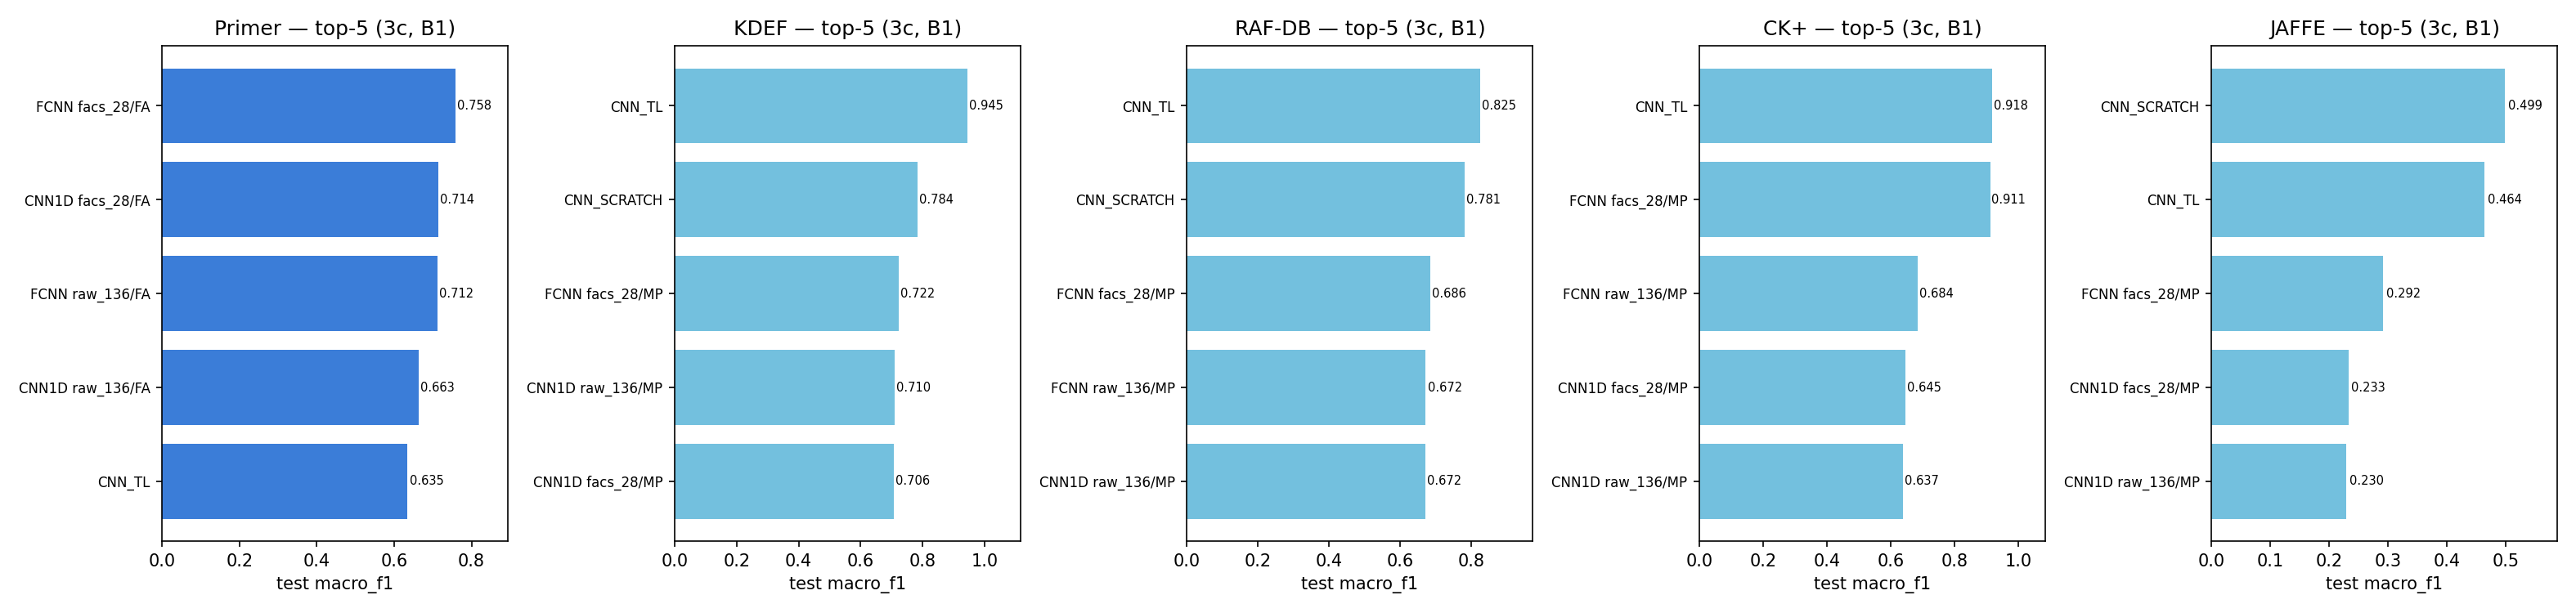

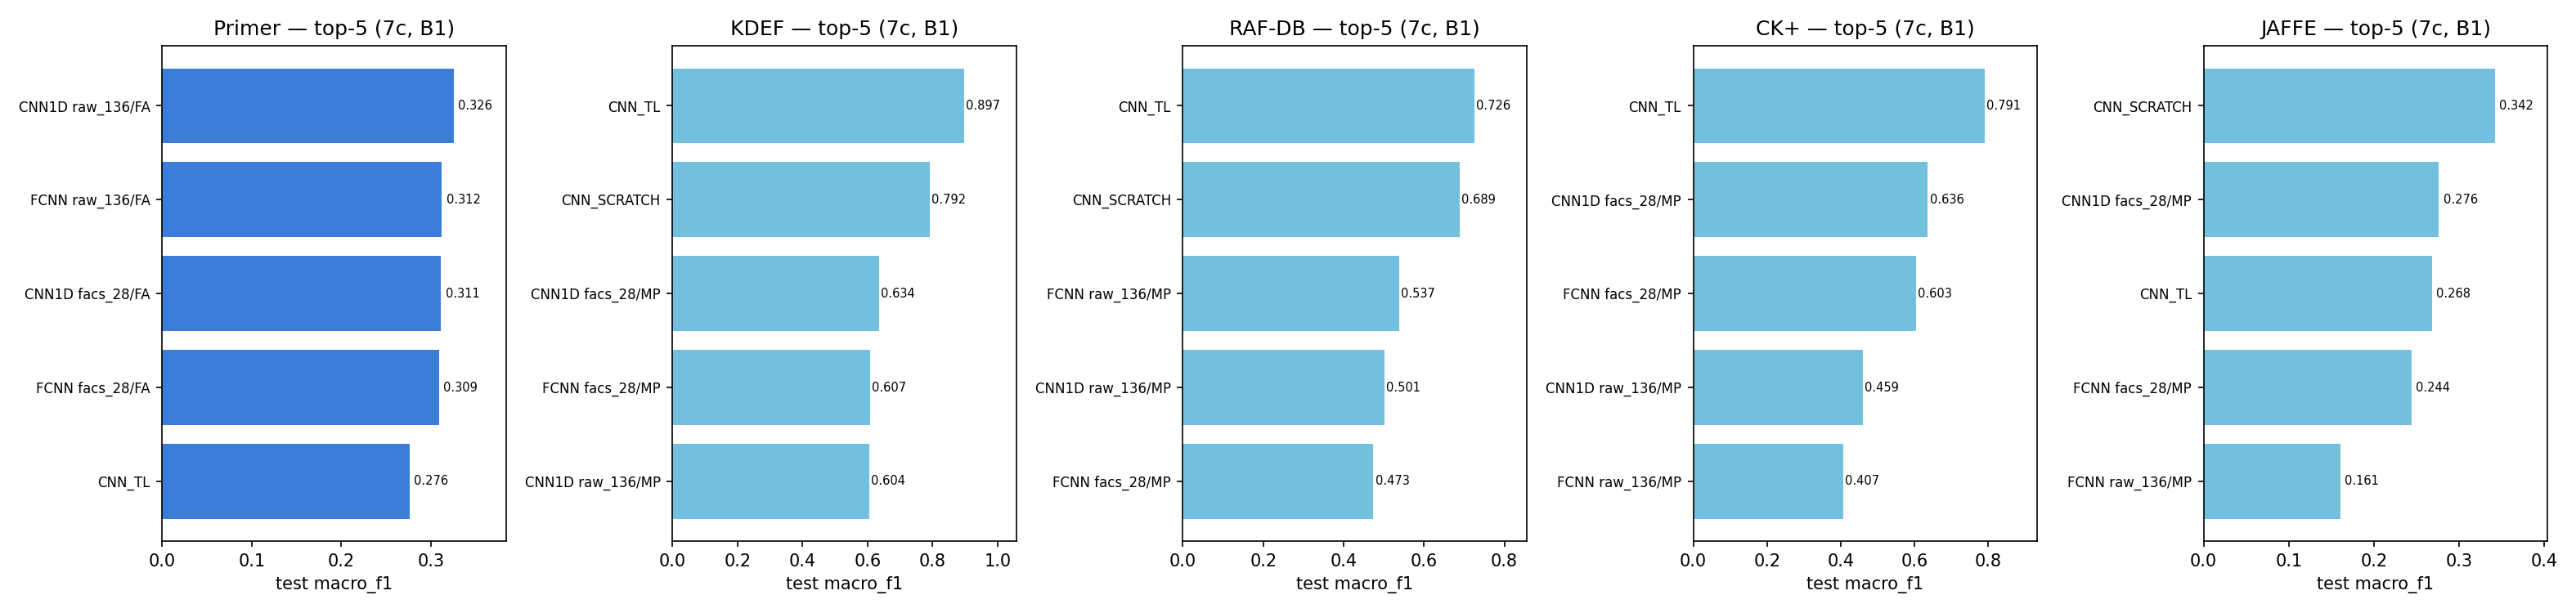

In [30]:
display(Image(filename=str(FIG_ROOT/'leaderboards'/'benchmark_top5_3c.png')))
display(Image(filename=str(FIG_ROOT/'leaderboards'/'benchmark_top5_7c.png')))

## 5. Insight Utama

### Best per scheme (Primer)
- **3c top:** FACS_28 × FA × FCNN × B1 = **0.7585**
- **7c top:** FACS+Blendshape (80) × FA × FCNN × B2 = **0.3331**

### Pola yang konsisten
- **face-api.js > MediaPipe** untuk landmark — semua top-10 (3c & 7c) pakai FA. Hipotesis: koordinat di frame asli (FA) mempertahankan info scale/pose, sedangkan MP (post face-crop 224×224) lebih kompresi info. Plus FA native 68-pt dlib semantik konsisten vs MP 478→68 mapping yang approximate.
- **CNN_TL ≫ CNN scratch** di image branch — pretrained ImageNet features esensial untuk dataset kecil (~5300 train sample).
- **Image-based < landmark-based** di kedua skema (best image rank ≥ 11 di leaderboard).
- **CNN1D > FCNN** untuk raw 2D coords (locality antar titik berurutan bermanfaat).
- **FCNN > CNN1D** untuk FACS distance (hand-crafted features tidak punya locality, MLP natural).
- **Scenario terbaik tergantung representasi:** B1 stabil untuk MP-source 7c, B3 menang di CNN1D + raw coords (synergy locality + aug), B2 menang di derived features 7c & image CNN_TL.

### Class imbalance bottleneck (7c)
- Train counts 7c: `[4526 neutral, 416 happy, 287 sad, 27 angry, 2 fearful, 13 disgusted, 16 surprised]`
- Rasio max:min = **2263:1** → kelas minoritas 1-3 sample di test set → metric noise tinggi
- 3c remap (positive = happy+surprised, neutral, negative = sisanya) jauh lebih wajar untuk eval.

### Cross-dataset (KDEF, B1 MP)
- CNN_TL ≫ method lain di KDEF balanced 7c (0.8966) — image branch lebih menonjol di dataset balanced.
- Landmark FCNN 7c di KDEF turun signifikan dibanding ekspektasi — perlu invest tuning per-method LR untuk landmark FCNN, atau pakai LR scheduler.

---

*Notebook di-regenerate dengan `python scripts/build_unimodal_notebook.py`. Figure di-regenerate dengan `python scripts/build_unimodal_figures.py`.*
